# Ch2: State EJ Frameworks and Federal Disaster Recognition

2000–2025 panel. SHELDUS robustness capped at data availability.

## Imports & Helper Functions

In [1]:
import sys
if 'google.colab' in sys.modules:
   !git clone https://github.com/nadiabahmad/disaster-declarations.git

### Installs
Necessary to run in Google Colab

In [2]:
import sys
if 'google.colab' in sys.modules:
    !pip install -r /content/disaster-declarations/requirements-colab.txt

### Imports

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings, os, io, re
import glob
import os
from pathlib import Path
from functools import partial
import ipywidgets as widgets
from IPython.display import display
import base64
import time
from IPython.display import HTML, display

warnings.filterwarnings('ignore')

### Configuration

In [4]:
is_sheldus_optional = False
is_coastal_counties_optional = False

In [5]:
# setup and uploads
# -- dissertation figure style (matches ch1) --

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Georgia', 'serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

# Wong colorblind-safe palette
# https://www.nature.com/articles/nmeth.1618
CB_BLUE    = '#0072B2'
CB_ORANGE  = '#E69F00'
CB_GREEN   = '#009E73'
CB_RED     = '#D55E00'
CB_PURPLE  = '#CC79A7'
CB_SKYBLUE = '#56B4E9'
CB_YELLOW  = '#F0E442'
CB_BLACK   = '#000000'


In [6]:
# configuration
DTYPE = ['DR']
YR0 = 2000
YR1 = 2025
SVI_CUT = 0.50
CLUST = 'stfips'
AT_MODE = 'strict'
print(f"Spec: {'+'.join(DTYPE)}, {YR0}-{YR1}, SVI>={SVI_CUT}, clust={CLUST}")

Spec: DR, 2000-2025, SVI>=0.5, clust=stfips


### Functions

In [7]:
upload_finished = False

def upload_file(change, destination_path):
    global upload_finished
    for uploaded_file in upload_btn.value:
        file_name = uploaded_file['name']
        file_content = uploaded_file['content']
        with open(destination_path, 'wb') as f:
            f.write(file_content)
        print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")
        upload_finished = True



def download(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return

    filename = os.path.basename(filepath)

    with open(filepath, "rb") as f:
        data = f.read()

    b64 = base64.b64encode(data).decode()

    html = f'''
    <a download="{filename}" id="auto-download" href="data:application/octet-stream;base64,{b64}" style="display:none;"></a>
    <script>
        document.getElementById("auto-download").click();
        document.getElementById("auto-download").remove();
    </script>
    '''
    display(HTML(html))

### File upload

#### Check missing files

In [8]:
# File setup

if 'google.colab' in sys.modules:
    data_dir = Path('/content/disaster-declarations/data/')
else:
    data_dir = Path('../data/')

sheldus_fn = "direct_loss_aggregated_output_28320.csv"
coastal_fn = "Coastal Counties.xlsx"
required_files = [
    "Article_2_-_State_EJ_Framework_Inventory_v4.xlsx",
     coastal_fn,
     sheldus_fn,
    "DisasterDeclarationsSummaries.csv",
    "National_Risk_Index_Counties.csv",
    "Ruralurbancontinuumcodes2023.csv",
    "SVI_2000_US_county.csv",
    "SVI_2010_US_county.csv",
    "SVI_2014_US_county.csv",
    "SVI_2016_US_county.csv",
    "SVI_2018_US_county.csv",
    "SVI_2020_US_county.csv",
    "SVI_2022_US_county.csv",
]

all_files = data_dir.glob("*")
missing_files = set(required_files) - set(os.path.basename(x) for x in all_files)
print("Missing files:", missing_files)

Missing files: set()


#### Upload missing files

In [9]:

if sheldus_fn in missing_files:
    print("+"*20)
    missing_files = missing_files - {sheldus_fn,}
    print(f"Default SHELDUS dataset ({sheldus_fn}) is missing")
    try:
        sheldus_fn = next(data_dir.glob("direct_loss_aggregated_output_*.csv"))
        # sheldus_fn = glob.glob(str(data_dir)+"/direct_loss_aggregated_output_*.csv")[0]
        print(f"Fallback to SHELDUS dataset: {sheldus_fn}.")
    except Exception:
        destination_path=data_dir / sheldus_fn
        if is_sheldus_optional:
            sheldus_fn = None
        elif 'google.colab' in sys.modules:
            from google.colab import files
            uploaded = files.upload()
            for file_name, file_content in uploaded.items():
                with open(destination_path, 'wb') as f:
                    f.write(file_content)
                print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")
    
        else:
            upload_finished = False
            upload_btn = widgets.FileUpload(accept='.csv', multiple=False)
            status_output = widgets.Output()
            upload_btn.observe(partial(upload_file, destination_path=destination_path), names='value')
            display(upload_btn, status_output)
            # Your required wait loop for local Jupyter
            print("Waiting for upload", end="")
            while not upload_finished:
                print('.', end=".")
                time.sleep(0.5)
            print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")
        
has_sheldus = sheldus_fn is not None
if coastal_fn in missing_files:
    print("+"*20)
    missing_files = missing_files - {coastal_fn,}
    print(f"Default Coastal Counties dataset ({coastal_fn}) is missing")
    try:
        coastal_fn = next(data_dir.glob("*coastal*.xlsx", case_sensitive=False))
        print(f"Fallback to Coastal Counties dataset: {coastal_fn}.")
    except Exception:
        destination_path=data_dir / coastal_fn
        if is_coastal_counties_optional:
            coastal_fn = None
        elif 'google.colab' in sys.modules:
            from google.colab import files
            uploaded = files.upload()
            for file_name, file_content in uploaded.items():
                with open(destination_path, 'wb') as f:
                    f.write(file_content)
                print(f"Success: {coastal_fn} uploaded and saved to {destination_path}")
        else:
            upload_finished = False
            upload_btn = widgets.FileUpload(accept='.xlsx', multiple=False)
            status_output = widgets.Output()
            upload_btn.observe(partial(upload_file, destination_path=destination_path), names='value')
            display(upload_btn, status_output)
            # Your required wait loop for local Jupyter
            print("Waiting for upload", end="")
            while not upload_finished:
                print('.', end=".")
                time.sleep(0.5)
            print(f"Success: {coastal_fn} uploaded and saved to {destination_path}")
            
has_coastal = coastal_fn is not None
if missing_files:
    print("+"*20)
    raise Exception((f"Missing REQUIRED files: {missing_files}"))

#### Final file check

In [10]:
all_files = data_dir.glob("*")
missing_files = set(required_files) - set(os.path.basename(x) for x in all_files)
if missing_files:
    raise Exception("Missing files:", missing_files)

### Data load

In [11]:
# HAZARD MAPPING DEFINITIONS (11 hazard types per outline Section I.D)
# Reused from Chapter 1 to keep typology consistent across the dissertation.

VALID_HAZARDS = [
    'Hurricane', 'Tornado', 'Inland Flooding', 'Wildfire',
    'Winter Weather', 'Earthquake', 'Drought', 'Landslide',
    'Coastal Flooding', 'Volcanic Activity', 'Tsunami'
]

FEMA_HAZARD_MAP = {
    'Hurricane': 'Hurricane',
    'Typhoon': 'Hurricane',
    'Coastal Storm': 'Coastal Flooding',
    'Tropical Storm': 'Hurricane',
    'Tornado': 'Tornado',
    'Flood': 'Inland Flooding',
    'Severe Storm': None,
    'Fire': 'Wildfire',
    'Wildfire': 'Wildfire',
    'Snow': 'Winter Weather',
    'Snowstorm': 'Winter Weather',
    'Ice Storm': 'Winter Weather',
    'Severe Ice Storm': 'Winter Weather',
    'Winter Storm': 'Winter Weather',
    'Freezing': 'Winter Weather',
    'Earthquake': 'Earthquake',
    'Drought': 'Drought',
    'Mud/Landslide': 'Landslide',
    'Tsunami': 'Tsunami',
    'Volcanic Eruption': 'Volcanic Activity',
}

def map_severe_storm_by_title(title):
    if not isinstance(title, str):
        return None
    title_upper = title.upper()
    if any(w in title_upper for w in ['TORNADO', 'TORNADOES']):
        return 'Tornado'
    elif any(w in title_upper for w in ['HURRICANE', 'TROPICAL']):
        return 'Hurricane'
    elif any(w in title_upper for w in ['FLOOD', 'FLOODING']):
        return 'Inland Flooding'
    elif any(w in title_upper for w in ['SNOW', 'ICE', 'WINTER', 'BLIZZARD', 'FREEZING']):
        return 'Winter Weather'
    elif any(w in title_upper for w in ['COASTAL', 'SURGE', 'TIDAL']):
        return 'Coastal Flooding'
    elif any(w in title_upper for w in ['MUDSLIDE', 'LANDSLIDE', 'MUD SLIDE']):
        return 'Landslide'
    elif any(w in title_upper for w in ['FIRE', 'WILDFIRE']):
        return 'Wildfire'
    elif 'EARTHQUAKE' in title_upper:
        return 'Earthquake'
    elif 'DROUGHT' in title_upper:
        return 'Drought'
    elif 'TSUNAMI' in title_upper:
        return 'Tsunami'
    elif 'VOLCAN' in title_upper:
        return 'Volcanic Activity'
    else:
        return None

SHELDUS_HAZARD_MAP = {
    'Hurricane/Tropical Storm': 'Hurricane',
    'Flooding': 'Inland Flooding',
    'Riverine Flooding': 'Inland Flooding',
    'Flash Flood': 'Inland Flooding',
    'Tornado': 'Tornado',
    'Wildfire': 'Wildfire',
    'Winter Weather': 'Winter Weather',
    'Winter Storm': 'Winter Weather',
    'Ice Storm': 'Winter Weather',
    'Snow': 'Winter Weather',
    'Blizzard': 'Winter Weather',
    'Freezing': 'Winter Weather',
    'Earthquake': 'Earthquake',
    'Drought': 'Drought',
    'Coastal': 'Coastal Flooding',
    'Coastal Flooding': 'Coastal Flooding',
    'Storm Surge': 'Coastal Flooding',
    'Tsunami': 'Tsunami',
    'Tsunami/Seiche': 'Tsunami',
    'Volcanic': 'Volcanic Activity',
    'Volcano': 'Volcanic Activity',
    'Landslide': 'Landslide',
    'Mudslide': 'Landslide',
}

NRI_HAZARD_PREFIX = {
    'Hurricane': 'HRCN',
    'Tornado': 'TRND',
    'Inland Flooding': 'IFLD',
    'Wildfire': 'WFIR',
    'Winter Weather': 'WNTW',
    'Earthquake': 'ERQK',
    'Drought': 'DRGT',
    'Landslide': 'LNDS',
    'Coastal Flooding': 'CFLD',
    'Volcanic Activity': 'VLCN',
    'Tsunami': 'TSUN',
}

print(f"Defined {len(VALID_HAZARDS)} hazard categories")


Defined 11 hazard categories


In [12]:
# load data

ej = pd.read_excel(data_dir / 'Article_2_-_State_EJ_Framework_Inventory_v4.xlsx',
                    sheet_name='State_EJ_Framework_Inventory')
ej['State_FIPS'] = ej['State_FIPS'].astype(int)

for c,l in [(1,'Tier 1 Strong'),(2,'Tier 2 Dev'),(3,'Tier 3 Policy'),(0,'None')]:
    print(f"  {l}: {(ej['Treatment_Code']==c).sum()}")

if AT_MODE == 'strict':
    at_fips = ej.loc[ej['Treatment_Year'].notna() &
                      (ej['Treatment_Year'] < YR0), 'State_FIPS'].tolist()
else:
    at_fips = ej.loc[ej['Treatment_Year'].notna() &
                      (ej['Treatment_Year'] < 2008), 'State_FIPS'].tolist()
at_names = [ej.loc[ej['State_FIPS']==f,'State'].iloc[0] for f in at_fips]
print(f"\nAlways-treated ({AT_MODE}): {at_names}")

dr_raw = pd.read_csv(data_dir / 'DisasterDeclarationsSummaries.csv', low_memory=False)
dr_raw['declarationDate'] = pd.to_datetime(dr_raw['declarationDate'])
dr_raw['year'] = dr_raw['declarationDate'].dt.year
dr_raw['FIPS'] = dr_raw['fipsStateCode']*1000 + dr_raw['fipsCountyCode']
dr = dr_raw[(dr_raw['fipsCountyCode']>0)&(dr_raw['year']>=YR0)&
            (dr_raw['year']<=YR1)&(dr_raw['declarationType'].isin(DTYPE))].copy()
dr_cy = dr.groupby(['FIPS','year']).agg(ndecl=('disasterNumber','nunique')).reset_index()
print(f"\n{len(dr_cy)} county-years with 1+ {'+'.join(DTYPE)}")

def _vintage(yr):
    if yr<=2004: return '2000'
    elif yr<=2011: return '2010'
    elif yr<=2014: return '2014'
    elif yr<=2016: return '2016'
    elif yr<=2018: return '2018'
    elif yr<=2020: return '2020'
    return '2022'

def _load_svi(v):
    fn = f'SVI_{v}_US_county.csv'
    fn = data_dir / fn
    if not os.path.exists(fn): return None
    raw = pd.read_csv(fn, low_memory=False)
    if v=='2000':
        raw = raw.rename(columns={'STCOFIPS':'FIPS','STATE_FIPS':'ST'})
        raw['RPL_THEMES'] = raw['USTP']
        raw['RPL_THEME1'] = raw.get('USG1TP', np.nan)
        raw['RPL_THEME3'] = raw.get('USG3TP', np.nan)
        raw['E_TOTPOP'] = raw['Totpop2000']
    elif v=='2010':
        raw['RPL_THEMES'] = raw['R_PL_THEMES']
        raw['RPL_THEME1'] = raw['R_PL_THEME1']
        raw['RPL_THEME3'] = raw['R_PL_THEME3']
        raw['ST'] = raw['STATE']
    keep = [c for c in ['FIPS','ST','RPL_THEMES','RPL_THEME1','RPL_THEME3','E_TOTPOP']
            if c in raw.columns]
    out = raw[keep].copy()
    out = out[out['RPL_THEMES']>=0]
    out['FIPS'] = out['FIPS'].astype(int); out['ST'] = out['ST'].astype(int)
    return out

svi_d = {}
for v in sorted(set(_vintage(y) for y in range(YR0,YR1+1))):
    svi_d[v] = _load_svi(v)
    if svi_d[v] is not None: print(f"  SVI {v}: {len(svi_d[v])}")

nri_raw = pd.read_csv(data_dir / 'National_Risk_Index_Counties.csv', low_memory=False)
nri_raw['FIPS'] = nri_raw['STCOFIPS'].astype(int)
nri = nri_raw[['FIPS','POPULATION','EAL_VALP','RISK_SCORE']].copy()
nri['nri_pc'] = nri['EAL_VALP'] / nri['POPULATION'].replace(0,np.nan)

rucc_raw = pd.read_csv(data_dir / 'Ruralurbancontinuumcodes2023.csv', encoding='cp1252')
rucc = rucc_raw[rucc_raw['Attribute']=='RUCC_2023'][['FIPS','Value']].copy()
rucc['RUCC'] = rucc['Value'].astype(int)
rucc['rural'] = (rucc['RUCC']>=4).astype(int)
rucc = rucc[['FIPS','RUCC','rural']]

if has_coastal:
    cst = pd.read_excel(data_dir / coastal_fn)
    fc = [c for c in cst.columns if 'fips' in c.lower()]
    if fc: cst['FIPS'] = cst[fc[0]].astype(int)
    else:
        for c in cst.columns:
            if pd.api.types.is_numeric_dtype(cst[c]): cst['FIPS']=cst[c].astype(int); break
    cst = cst[['FIPS']].drop_duplicates(); cst['coastal'] = 1

if has_sheldus:
    sh = pd.read_csv(data_dir / sheldus_fn)
    sh = sh.rename(columns={'County_FIPS':'FIPS'})
    SH_END = int(sh['Year'].max())
    sh = sh[(sh['Year']>=YR0)&(sh['Year']<=SH_END)]

    # Restrict to 11 Stafford-eligible hazard types using the
    # SHELDUS_HAZARD_MAP defined in the hazard mapping cell above
    # (consistent with Chapter 1's typology).
    _hz_col = next((c for c in ['Hazard','Hazards','HazardType','HazardName']
                    if c in sh.columns), None)
    if _hz_col is None:
        print(f"  WARNING: no Hazard column in SHELDUS file. Columns: {list(sh.columns)}")
        print(f"  Skipping Stafford-11 filter \u2014 chapter \u00a72.7.7 claim will not be reproduced.")
    else:
        # Case- and whitespace-tolerant lookup into SHELDUS_HAZARD_MAP
        _sh_lookup = {k.strip().lower(): v for k, v in SHELDUS_HAZARD_MAP.items()}
        def _to_stafford(name):
            if not isinstance(name, str): return None
            return _sh_lookup.get(name.strip().lower())
        sh['_cat'] = sh[_hz_col].map(_to_stafford)
        _kept = sh['_cat'].notna()
        _all_hz  = sorted(sh[_hz_col].dropna().unique())
        _drop_hz = sorted(sh.loc[~_kept, _hz_col].dropna().unique())
        print(f"\n  SHELDUS hazard column: '{_hz_col}'  ({len(_all_hz)} unique hazards)")
        print(f"  Records before Stafford-11 filter: {len(sh):,}")
        print(f"  Records after  Stafford-11 filter: {_kept.sum():,}  ({(~_kept).sum():,} dropped)")
        _cat_counts = sh.loc[_kept].groupby('_cat').size().sort_values(ascending=False)
        print("  Records per Stafford category:")
        for _c, _n in _cat_counts.items():
            print(f"    {_c}: {_n:,}")
        # Verify all 11 categories are represented (chapter \u00a72.7.7 claim)
        _missing_cats = [h for h in VALID_HAZARDS if h not in _cat_counts.index]
        if _missing_cats:
            print(f"  NOTE: {len(_missing_cats)}/11 categories absent from data: {_missing_cats}")
        if _drop_hz:
            print("  Hazards excluded (not in SHELDUS_HAZARD_MAP, not Stafford-eligible):")
            for _h in _drop_hz: print(f"    {_h}")
        sh = sh.loc[_kept].drop(columns=['_cat'])

    shcy = (sh.groupby(['FIPS','Year'])
            .agg(sh_propdmg=('PropertyDmg(ADJ 2024)','sum'),
                 sh_cropdmg=('CropDmg(ADJ 2024)','sum'),
                 sh_dead=('Fatalities','sum'),sh_hurt=('Injuries','sum'),
                 sh_nevents=('Records','sum'))
            .reset_index().rename(columns={'Year':'year'}))
    shcy['sh_totdmg'] = shcy['sh_propdmg']+shcy['sh_cropdmg']
    shcy['sh_casualties'] = shcy['sh_dead']+shcy['sh_hurt']
    print(f"\nSHELDUS: through {SH_END}")
else:
    SH_END = None
print("\nDone loading")

  Tier 1 Strong: 7
  Tier 2 Dev: 8
  Tier 3 Policy: 7
  None: 28

Always-treated (strict): ['California', 'Montana']

24118 county-years with 1+ DR
  SVI 2000: 3141
  SVI 2010: 3142
  SVI 2014: 3142
  SVI 2016: 3142
  SVI 2018: 3141
  SVI 2020: 3143
  SVI 2022: 3144

  SHELDUS hazard column: 'Hazard'  (11 unique hazards)
  Records before Stafford-11 filter: 54,964
  Records after  Stafford-11 filter: 54,964  (0 dropped)
  Records per Stafford category:
    Inland Flooding: 22,445
    Tornado: 12,115
    Winter Weather: 10,621
    Hurricane: 3,063
    Wildfire: 2,142
    Drought: 2,002
    Coastal Flooding: 1,345
    Landslide: 1,047
    Earthquake: 112
    Tsunami: 55
    Volcanic Activity: 17

SHELDUS: through 2024

Done loading


In [13]:
# build panel
# CT FIX: Connecticut switched from 8 historical counties to 9 Planning Regions
# in SVI 2022, but FEMA still uses historical county FIPS (9001-9015).
# Override CT in both the master frame and time-varying SVI to use SVI 2020
# (last vintage with historical CT counties).

# === MASTER: use SVI 2022 for all states except CT, which uses SVI 2020 ===
master_other = svi_d['2022'][svi_d['2022']['ST'] != 9].copy()
master_ct    = svi_d['2020'][svi_d['2020']['ST'] == 9].copy()
master = pd.concat([master_other, master_ct], ignore_index=True)
master = master[master['ST']!=11]
cnty = sorted(master['FIPS'].unique())
years = list(range(YR0,YR1+1))
print(f"{len(cnty)} counties x {len(years)} years = {len(cnty)*len(years):,}")
print(f"  CT counties in master: {(master['ST']==9).sum()} (should be 8 historical, not 9 PRs)")

df = pd.DataFrame([(c,y) for c in cnty for y in years], columns=['FIPS','year'])
df = df.merge(dr_cy, on=['FIPS','year'], how='left')
df['ndecl'] = df['ndecl'].fillna(0)
df['anydecl'] = (df['ndecl']>0).astype(int)

# === TIME-VARYING SVI: same CT override for any vintage that has PR FIPS ===
_fr = []
for yr in years:
    v = _vintage(yr)
    s = svi_d.get(v)
    if s is None:
        for fb in ['2022','2020','2018','2016','2014','2010','2000']:
            if svi_d.get(fb) is not None: s=svi_d[fb]; break

    # CT FIX: SVI 2022 has Planning Region FIPS that don't match historical CT data.
    # For any year that pulls SVI 2022, swap CT rows for SVI 2020 CT rows.
    if v == '2022' and svi_d.get('2020') is not None:
        s_non_ct = s[s['ST'] != 9]
        s_ct_hist = svi_d['2020'][svi_d['2020']['ST'] == 9]
        s = pd.concat([s_non_ct, s_ct_hist], ignore_index=True)

    t = s.copy(); t['year']=yr; _fr.append(t)
svitv = pd.concat(_fr, ignore_index=True)
ren = {c:f'sv_{c}' for c in svitv.columns if c not in ['FIPS','year']}
svitv = svitv.rename(columns=ren)
df = df.merge(svitv, on=['FIPS','year'], how='left')

# Static SVI from master (CT uses SVI 2020 values per the override above)
stc = master[['FIPS','RPL_THEMES','E_TOTPOP']].rename(
    columns={'RPL_THEMES':'svi22','E_TOTPOP':'pop22'})
if 'RPL_THEME1' in master.columns:
    stc = master[['FIPS','RPL_THEMES','RPL_THEME1','E_TOTPOP']].rename(
        columns={'RPL_THEMES':'svi22','RPL_THEME1':'svi22_t1','E_TOTPOP':'pop22'})
if 'RPL_THEME3' in master.columns:
    stc['svi22_t3'] = master['RPL_THEME3']
df = df.merge(stc, on='FIPS', how='left')
df['stfips'] = df['FIPS']//1000

# CT VERIFICATION
ct_check = df[df['stfips']==9].drop_duplicates('FIPS')
print(f"\nCT VERIFICATION:")
print(f"  CT FIPS in panel: {sorted(ct_check['FIPS'].unique())}")
print(f"  CT counties with non-zero declarations (panel total): "
      f"{(df[df['stfips']==9]['ndecl']>0).sum()} county-years")
print(f"  CT mean ndecl across all years: {df[df['stfips']==9]['ndecl'].mean():.4f}")

df = df.merge(ej[['State_FIPS','Treatment_Code','Treatment_Year','Treatment_Label',
                   'Statutory_Framework','EJ_Mapping_Tool','Cumulative_Impacts']],
              left_on='stfips', right_on='State_FIPS', how='left')

df['post'] = np.where(df['Treatment_Year'].notna()&(df['year']>=df['Treatment_Year']),1,0)
df['rel_t'] = np.where(df['Treatment_Year'].notna(), df['year']-df['Treatment_Year'], np.nan)
df['hsvi'] = (df['svi22']>=SVI_CUT).astype(int)
df['sviq'] = pd.qcut(df['svi22'], 4, labels=['Q1','Q2','Q3','Q4'])
df['isq4'] = (df['sviq']=='Q4').astype(int)
df['t1']=(df['Treatment_Code']==1).astype(int)
df['t2']=(df['Treatment_Code']==2).astype(int)
df['t3']=(df['Treatment_Code']==3).astype(int)
df['anyej']=(df['Treatment_Code']>0).astype(int)
df['post_hsvi'] = df['post']*df['hsvi']
df['post_q4'] = df['post']*df['isq4']
for i in [1,2,3]:
    df[f'post_t{i}'] = df['post']*df[f't{i}']
    df[f't{i}_hsvi'] = df[f't{i}']*df['hsvi']
    df[f'post_t{i}_hsvi'] = df['post']*df[f't{i}']*df['hsvi']

if 'svi22_t1' in df.columns:
    df['hsvi_econ'] = (df['svi22_t1']>=0.5).astype(int)
    df['post_hsvi_econ'] = df['post']*df['hsvi_econ']
if 'svi22_t3' in df.columns:
    df['hsvi_min'] = (df['svi22_t3']>=0.5).astype(int)
    df['post_hsvi_min'] = df['post']*df['hsvi_min']
df['dose'] = df['rel_t'].clip(lower=0).fillna(0)
df['dose_hsvi'] = df['dose']*df['hsvi']

df = df.merge(nri[['FIPS','nri_pc']], on='FIPS', how='left')
df = df.merge(rucc[['FIPS','RUCC','rural']], on='FIPS', how='left')
if has_coastal:
    df = df.merge(cst, on='FIPS', how='left')
    df['coastal'] = df['coastal'].fillna(0).astype(int)
if has_sheldus:
    df = df.merge(shcy, on=['FIPS','year'], how='left')
    for c in ['sh_propdmg','sh_cropdmg','sh_totdmg','sh_casualties','sh_nevents','sh_dead','sh_hurt']:
        if c in df.columns: df[c]=df[c].fillna(0)
    df['lnsh_dmg'] = np.log(df['sh_totdmg']+1)
    df['lnsh_cas'] = np.log(df['sh_casualties']+1)
df['lnpop'] = np.log(df['pop22'].replace(0,np.nan))
df['is_at'] = df['stfips'].isin(at_fips).astype(int)
df['is_sw'] = ((df['anyej']==1)&(df['is_at']==0)).astype(int)
df['is_nt'] = (df['anyej']==0).astype(int)

def _admin(yr):
    if yr<=2000: return 'Clinton'
    elif yr<=2008: return 'Bush'
    elif yr<=2016: return 'Obama'
    elif yr<=2020: return 'Trump1'
    elif yr<=2024: return 'Biden'
    return 'Trump2'
df['admin'] = df['year'].apply(_admin)

did = df[df['is_at']==0].copy()
at_mod = ej.loc[ej['Treatment_Year'].notna()&(ej['Treatment_Year']<2008),'State_FIPS'].tolist()
did_mod = df[~df['stfips'].isin(at_mod)].copy()

nsw = did.loc[did['is_sw']==1,'stfips'].nunique()
nnt = did.loc[did['is_nt']==1,'stfips'].nunique()
print(f"\nDiD: {len(did):,}, {nsw} switchers, {nnt} never-treated, dropped {at_names}")

sw = ej[ej['State_FIPS'].isin(did.loc[did['is_sw']==1,'stfips'].unique())].sort_values('Treatment_Year')
for _,r in sw.iterrows():
    pre=int(r['Treatment_Year'])-YR0; post=YR1-int(r['Treatment_Year'])+1
    print(f"  {r['State']:20s} {int(r['Treatment_Year'])}  Tier {int(r['Treatment_Code'])}  ({pre}pre/{post}post)")

3142 counties x 26 years = 81,692
  CT counties in master: 8 (should be 8 historical, not 9 PRs)

CT VERIFICATION:
  CT FIPS in panel: [np.int64(9001), np.int64(9003), np.int64(9005), np.int64(9007), np.int64(9009), np.int64(9011), np.int64(9013), np.int64(9015)]
  CT counties with non-zero declarations (panel total): 67 county-years
  CT mean ndecl across all years: 0.4087

DiD: 78,728, 20 switchers, 28 never-treated, dropped ['California', 'Montana']
  Oregon               2007  Tier 2  (7pre/19post)
  Connecticut          2008  Tier 1  (8pre/18post)
  Illinois             2011  Tier 2  (11pre/15post)
  New York             2019  Tier 1  (19pre/7post)
  Washington           2019  Tier 1  (19pre/7post)
  New Jersey           2020  Tier 1  (20pre/6post)
  Virginia             2020  Tier 2  (20pre/6post)
  Maryland             2021  Tier 2  (21pre/5post)
  Massachusetts        2021  Tier 2  (21pre/5post)
  New Mexico           2021  Tier 2  (21pre/5post)
  Maine                2021  Tie

In [14]:
# helper functions

def ols(data, yvar, xvars, ctrls=None, cl='stfips', sfe=True, yfe=True):
    need = [yvar]+xvars+[cl]
    if ctrls: need+=ctrls
    d = data.dropna(subset=list(set(need))).copy()
    y = d[yvar].values
    chunks = [d[xvars].astype(float)]
    if ctrls: chunks.append(d[ctrls].astype(float))
    if sfe: chunks.append(pd.get_dummies(d['stfips'],prefix='st',drop_first=True).astype(float))
    if yfe: chunks.append(pd.get_dummies(d['year'],prefix='yr',drop_first=True).astype(float))
    X = sm.add_constant(pd.concat(chunks, axis=1))
    fit = sm.OLS(y,X).fit(cov_type='cluster', cov_kwds={'groups':d[cl].values})
    res = {'N':int(fit.nobs),'r2':fit.rsquared,'ymean':np.mean(y),'ncl':d[cl].nunique()}
    for v in xvars:
        if v in fit.params.index:
            pv=fit.pvalues[v]
            res[v]={'b':fit.params[v],'se':fit.bse[v],'p':pv,
                    'sig':'***' if pv<.01 else '**' if pv<.05 else '*' if pv<.1 else '',
                    'lo':fit.conf_int().loc[v,0],'hi':fit.conf_int().loc[v,1]}
    return res

def poisson_mod(data, yvar, xvars, ctrls=None, cl='stfips'):
    need = [yvar]+xvars+[cl]
    if ctrls: need+=ctrls
    d = data.dropna(subset=list(set(need))).copy()
    y = d[yvar].values
    chunks = [d[xvars].astype(float)]
    if ctrls: chunks.append(d[ctrls].astype(float))
    chunks.append(pd.get_dummies(d['stfips'],prefix='st',drop_first=True).astype(float))
    chunks.append(pd.get_dummies(d['year'],prefix='yr',drop_first=True).astype(float))
    X = sm.add_constant(pd.concat(chunks, axis=1))
    try:
        fit = sm.GLM(y, X, family=sm.families.Poisson()).fit(
            cov_type='cluster', cov_kwds={'groups':d[cl].values}, maxiter=200)
        res = {'N':int(fit.nobs),'ymean':np.mean(y),'ncl':d[cl].nunique(),'aic':fit.aic}
        for v in xvars:
            if v in fit.params.index:
                pv=fit.pvalues[v]
                res[v]={'b':fit.params[v],'se':fit.bse[v],'p':pv,
                        'sig':'***' if pv<.01 else '**' if pv<.05 else '*' if pv<.1 else '',
                        'lo':fit.conf_int().loc[v,0],'hi':fit.conf_int().loc[v,1]}
        return res
    except Exception as ex:
        print(f"  Poisson failed: {ex}"); return None

def pcoef(res, v, tag=None):
    r=res.get(v) if res else None
    if not r: print(f"  {tag or v}: --"); return
    print(f"  {tag or v}: {r['b']:.4f}{r['sig']}  SE={r['se']:.4f}  p={r['p']:.4f}  [{r['lo']:.4f},{r['hi']:.4f}]")

def rtable(mods, mnames, vlist):
    rows=[]
    for v in vlist:
        br=[v]; sr=['']
        for m in mods:
            if m and v in m: br.append(f"{m[v]['b']:.4f}{m[v]['sig']}"); sr.append(f"({m[v]['se']:.4f})")
            else: br.append(''); sr.append('')
        rows+=[br,sr]
    rows.append(['N']+[f"{m['N']:,}" if m else '' for m in mods])
    rows.append(['R2']+[f"{m['r2']:.4f}" if m and 'r2' in m else '--' for m in mods])
    rows.append(['Dep mean']+[f"{m['ymean']:.4f}" if m else '' for m in mods])
    return pd.DataFrame(rows, columns=['']+mnames)

CTR = ['lnpop','rural','coastal']
xm = ['post','hsvi','post_hsvi']
print("Ready")

Ready


## Core Tables

TABLE 1: Pre-Treatment Balance

                                            EJ States       Non-EJ       Diff          p
Declarations per county-year                    0.265        0.384     -0.119   0.000***
Any declaration (%)                              23.2         31.6     -8.411   0.000***
SVI overall percentile                          0.450        0.521     -0.070   0.000***
High SVI counties (%)                            40.9         53.7    -12.850   0.000***
Population (mean)                             144,001       74,826 +69174.875   0.000***
Population (median)                            42,362       21,004 +21358.500           
Rural (%)                                        54.3         66.1    -11.771   0.000***
Coastal (%)                                      25.6          7.4    +18.211   0.000***
NRI EAL per 1,000 pop                            11.0         17.1     -6.144   0.000***

                                            20 states    28 states
          

Text(0.02, 0.01, 'Notes: EJ state means over pre-treatment county-years only; non-EJ means over full panel.\nT-tests use county-level means (Welch unequal variance). Population tested on log values. *** p<0.01, ** p<0.05, * p<0.1')

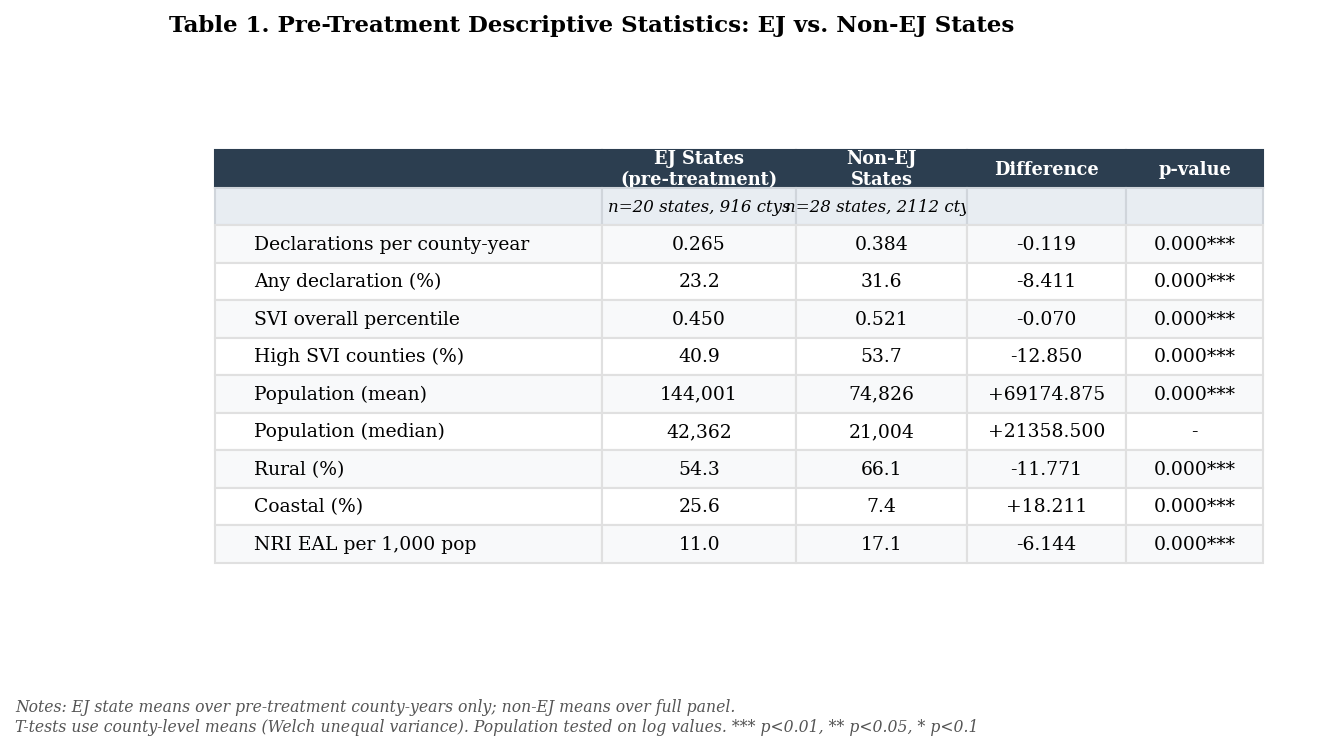

In [15]:
# Table 1 - Pre-Treatment Balance

from scipy.stats import ttest_ind

pre_sw = did[(did['is_sw']==1) & (did['post']==0)]
pre_nt = did[did['is_nt']==1]
nc_sw = pre_sw['FIPS'].nunique(); nc_nt = pre_nt['FIPS'].nunique()

def ttest_c(var):
    s = pre_sw.groupby('FIPS')[var].mean().dropna()
    n = pre_nt.groupby('FIPS')[var].mean().dropna()
    if len(s)>1 and len(n)>1:
        _, p = ttest_ind(s, n, equal_var=False)
        return p
    return np.nan

def sig(p):
    if np.isnan(p): return ''
    return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''

pop_sw = pre_sw.groupby('FIPS')['pop22'].first().dropna()
pop_nt = pre_nt.groupby('FIPS')['pop22'].first().dropna()
_, pop_p = ttest_ind(np.log(pop_sw+1), np.log(pop_nt+1), equal_var=False)

eal_sw = pre_sw.groupby('FIPS')['nri_pc'].first().dropna()
eal_nt = pre_nt.groupby('FIPS')['nri_pc'].first().dropna()
_, eal_p = ttest_ind(eal_sw, eal_nt, equal_var=False)

variables = [
    ('Declarations per county-year', pre_sw['ndecl'].mean(), pre_nt['ndecl'].mean(), '.3f', ttest_c('ndecl')),
    ('Any declaration (%)',          pre_sw['anydecl'].mean()*100, pre_nt['anydecl'].mean()*100, '.1f', ttest_c('anydecl')),
    ('SVI overall percentile',       pre_sw['svi22'].mean(), pre_nt['svi22'].mean(), '.3f', ttest_c('svi22')),
    ('High SVI counties (%)',        pre_sw['hsvi'].mean()*100, pre_nt['hsvi'].mean()*100, '.1f', ttest_c('hsvi')),
    ('Population (mean)',            pop_sw.mean(), pop_nt.mean(), ',.0f', pop_p),
    ('Population (median)',          pop_sw.median(), pop_nt.median(), ',.0f', np.nan),
    ('Rural (%)',                    pre_sw['rural'].mean()*100, pre_nt['rural'].mean()*100, '.1f', ttest_c('rural')),
    ('Coastal (%)',                  pre_sw['coastal'].mean()*100, pre_nt['coastal'].mean()*100, '.1f', ttest_c('coastal')),
    ('NRI EAL per 1,000 pop',       eal_sw.mean()*1e6, eal_nt.mean()*1e6, '.1f', eal_p),
]

# Console output
print("TABLE 1: Pre-Treatment Balance\n")
print(f"{'':40s} {'EJ States':>12s} {'Non-EJ':>12s} {'Diff':>10s} {'p':>10s}")
for name, tv, cv, fmt, pv in variables:
    ps = f"{pv:.3f}{sig(pv)}" if not np.isnan(pv) else ''
    print(f"{name:40s} {format(tv,fmt):>12s} {format(cv,fmt):>12s} {tv-cv:+10.3f} {ps:>10s}")
print(f"\n{'':40s} {str(nsw)+' states':>12s} {str(nnt)+' states':>12s}")
print(f"{'':40s} {str(nc_sw)+' counties':>12s} {str(nc_nt)+' counties':>12s}")

# Publication figure
fig, ax = plt.subplots(figsize=(9.8, 5.2))
ax.axis('off')

col_labels = ['', 'EJ States\n(pre-treatment)', 'Non-EJ\nStates', 'Difference', 'p-value']
cell_data = [['', f'n={nsw} states, {nc_sw} ctys', f'n={nnt} states, {nc_nt} ctys', '', '']]
for name, tv, cv, fmt, pv in variables:
    pstr = f"{pv:.3f}{sig(pv)}" if not np.isnan(pv) else '-'
    cell_data.append([name, format(tv,fmt), format(cv,fmt), f"{tv-cv:+.3f}", pstr])

table = ax.table(cellText=cell_data, colLabels=col_labels,
                 cellLoc='center', loc='center',
                 colWidths=[0.34, 0.17, 0.15, 0.14, 0.12])
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.5)

for j in range(5):
    c = table[0,j]; c.set_facecolor('#2C3E50')
    c.set_text_props(color='white', fontweight='bold', fontsize=8.5); c.set_edgecolor('#2C3E50')
for j in range(5):
    c = table[1,j]; c.set_facecolor('#E8EDF2')
    c.set_text_props(fontstyle='italic', fontsize=8); c.set_edgecolor('#D0D5DB')
for i in range(2, len(cell_data)+1):
    for j in range(5):
        c = table[i,j]; c.set_facecolor('#F8F9FA' if i%2==0 else 'white'); c.set_edgecolor('#E0E0E0')
        if j==0: c.set_text_props(ha='left')

ax.set_title('Table 1. Pre-Treatment Descriptive Statistics: EJ vs. Non-EJ States',
             fontweight='bold', fontsize=11, pad=12, loc='left', fontfamily='serif')
note = ('Notes: EJ state means over pre-treatment county-years only; '
        'non-EJ means over full panel.\n'
        'T-tests use county-level means (Welch unequal variance). '
        'Population tested on log values. '
        '*** p<0.01, ** p<0.05, * p<0.1')
fig.text(0.02, 0.01, note,
         fontsize=7.5, fontstyle='italic', color='#555555',
         va='bottom', fontfamily='serif')

In [16]:
# Table 2

print("TABLE 2\n")
r1 = ols(df,'ndecl',xm,ctrls=CTR)
r2 = ols(did,'ndecl',xm,ctrls=CTR)
r3 = ols(did_mod,'ndecl',xm,ctrls=CTR)
r4 = ols(did,'ndecl',xm,ctrls=CTR+['nri_pc'])
r5 = ols(did,'anydecl',xm,ctrls=CTR)
r6 = ols(did,'ndecl',xm,ctrls=CTR,cl='FIPS')
r7 = poisson_mod(did,'ndecl',xm,ctrls=CTR)
t2 = rtable([r1,r2,r3,r4,r5,r6,r7],
            ['Full','Pref','NoCaOr','+NRI','Binary','Co.cl','Poisson'], xm)
print(t2.to_string(index=False))
t2.to_csv('table2.csv', index=False)
print("\nPreferred OLS:")
pcoef(r2,'post_hsvi','Triple-diff')
if r7: print("Poisson:"); pcoef(r7,'post_hsvi','Triple-diff')

TABLE 2

              Full     Pref    NoCaOr     +NRI   Binary      Co.cl  Poisson
     post  -0.0390  -0.0269   -0.0248  -0.0269  -0.0090 -0.0269***  -0.1189
          (0.0400) (0.0402)  (0.0418) (0.0402) (0.0267)   (0.0100) (0.1227)
     hsvi   0.0091   0.0088    0.0090   0.0087   0.0048    0.0088*   0.0260
          (0.0086) (0.0086)  (0.0087) (0.0086) (0.0053)   (0.0050) (0.0245)
post_hsvi  -0.0192 -0.0341* -0.0455** -0.0341* -0.0226* -0.0341***  -0.1433
          (0.0176) (0.0194)  (0.0195) (0.0194) (0.0135)   (0.0124) (0.0879)
        N   81,484   78,520    77,584   78,520   78,520     78,520   78,520
       R2   0.1656   0.1670    0.1657   0.1670   0.1702     0.1670       --
 Dep mean   0.3433   0.3466    0.3479   0.3466   0.2903     0.3466   0.3466

Preferred OLS:
  Triple-diff: -0.0341*  SE=0.0194  p=0.0785  [-0.0722,0.0039]
Poisson:
  Triple-diff: -0.1433  SE=0.0879  p=0.1031  [-0.3156,0.0290]


In [17]:
# Table 3

print("TABLE 3\n")
tvars = ['post_t1','post_t2','post_t3','hsvi',
         't1_hsvi','t2_hsvi','t3_hsvi','post_t1_hsvi','post_t2_hsvi','post_t3_hsvi']
rpool = ols(did,'ndecl',tvars,ctrls=CTR)
print("Pooled:")
for i,l in [(1,'Tier 1 Strong'),(2,'Tier 2 Dev'),(3,'Tier 3 Policy')]:
    pcoef(rpool, f'post_t{i}_hsvi', l)
print("\nSeparate:")
tmods = {}
for tc,tl in [(1,'Tier1'),(2,'Tier2'),(3,'Tier3')]:
    ss = did[(did[f't{tc}']==1)|(did['is_nt']==1)]
    m = ols(ss,'ndecl',xm,ctrls=CTR); tmods[tl]=m
    ne = ss.loc[ss[f't{tc}']==1,'stfips'].nunique()
    nc = ss.loc[ss['is_nt']==1,'stfips'].nunique()
    print(f"\n  {tl} ({ne} EJ vs {nc} ctrl):")
    pcoef(m,'post_hsvi','    OLS')
    mp = poisson_mod(ss,'ndecl',xm,ctrls=CTR)
    if mp: pcoef(mp,'post_hsvi','    Poisson')
rtable(list(tmods.values()),list(tmods.keys()),xm).to_csv('table3.csv',index=False)

TABLE 3

Pooled:
  Tier 1 Strong: -0.0043  SE=0.0384  p=0.9100  [-0.0795,0.0709]
  Tier 2 Dev: -0.0059  SE=0.0270  p=0.8284  [-0.0588,0.0471]
  Tier 3 Policy: -0.0865*  SE=0.0512  p=0.0910  [-0.1868,0.0138]

Separate:

  Tier1 (6 EJ vs 28 ctrl):
      OLS: -0.0345  SE=0.0322  p=0.2842  [-0.0976,0.0286]
      Poisson: -0.0916  SE=0.1183  p=0.4388  [-0.3233,0.1402]

  Tier2 (8 EJ vs 28 ctrl):
      OLS: -0.0275  SE=0.0217  p=0.2055  [-0.0700,0.0151]
      Poisson: -0.1087  SE=0.0930  p=0.2424  [-0.2911,0.0736]

  Tier3 (6 EJ vs 28 ctrl):
      OLS: -0.0890**  SE=0.0415  p=0.0319  [-0.1702,-0.0077]
      Poisson: -0.5245**  SE=0.2227  p=0.0185  [-0.9610,-0.0879]


In [18]:
# H2 + H3

# ── H2: EJ effects strongest for highest-SVI quartile ──
# Labels match Ch1: Q1=Low, Q2=Moderate, Q3=High, Q4=Very High

print("H2: VULNERABILITY GRADIENT\n")

qlabels = {'Q1':'Low','Q2':'Moderate','Q3':'High','Q4':'Very High'}

for q in ['Q1','Q2','Q3','Q4']:
    did[f'is{q}']=(did['sviq']==q).astype(int)
    did[f'post_{q}']=did['post']*did[f'is{q}']

rq = ols(did,'ndecl',['post','isQ2','isQ3','isQ4','post_Q2','post_Q3','post_Q4'],ctrls=CTR)

# Print full gradient: post = Q1 baseline, post_Q2/Q3/Q4 = incremental
print("EJ effect by SVI quartile (Q1 Low is reference):")
pcoef(rq,'post','  Q1 (Low) - baseline EJ effect')
pcoef(rq,'post_Q2','  Q2 (Moderate) - additional')
pcoef(rq,'post_Q3','  Q3 (High) - additional')
pcoef(rq,'post_Q4','  Q4 (Very High) - additional')

# Total effect at each quartile
print("\nTotal EJ effect by quartile:")
b0 = rq.get('post',{}).get('b',0)
for q,lab in [('post_Q2','Moderate'),('post_Q3','High'),('post_Q4','Very High')]:
    r = rq.get(q,{})
    if r: print(f"  {lab}: {b0 + r['b']:.4f}  (baseline {b0:.4f} + increment {r['b']:.4f})")
print(f"  Low (reference): {b0:.4f}")

# Monotonicity test: is the gradient increasing Q1→Q4?
print("\nMonotonicity test:")
increments = []
for q in ['post_Q2','post_Q3','post_Q4']:
    r = rq.get(q,{})
    if r: increments.append(r['b'])
if len(increments)==3:
    monotonic = increments[0] <= increments[1] <= increments[2]
    print(f"  Increments: Q2={increments[0]:.4f}, Q3={increments[1]:.4f}, Q4={increments[2]:.4f}")
    print(f"  Monotonically increasing: {'Yes' if monotonic else 'No'}")
    # Jonckheere-style: test Q4 > Q2 (strongest vs weakest non-reference)
    if rq.get('post_Q4') and rq.get('post_Q2'):
        b4,b2 = rq['post_Q4']['b'], rq['post_Q2']['b']
        s4,s2 = rq['post_Q4']['se'], rq['post_Q2']['se']
        z_mono = (b4-b2)/np.sqrt(s4**2+s2**2)
        p_mono = stats.norm.cdf(z_mono)  # one-sided: Q4 MORE negative than Q2
        print(f"  Q4 vs Q2 difference: {b4-b2:.4f}, z={z_mono:.3f}, p={p_mono:.4f} (one-sided)")
        print(f"  {'Supports H2' if p_mono < .1 else 'Does not support H2'}: effects {'concentrate' if p_mono < .1 else 'do not concentrate'} in highest quartile")

# Q4 vs Q1 subsample (direct test)
print("\nQ4 vs Q1 direct comparison:")
q41=did[did['sviq'].isin(['Q1','Q4'])].copy()
q41['isq4']=(q41['sviq']=='Q4').astype(int); q41['post_q4']=q41['post']*q41['isq4']
pcoef(ols(q41,'ndecl',['post','isq4','post_q4'],ctrls=CTR),'post_q4','Post x Very High SVI')


# ── H3: Statutory vs policy-only frameworks ──

print("\n\nH3: STATUTORY vs POLICY-ONLY\n")
did['stat']=((did['t1']==1)|(did['t2']==1)).astype(int); did['pol']=(did['t3']==1).astype(int)
did['post_stat']=did['post']*did['stat']; did['post_pol']=did['post']*did['pol']
did['stat_h']=did['stat']*did['hsvi']; did['pol_h']=did['pol']*did['hsvi']
did['pstat_h']=did['post_stat']*did['hsvi']; did['ppol_h']=did['post_pol']*did['hsvi']
rh3 = ols(did,'ndecl',['post_stat','post_pol','hsvi','stat_h','pol_h','pstat_h','ppol_h'],ctrls=CTR)
pcoef(rh3,'pstat_h','Statutory (T1+T2) x HighSVI'); pcoef(rh3,'ppol_h','Policy-only (T3) x HighSVI')
try:
    b1,b2=rh3['pstat_h']['b'],rh3['ppol_h']['b']
    s1,s2=rh3['pstat_h']['se'],rh3['ppol_h']['se']
    z=(b1-b2)/np.sqrt(s1**2+s2**2)
    print(f"\nWald test (statutory = policy): z={z:.3f}, p={2*(1-stats.norm.cdf(abs(z))):.4f}")
    print(f"  {'Statutory outperforms policy' if b1>b2 and 2*(1-stats.norm.cdf(abs(z)))<.1 else 'Cannot distinguish statutory from policy'}")
except: pass

H2: VULNERABILITY GRADIENT

EJ effect by SVI quartile (Q1 Low is reference):
    Q1 (Low) - baseline EJ effect: -0.0051  SE=0.0395  p=0.8981  [-0.0825,0.0724]
    Q2 (Moderate) - additional: -0.0407**  SE=0.0165  p=0.0133  [-0.0730,-0.0085]
    Q3 (High) - additional: -0.0325  SE=0.0268  p=0.2250  [-0.0850,0.0200]
    Q4 (Very High) - additional: -0.0888***  SE=0.0209  p=0.0000  [-0.1298,-0.0477]

Total EJ effect by quartile:
  Moderate: -0.0458  (baseline -0.0051 + increment -0.0407)
  High: -0.0376  (baseline -0.0051 + increment -0.0325)
  Very High: -0.0938  (baseline -0.0051 + increment -0.0888)
  Low (reference): -0.0051

Monotonicity test:
  Increments: Q2=-0.0407, Q3=-0.0325, Q4=-0.0888
  Monotonically increasing: No
  Q4 vs Q2 difference: -0.0480, z=-1.804, p=0.0356 (one-sided)
  Supports H2: effects concentrate in highest quartile

Q4 vs Q1 direct comparison:
  Post x Very High SVI: -0.0857***  SE=0.0207  p=0.0000  [-0.1262,-0.0451]


H3: STATUTORY vs POLICY-ONLY

  Statutory 

## Additional Tests

In [19]:
# SVI theme decomposition

print("SVI THEME DECOMPOSITION\n")
if 'hsvi_econ' in did.columns and 'hsvi_min' in did.columns:
    re = ols(did,'ndecl',['post','hsvi_econ','post_hsvi_econ'],ctrls=CTR)
    print("Theme 1 - Socioeconomic disadvantage:")
    pcoef(re,'post_hsvi_econ','  Post x HiSocioEcon')
    rm = ols(did,'ndecl',['post','hsvi_min','post_hsvi_min'],ctrls=CTR)
    print("\nTheme 3 - Minority/Language:")
    pcoef(rm,'post_hsvi_min','  Post x HiMinority')
    rb = ols(did,'ndecl',['post','hsvi_econ','hsvi_min','post_hsvi_econ','post_hsvi_min'],ctrls=CTR)
    print("\nBoth in same model:")
    pcoef(rb,'post_hsvi_econ','  Post x HiSocioEcon')
    pcoef(rb,'post_hsvi_min','  Post x HiMinority')

SVI THEME DECOMPOSITION

Theme 1 - Socioeconomic disadvantage:
    Post x HiSocioEcon: -0.0385***  SE=0.0137  p=0.0050  [-0.0654,-0.0116]

Theme 3 - Minority/Language:
    Post x HiMinority: -0.0378  SE=0.0255  p=0.1380  [-0.0878,0.0122]

Both in same model:
    Post x HiSocioEcon: -0.0287*  SE=0.0171  p=0.0941  [-0.0623,0.0049]
    Post x HiMinority: -0.0300  SE=0.0284  p=0.2911  [-0.0858,0.0257]


DOSE-RESPONSE

  Years since: -0.0096**  SE=0.0047  p=0.0411  [-0.0189,-0.0004]
  Years since x HighSVI: 0.0039  SE=0.0033  p=0.2445  [-0.0026,0.0104]

Binned dose:
    0-2 yrs x HighSVI: -0.0941***  SE=0.0346  p=0.0065  [-0.1618,-0.0263]
    3-5 yrs x HighSVI: 0.0132  SE=0.0263  p=0.6143  [-0.0383,0.0648]
    6+ yrs x HighSVI: 0.0334  SE=0.0350  p=0.3405  [-0.0353,0.1020]


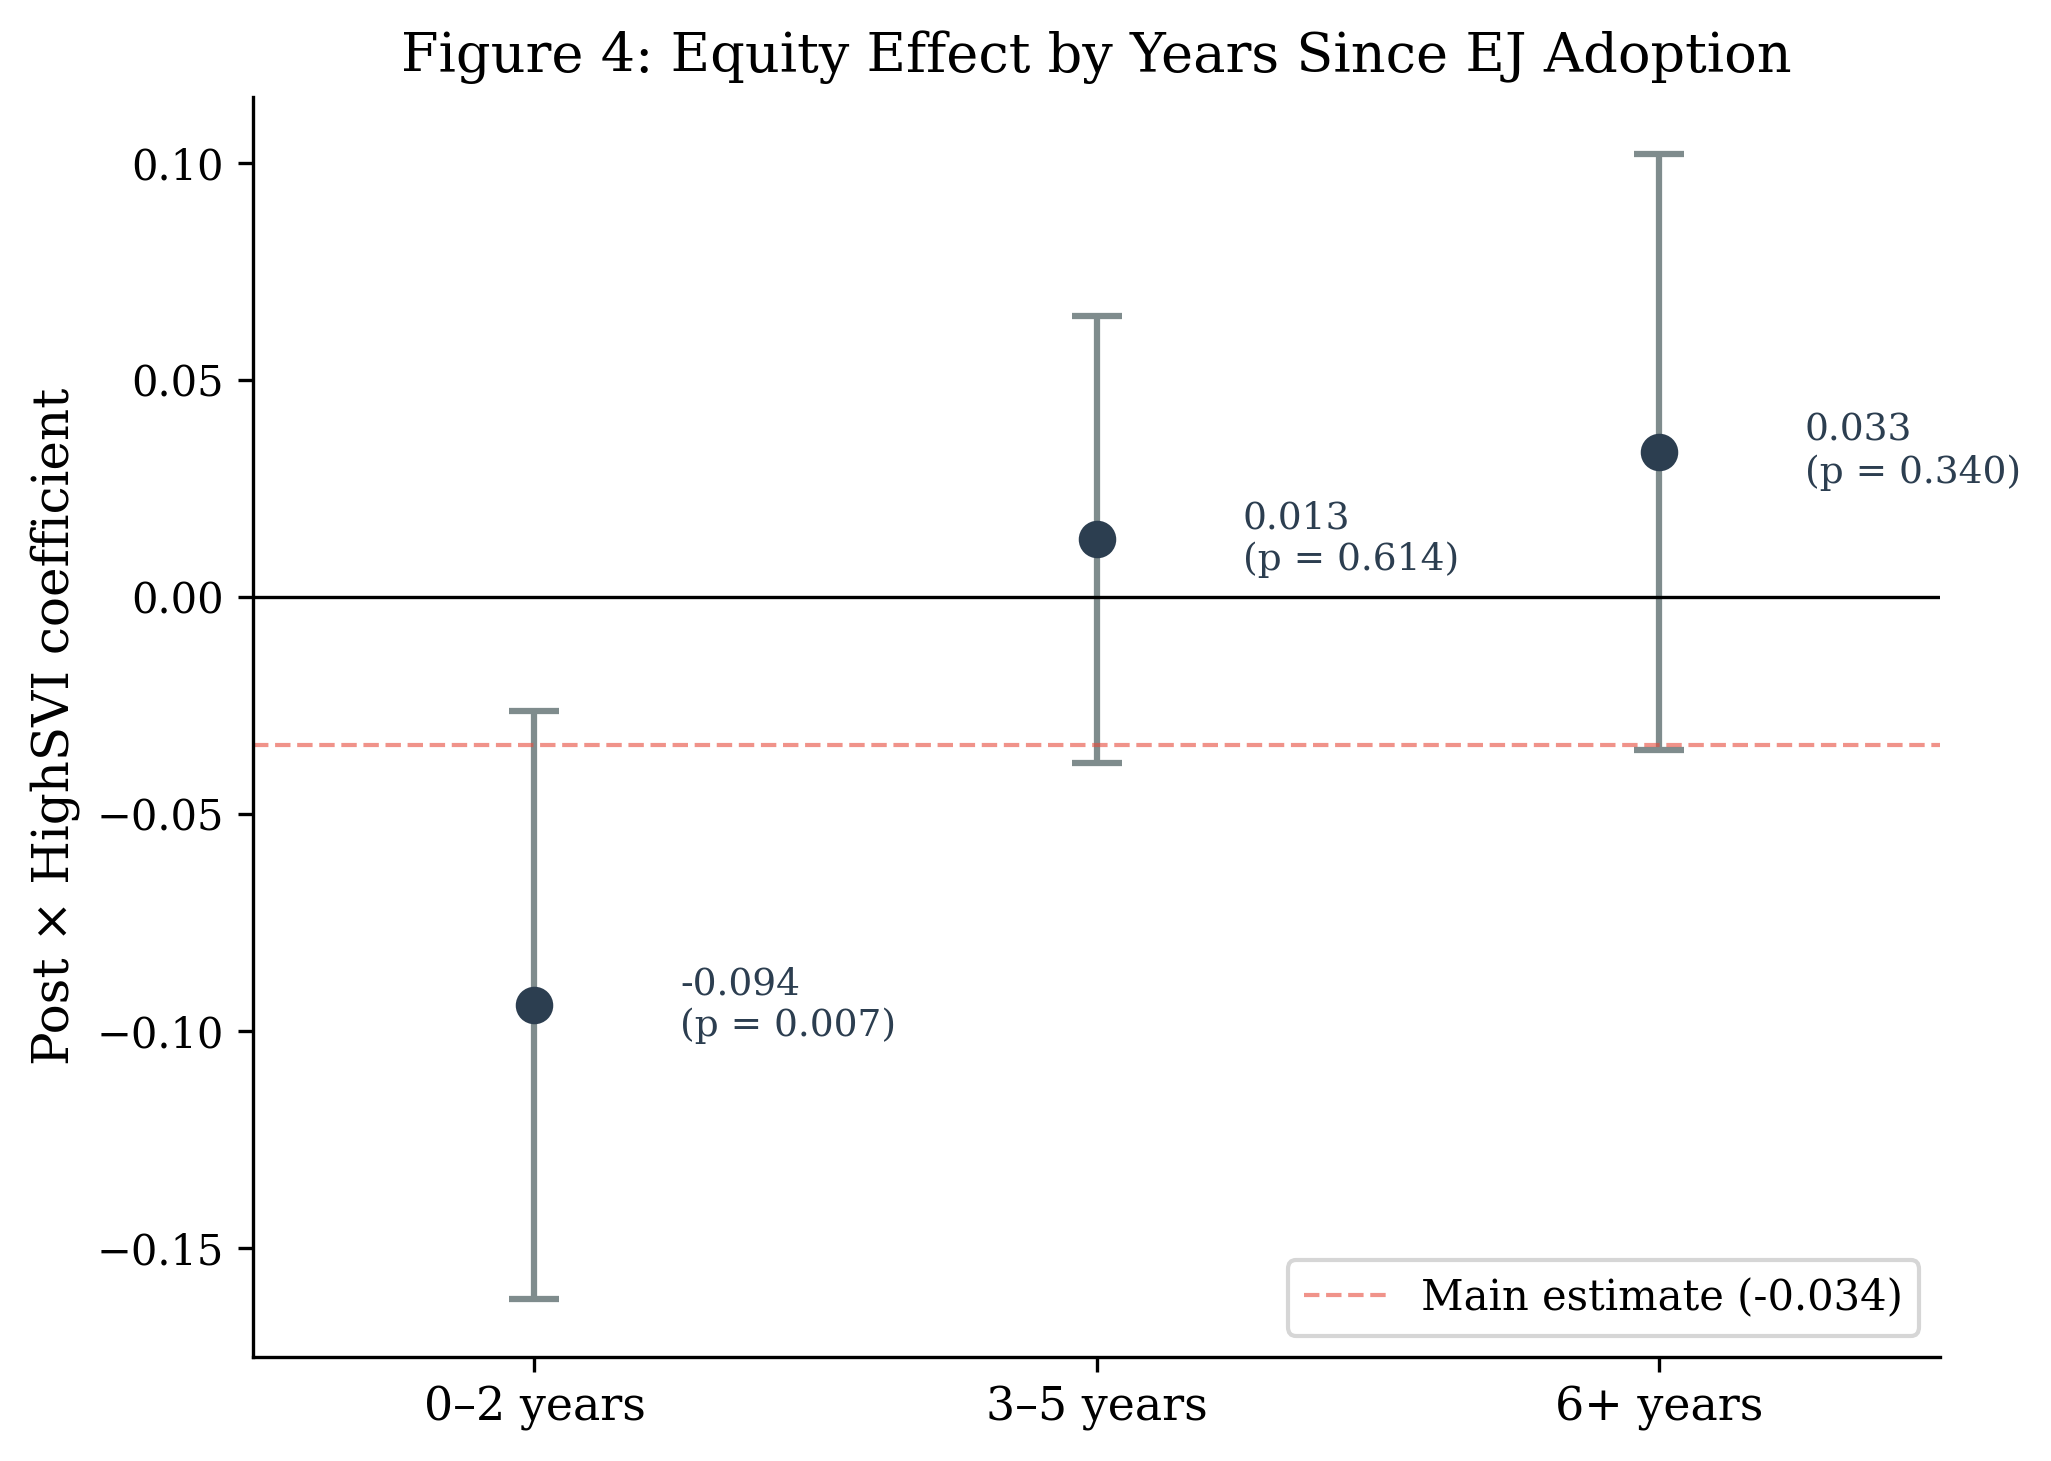

In [20]:
# Dose-response

print("DOSE-RESPONSE\n")
rd1 = ols(did,'ndecl',['dose','hsvi','dose_hsvi'],ctrls=CTR)
pcoef(rd1,'dose','Years since'); pcoef(rd1,'dose_hsvi','Years since x HighSVI')

did['dose_bin']='never'
did.loc[(did['rel_t']>=0)&(did['rel_t']<=2),'dose_bin']='short'
did.loc[(did['rel_t']>=3)&(did['rel_t']<=5),'dose_bin']='medium'
did.loc[did['rel_t']>5,'dose_bin']='long'
did['d_short']=(did['dose_bin']=='short').astype(int)
did['d_med']=(did['dose_bin']=='medium').astype(int)
did['d_long']=(did['dose_bin']=='long').astype(int)
did['ds_h']=did['d_short']*did['hsvi']; did['dm_h']=did['d_med']*did['hsvi']
did['dl_h']=did['d_long']*did['hsvi']
rd2 = ols(did,'ndecl',['d_short','d_med','d_long','hsvi','ds_h','dm_h','dl_h'],ctrls=CTR)
print("\nBinned dose:")
pcoef(rd2,'ds_h','  0-2 yrs x HighSVI'); pcoef(rd2,'dm_h','  3-5 yrs x HighSVI')
pcoef(rd2,'dl_h','  6+ yrs x HighSVI')
# ── Figure 4: Binned Dose-Response ──
import matplotlib.pyplot as plt
import numpy as np

labels = ['ds_h', 'dm_h', 'dl_h']
bins   = ['0–2 years', '3–5 years', '6+ years']
coefs  = [rd2[k]['b']  for k in labels]
ci_lo  = [rd2[k]['lo'] for k in labels]
ci_hi  = [rd2[k]['hi'] for k in labels]
ps     = [rd2[k]['p']  for k in labels]
main_b = r2['post_hsvi']['b']

errors_lo = [c - lo for c, lo in zip(coefs, ci_lo)]
errors_hi = [hi - c for c, hi in zip(coefs, ci_hi)]

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
x = np.arange(len(bins))

ax.errorbar(x, coefs, yerr=[errors_lo, errors_hi],
            fmt='o', color='#2c3e50', markersize=8, capsize=6,
            ecolor='#7f8c8d', elinewidth=1.5, capthick=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.axhline(main_b, color='#e74c3c', linewidth=1, linestyle='--',
           alpha=0.6, label=f'Main estimate ({main_b:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=11)
ax.set_ylabel('Post × HighSVI coefficient', fontsize=12)
ax.set_title('Figure 4: Equity Effect by Years Since EJ Adoption', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.5, 2.5)

for i, (c, p) in enumerate(zip(coefs, ps)):
    ax.annotate(f'{c:.3f}\n(p = {p:.3f})', xy=(i, c),
                xytext=(35, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9, color='#2c3e50')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figure4_dose_response.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Leave-one-out

print("LEAVE-ONE-OUT\n")
sw_fips = did.loc[did['is_sw']==1,'stfips'].unique()
loo_results = []
for sf in sw_fips:
    sname = ej.loc[ej['State_FIPS']==sf,'State'].iloc[0]
    m = ols(did[did['stfips']!=sf],'ndecl',xm,ctrls=CTR)
    r = m.get('post_hsvi',{})
    loo_results.append({'state':sname,'fips':sf,'b':r.get('b',np.nan),
                         'se':r.get('se',np.nan),'p':r.get('p',np.nan),'sig':r.get('sig','')})
loo = pd.DataFrame(loo_results).sort_values('b')
print(loo[['state','b','se','p','sig']].to_string(index=False))
main_b = r2.get('post_hsvi',{}).get('b',0)
loo['shift'] = loo['b']-main_b
biggest = loo.loc[loo['shift'].abs().idxmax()]
print(f"\nMain: {main_b:.4f}. Most influential: {biggest['state']} (shift={biggest['shift']:+.4f})")
print(f"Range: [{loo['b'].min():.4f}, {loo['b'].max():.4f}]")

LEAVE-ONE-OUT

         state         b       se        p sig
        Oregon -0.045474 0.019460 0.019451  **
      Virginia -0.041893 0.020771 0.043711  **
    Washington -0.041766 0.019757 0.034519  **
  Pennsylvania -0.036964 0.020004 0.064620   *
 Massachusetts -0.035733 0.019771 0.070707   *
      Maryland -0.035718 0.019779 0.070935   *
      New York -0.035182 0.020515 0.086351   *
    New Mexico -0.034860 0.020006 0.081429   *
  Rhode Island -0.034591 0.019529 0.076525   *
   Connecticut -0.034137 0.019400 0.078470   *
        Hawaii -0.034074 0.019480 0.080253   *
     Minnesota -0.033324 0.020626 0.106167    
      Delaware -0.033262 0.019343 0.085507   *
      Colorado -0.032788 0.020212 0.104749    
      Illinois -0.031831 0.025161 0.205843    
    New Jersey -0.031469 0.019413 0.105013    
      Michigan -0.031267 0.019650 0.111573    
         Maine -0.029194 0.018567 0.115875    
       Vermont -0.027720 0.018069 0.125007    
North Carolina -0.027498 0.018339 0.133754   

In [22]:
# Timing decomposition

print("TIMING DECOMPOSITION\n")
early_fips = ej.loc[(ej['Treatment_Year']<2020)&(ej['Treatment_Year']>=YR0)&
                     (~ej['State_FIPS'].isin(at_fips)),'State_FIPS'].tolist()
nt_fips = did.loc[did['is_nt']==1,'stfips'].unique().tolist()
re = ols(did[did['stfips'].isin(early_fips+nt_fips)],'ndecl',xm,ctrls=CTR)
print(f"Early (<2020) vs never ({len(early_fips)} states):"); pcoef(re,'post_hsvi')
late_fips = ej.loc[(ej['Treatment_Year']>=2020)&(~ej['State_FIPS'].isin(at_fips)),'State_FIPS'].tolist()
rl = ols(did[did['stfips'].isin(late_fips+nt_fips)],'ndecl',xm,ctrls=CTR)
print(f"\nLate (2020+) vs never ({len(late_fips)} states):"); pcoef(rl,'post_hsvi')
rb = ols(did[did['stfips'].isin(early_fips+late_fips)],'ndecl',xm,ctrls=CTR)
print(f"\nLate vs early (problematic comparison):"); pcoef(rb,'post_hsvi')

TIMING DECOMPOSITION

Early (<2020) vs never (5 states):
  post_hsvi: -0.0096  SE=0.0217  p=0.6581  [-0.0522,0.0330]

Late (2020+) vs never (15 states):
  post_hsvi: -0.0682**  SE=0.0285  p=0.0168  [-0.1241,-0.0123]

Late vs early (problematic comparison):
  post_hsvi: -0.0143  SE=0.0218  p=0.5112  [-0.0571,0.0284]


In [23]:
# H4: implementation tools vs. no tools

print("FRAMEWORK FEATURES\n")
if 'EJ_Mapping_Tool' in did.columns:
    did['has_map']=did['EJ_Mapping_Tool'].fillna(0).astype(int)
    did['post_map']=did['post']*did['has_map']
    did['post_map_h']=did['post_map']*did['hsvi']
    did['nomap']=((did['anyej']==1)&(did['has_map']==0)).astype(int)
    did['post_nomap']=did['post']*did['nomap']
    did['post_nomap_h']=did['post_nomap']*did['hsvi']
    rf = ols(did,'ndecl',['post_map','post_nomap','hsvi','post_map_h','post_nomap_h'],ctrls=CTR)
    print("Mapping Tool:"); pcoef(rf,'post_map_h','  With tool x HighSVI')
    pcoef(rf,'post_nomap_h','  Without x HighSVI')
if 'Cumulative_Impacts' in did.columns:
    did['has_ci']=did['Cumulative_Impacts'].fillna(0).astype(int)
    did['post_ci']=did['post']*did['has_ci']; did['post_ci_h']=did['post_ci']*did['hsvi']
    did['noci']=((did['anyej']==1)&(did['has_ci']==0)).astype(int)
    did['post_noci']=did['post']*did['noci']; did['post_noci_h']=did['post_noci']*did['hsvi']
    rc = ols(did,'ndecl',['post_ci','post_noci','hsvi','post_ci_h','post_noci_h'],ctrls=CTR)
    print("\nCumulative Impacts:"); pcoef(rc,'post_ci_h','  With CI x HighSVI')
    pcoef(rc,'post_noci_h','  Without CI x HighSVI')

FRAMEWORK FEATURES

Mapping Tool:
    With tool x HighSVI: -0.0351**  SE=0.0169  p=0.0382  [-0.0683,-0.0019]
    Without x HighSVI: -0.0801  SE=0.0894  p=0.3708  [-0.2554,0.0953]

Cumulative Impacts:
    With CI x HighSVI: -0.0802**  SE=0.0331  p=0.0153  [-0.1451,-0.0154]
    Without CI x HighSVI: -0.0246  SE=0.0220  p=0.2624  [-0.0677,0.0184]


## Figures


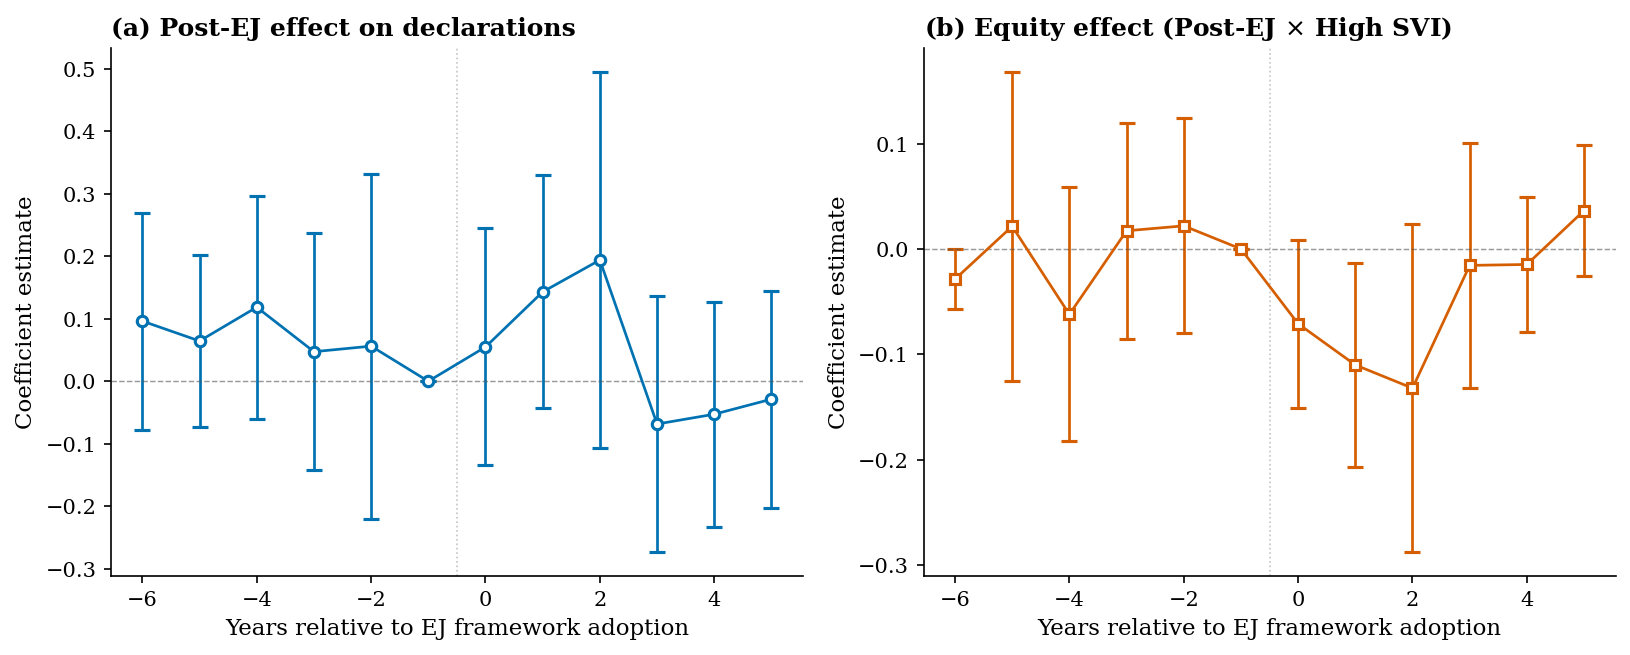

Pre-period (equity):
  t=-6: -0.0287**  p=0.0487
  t=-5: 0.0215  p=0.7737
  t=-4: -0.0621  p=0.3128
  t=-3: 0.0172  p=0.7421
  t=-2: 0.0219  p=0.6741


In [24]:
# Figure 2-4: Event Study Estimates Around State EJ Framework Adoption

esamp = did[(did['is_sw']==1)|(did['is_nt']==1)].copy()

def _bintime(x):
    if pd.isna(x): return None
    return max(-6, min(5, int(x)))

esamp['evt'] = esamp['rel_t'].apply(_bintime)
etlist = sorted(set(int(t) for t in esamp['evt'].dropna().unique() if int(t)!=-1))
for t in etlist:
    esamp[f'd{t}']=(esamp['evt']==t).astype(int)
    esamp[f'd{t}_h']=esamp[f'd{t}']*esamp['hsvi']
esvars = [f'd{t}' for t in etlist]+['hsvi']+[f'd{t}_h' for t in etlist]
res_es = ols(esamp,'ndecl',esvars,ctrls=CTR)

alltimes = sorted(etlist+[-1])
fig, (a1,a2) = plt.subplots(1, 2, figsize=(11, 4.5))

# panel a
ba=[]; sa=[]
for t in alltimes:
    if t==-1: ba.append(0); sa.append(0)
    elif f'd{t}' in res_es: ba.append(res_es[f'd{t}']['b']); sa.append(res_es[f'd{t}']['se'])
    else: ba.append(np.nan); sa.append(np.nan)
a1.errorbar(alltimes, ba, yerr=[1.96*s for s in sa],
            fmt='o-', capsize=4, color=CB_BLUE, ms=5, lw=1.3,
            markerfacecolor='white', markeredgewidth=1.5, markeredgecolor=CB_BLUE)
a1.axhline(0, color='#555555', ls='--', lw=0.7, alpha=.6)
a1.axvline(-0.5, color='#888888', ls=':', lw=0.8, alpha=.5)
a1.set_xlabel('Years relative to EJ framework adoption')
a1.set_ylabel('Coefficient estimate')
a1.set_title('(a) Post-EJ effect on declarations', fontweight='bold', loc='left')

# panel b
bb=[]; sb=[]
for t in alltimes:
    if t==-1: bb.append(0); sb.append(0)
    elif f'd{t}_h' in res_es: bb.append(res_es[f'd{t}_h']['b']); sb.append(res_es[f'd{t}_h']['se'])
    else: bb.append(np.nan); sb.append(np.nan)
a2.errorbar(alltimes, bb, yerr=[1.96*s for s in sb],
            fmt='s-', capsize=4, color=CB_RED, ms=5, lw=1.3,
            markerfacecolor='white', markeredgewidth=1.5, markeredgecolor=CB_RED)
a2.axhline(0, color='#555555', ls='--', lw=0.7, alpha=.6)
a2.axvline(-0.5, color='#888888', ls=':', lw=0.8, alpha=.5)
a2.set_xlabel('Years relative to EJ framework adoption')
a2.set_ylabel('Coefficient estimate')
a2.set_title('(b) Equity effect (Post-EJ $\\times$ High SVI)', fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('Figure_2-4_Event_Study.png', dpi=300); plt.savefig('Figure_2-4_Event_Study.pdf')
plt.show()

print("Pre-period (equity):")
for t in [t for t in etlist if t<-1]:
    r=res_es.get(f'd{t}_h')
    if r: print(f"  t={t:+d}: {r['b']:.4f}{r['sig']}  p={r['p']:.4f}")

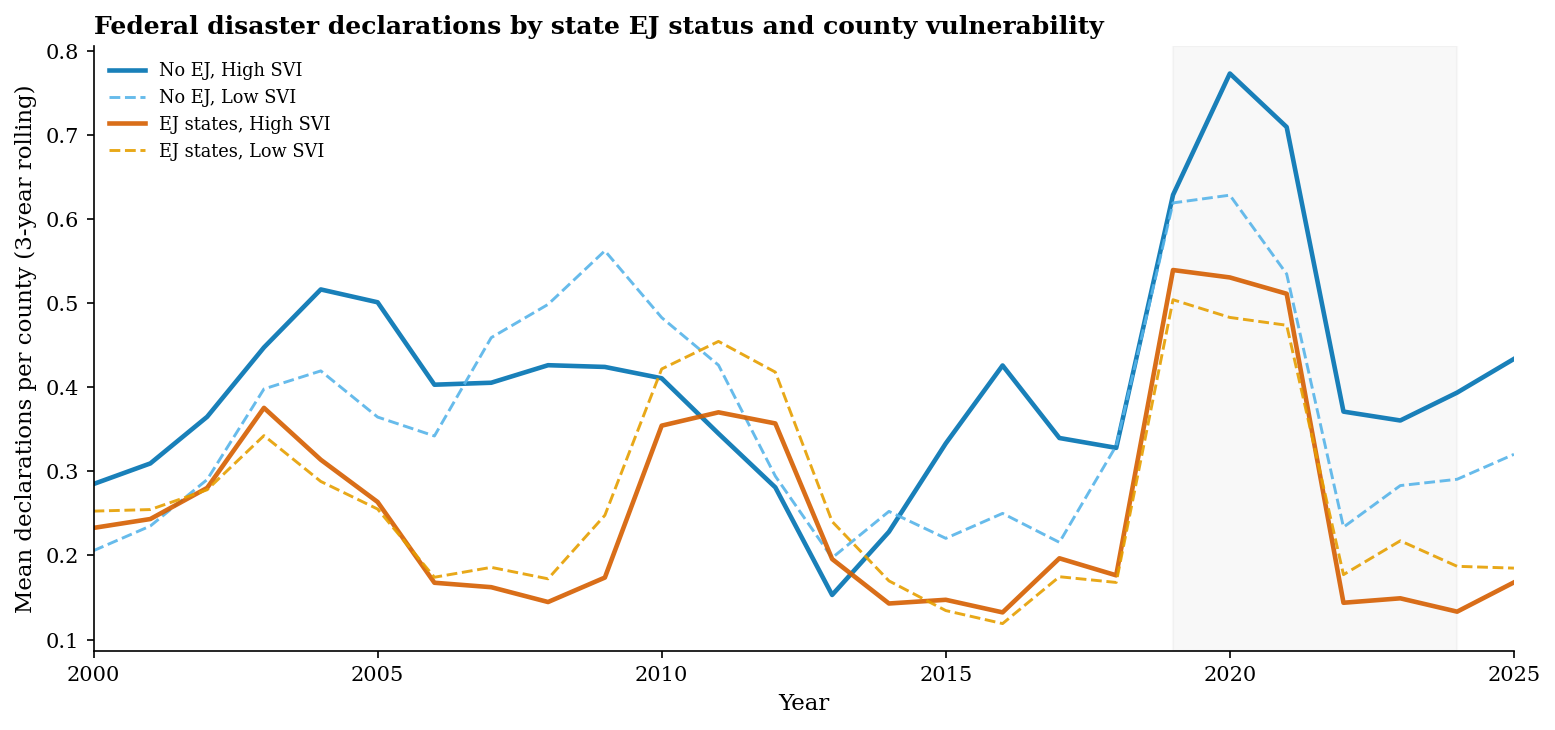

In [25]:
# Figure 2-1: Federal Disaster Declarations by State EJ Status and County Vulnerability

groups = {
    'No EJ, High SVI':  did[(did['is_nt']==1)&(did['hsvi']==1)],
    'No EJ, Low SVI':   did[(did['is_nt']==1)&(did['hsvi']==0)],
    'EJ states, High SVI': did[(did['anyej']==1)&(did['hsvi']==1)],
    'EJ states, Low SVI':  did[(did['anyej']==1)&(did['hsvi']==0)],
}
# Wong palette, solid vs dashed, thick vs thin
styles = {
    'No EJ, High SVI':    {'color':CB_BLUE,   'ls':'-',  'lw':2.2},
    'No EJ, Low SVI':     {'color':CB_SKYBLUE,'ls':'--', 'lw':1.4},
    'EJ states, High SVI':{'color':CB_RED,    'ls':'-',  'lw':2.2},
    'EJ states, Low SVI': {'color':CB_ORANGE, 'ls':'--', 'lw':1.4},
}

fig, ax = plt.subplots(figsize=(10.5, 5))
for lab, grp in groups.items():
    ts = grp.groupby('year')['ndecl'].mean().rolling(3, center=True, min_periods=1).mean()
    ax.plot(ts.index, ts.values, label=lab, **styles[lab], alpha=.9)

ax.axvspan(2019, 2024, alpha=.06, color='#888888', zorder=0)
ax.annotate('Primary\nadoption wave', xy=(2021.5, ax.get_ylim()[1]*0.05),
            fontsize=8, color='#666666', ha='center', va='bottom',
            fontstyle='italic')
ax.set_xlabel('Year')
ax.set_ylabel('Mean declarations per county (3-year rolling)')
ax.set_title('Federal disaster declarations by state EJ status and county vulnerability',
             fontweight='bold', loc='left')
ax.legend(fontsize=8.5, loc='upper left', framealpha=.85, edgecolor='none')
ax.set_xlim(YR0, YR1)

plt.tight_layout()
plt.savefig('Figure_2-1_Declaration_Trends_by_EJ_Status.png', dpi=300); plt.savefig('Figure_2-1_Declaration_Trends_by_EJ_Status.pdf')
plt.show()

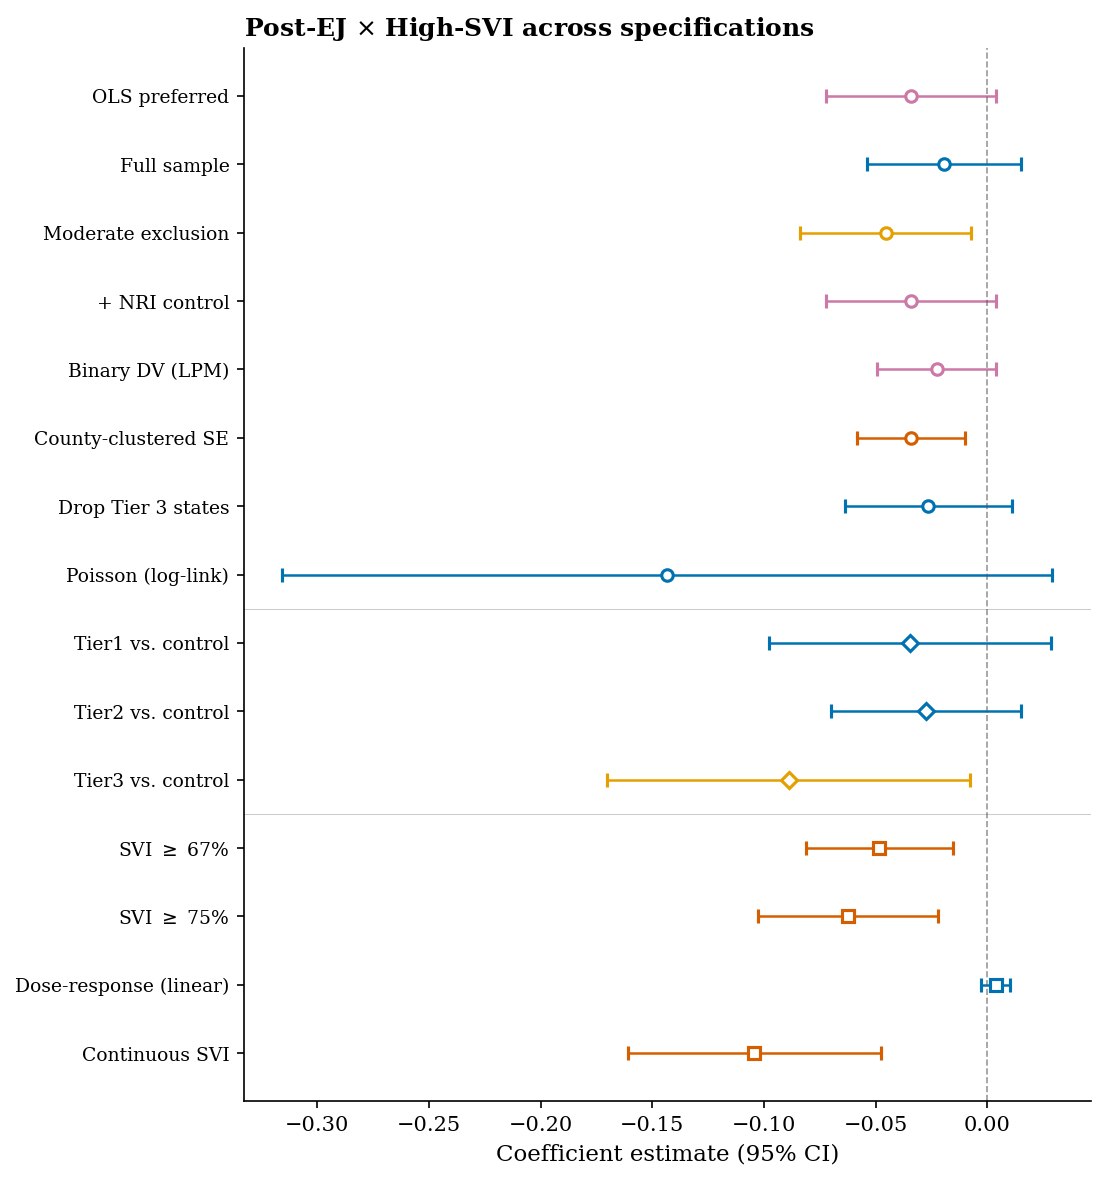

In [26]:
# Figure 2-3 (preliminary version; superseded by revised forest plot below)

# compute specs needed from committee extensions
did['svi_c'] = did['svi22'] - did['svi22'].mean()
did['post_svic'] = did['post'] * did['svi_c']
rc = ols(did, 'ndecl', ['post', 'svi_c', 'post_svic'], ctrls=CTR)

t3_fips = ej.loc[ej['Treatment_Code'] == 3, 'State_FIPS'].tolist()
r_no_t3 = ols(did[~did['stfips'].isin(t3_fips)], 'ndecl', xm, ctrls=CTR)

specs = []
def _a(label, res, var='post_hsvi', group='Main'):
    r = res.get(var) if res else None
    if r: specs.append({'spec':label,'b':r['b'],'lo':r['lo'],'hi':r['hi'],'p':r['p'],'group':group})

_a('OLS preferred', r2, group='Main')
_a('Full sample', r1, group='Main')
_a('Moderate exclusion', r3, group='Main')
_a('+ NRI control', r4, group='Main')
_a('Binary DV (LPM)', r5, group='Main')
_a('County-clustered SE', r6, group='Main')
_a('Drop Tier 3 states', r_no_t3, group='Main')
if r7: _a('Poisson (log-link)', r7, group='Main')
for tl,m in tmods.items(): _a(f'{tl} vs. control', m, group='Tier')
for cut in [.67,.75]:
    tmp=did.copy(); tmp['hh']=(tmp['svi22']>=cut).astype(int); tmp['phh']=tmp['post']*tmp['hh']
    _a(f'SVI $\geq$ {cut:.0%}', ols(tmp,'ndecl',['post','hh','phh'],ctrls=CTR), 'phh', group='Threshold')
_a('Dose-response (linear)', rd1, 'dose_hsvi', group='Threshold')
_a('Continuous SVI', rc, 'post_svic', group='Threshold')

sdf = pd.DataFrame(specs)
n = len(sdf)

fig, ax = plt.subplots(figsize=(7.5, n*0.48+0.8))

grp_markers = {'Main':'o', 'Tier':'D', 'Threshold':'s'}
for i, (_, row) in enumerate(sdf.iterrows()):
    yi = n-1-i
    c = CB_RED if row['p']<.01 else CB_ORANGE if row['p']<.05 else CB_PURPLE if row['p']<.1 else CB_BLUE
    mk = grp_markers.get(row['group'],'o')
    ax.errorbar(row['b'], yi, xerr=[[row['b']-row['lo']],[row['hi']-row['b']]],
                fmt=mk, color=c, capsize=3.5, ms=5.5, lw=1.2,
                markerfacecolor='white', markeredgewidth=1.5, markeredgecolor=c)

groups_ordered = sdf['group'].values
for i in range(1, n):
    if groups_ordered[i] != groups_ordered[i-1]:
        ax.axhline(n-1-i+0.5, color='#cccccc', ls='-', lw=0.5)

ax.axvline(0, color='#555555', ls='--', lw=0.8, alpha=.6)
ax.set_yticks(range(n))
ax.set_yticklabels(sdf['spec'].values[::-1], fontsize=9)
ax.set_xlabel('Coefficient estimate (95% CI)')
ax.set_title('Post-EJ $\\times$ High-SVI across specifications', fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('Figure_2-3_preliminary.png', dpi=300); plt.savefig('Figure_2-3_preliminary.pdf')
plt.show()

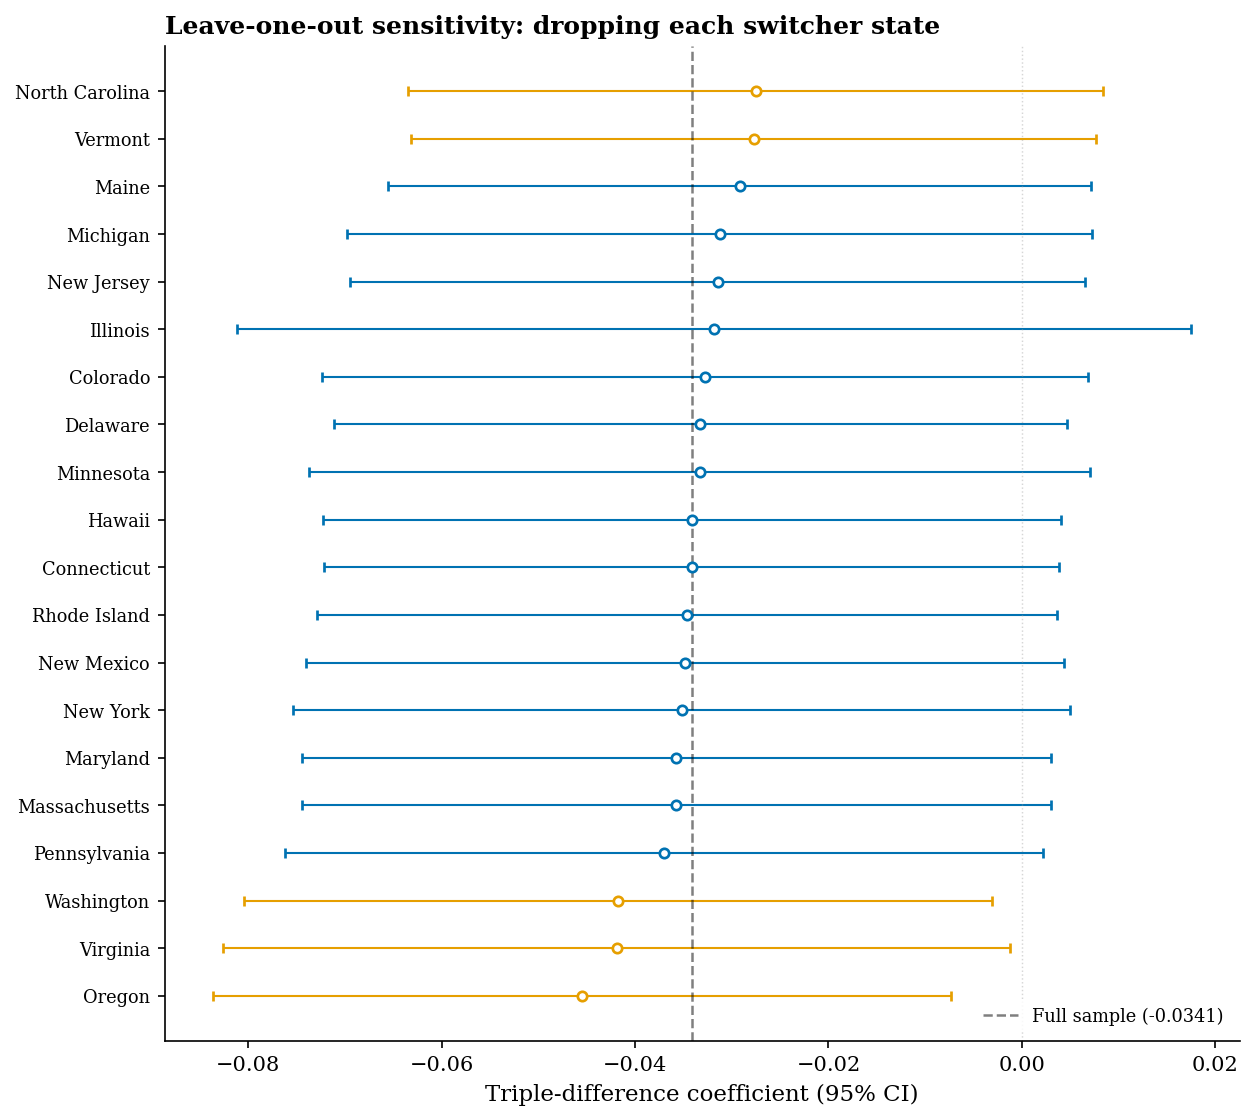

In [27]:
# Figure 2-S1: The Main Estimate Does Not Depend on Any One State

loo_s = loo.sort_values('b').reset_index(drop=True)
n = len(loo_s)

fig, ax = plt.subplots(figsize=(8.5, n*0.32+1.2))

for i, (_, row) in enumerate(loo_s.iterrows()):
    # color by how much it shifts the estimate
    shift = abs(row['b'] - main_b)
    if shift > 0.02:
        c = CB_RED
    elif shift > 0.005:
        c = CB_ORANGE
    else:
        c = CB_BLUE

    ax.errorbar(row['b'], i, xerr=1.96*row['se'],
                fmt='o', color=c, capsize=2.5, ms=4.5, lw=1.0,
                markerfacecolor='white', markeredgewidth=1.3, markeredgecolor=c)

ax.axvline(main_b, color=CB_BLACK, ls='--', lw=1.2, alpha=.5,
           label=f'Full sample ({main_b:.4f})')
ax.axvline(0, color='#999999', ls=':', lw=0.7, alpha=.4)

ax.set_yticks(range(n))
ax.set_yticklabels(loo_s['state'].values, fontsize=8.5)
ax.set_xlabel('Triple-difference coefficient (95% CI)')
ax.set_title('Leave-one-out sensitivity: dropping each switcher state',
             fontweight='bold', loc='left')
ax.legend(fontsize=8.5, loc='lower right', framealpha=.85, edgecolor='none')

plt.tight_layout()
plt.savefig('Figure_2-S1_Leave_One_Out.png', dpi=300); plt.savefig('Figure_2-S1_Leave_One_Out.pdf')
plt.show()

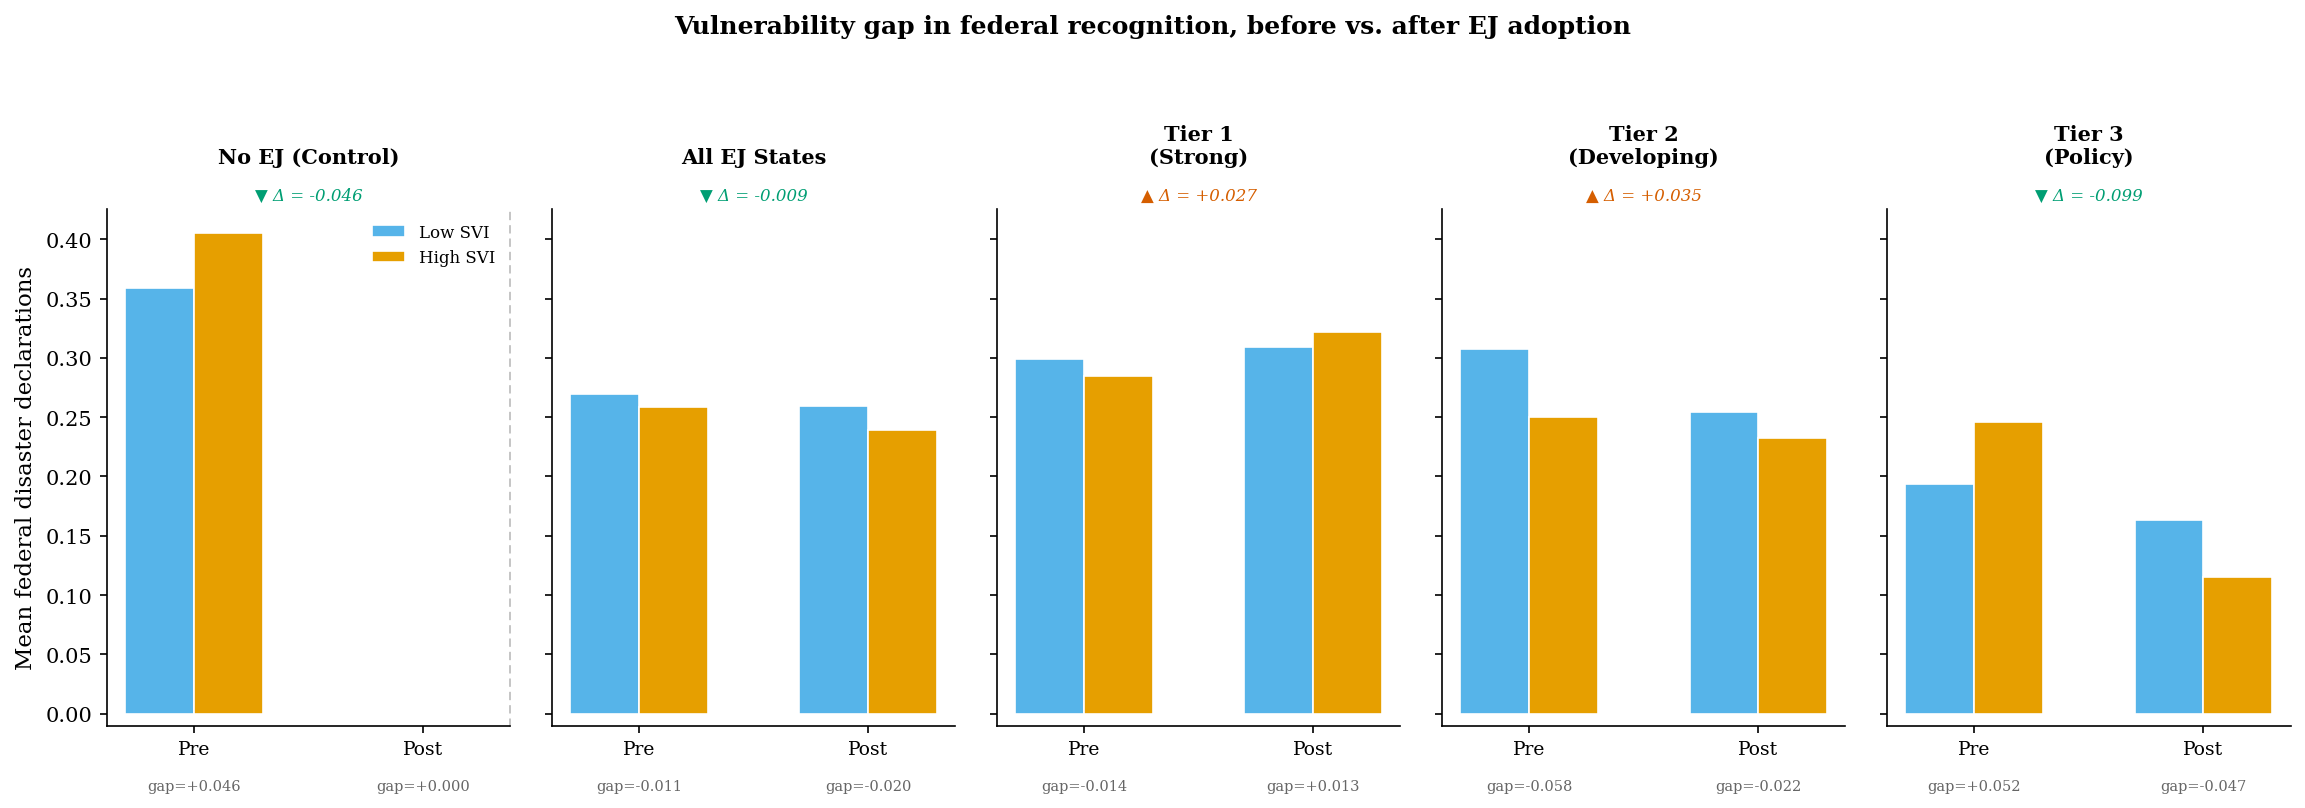

In [28]:
# Figure 2-5: Equity Effect (Post x EJ x High SVI) by Years Since Adoption

fig, axes = plt.subplots(1, 5, figsize=(15.5, 5), sharey=True)

panels = [('No EJ (Control)', did[did['is_nt']==1]),
          ('All EJ States',   did[did['anyej']==1]),
          ('Tier 1\n(Strong)',      did[did['t1']==1]),
          ('Tier 2\n(Developing)',  did[did['t2']==1]),
          ('Tier 3\n(Policy)',      did[did['t3']==1])]

lo_color = CB_SKYBLUE
hi_color = CB_ORANGE   # orange reads better than vermillion next to sky blue

for ax, (title, subset) in zip(axes, panels):
    if len(subset)==0: continue
    means = subset.groupby(['post','hsvi'])['ndecl'].mean()

    lo_pre  = means.get((0,0), 0)
    lo_post = means.get((1,0), 0)
    hi_pre  = means.get((0,1), 0)
    hi_post = means.get((1,1), 0)

    w = 0.30
    ax.bar([0-w/2, 1-w/2], [lo_pre, lo_post], w,
           label='Low SVI', color=lo_color, edgecolor='white', linewidth=0.8)
    ax.bar([0+w/2, 1+w/2], [hi_pre, hi_post], w,
           label='High SVI', color=hi_color, edgecolor='white', linewidth=0.8)

    gap_pre = hi_pre - lo_pre
    gap_post = hi_post - lo_post
    change = gap_post - gap_pre

    # gap labels tucked under the x-axis labels
    ax.text(0, -0.055, f'gap={gap_pre:+.3f}',
            ha='center', va='top', fontsize=7, color='#666666')
    ax.text(1, -0.055, f'gap={gap_post:+.3f}',
            ha='center', va='top', fontsize=7, color='#666666')

    # delta gap ABOVE the suptitle area - use fig coordinates via annotate
    chg_color = CB_GREEN if change < -0.005 else CB_RED if change > 0.005 else '#666666'
    chg_sym = '▼' if change < -0.005 else '▲' if change > 0.005 else '–'
    ax.text(0.5, 1.01, f'{chg_sym} Δ = {change:+.3f}',
            ha='center', va='bottom', fontsize=8, color=chg_color,
            transform=ax.transAxes, fontstyle='italic')

    ax.set_title(title, fontweight='bold', fontsize=10, pad=22)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre', 'Post'], fontsize=9)
    ax.set_ylim(-0.01, None)

    # light separator between No EJ and EJ panels
    if title == 'No EJ (Control)':
        ax.spines['right'].set_visible(True)
        ax.spines['right'].set_linestyle((0, (4, 4)))
        ax.spines['right'].set_color('#bbbbbb')

axes[0].set_ylabel('Mean federal disaster declarations')
axes[0].legend(fontsize=8, loc='upper right', framealpha=.85, edgecolor='none')

fig.suptitle('Vulnerability gap in federal recognition, before vs. after EJ adoption',
             fontweight='bold', fontsize=12, y=1.08)
plt.tight_layout(w_pad=1.5)
plt.subplots_adjust(top=0.82)
plt.savefig('Figure_2-5_Equity_Effect_by_Years.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_2-5_Equity_Effect_by_Years.pdf', bbox_inches='tight')
plt.show()

##Extensions

In [29]:
# Baseline balance: EJ vs non-EJ states (pre-treatment characteristics)

print("BASELINE BALANCE TABLE\n")
print("Pre-treatment means (pre-EJ adoption period only)\n")

# for switchers: use only pre-treatment years; for never-treated: use all years
pre_sw = did[(did['is_sw']==1) & (did['post']==0)]
pre_nt = did[did['is_nt']==1]

def _bal(d):
    return {
        'Declarations': d['ndecl'].mean(),
        'SVI': d['svi22'].mean(),
        '% High SVI': d['hsvi'].mean()*100,
        '% Rural': d['rural'].mean()*100 if d['rural'].notna().any() else np.nan,
        'Pop (median)': d.groupby('FIPS')['pop22'].first().median(),
        'NRI risk pc': d['nri_pc'].mean(),
        'Counties': d['FIPS'].nunique(),
    }

bal_sw = _bal(pre_sw)
bal_nt = _bal(pre_nt)

print(f"{'':30s} {'Switchers':>12s} {'Never-treated':>14s} {'Difference':>12s}")
for k in bal_sw:
    diff = bal_sw[k] - bal_nt[k] if not np.isnan(bal_sw[k]) else np.nan
    print(f"{k:30s} {bal_sw[k]:12.3f} {bal_nt[k]:14.3f} {diff:12.3f}")

# formal balance test for key variables
print("\nBalance tests (t-test of pre-treatment means):")
from scipy.stats import ttest_ind
for var, label in [('ndecl','Declarations'), ('svi22','SVI'), ('rural','Rural'),
                    ('nri_pc','NRI risk per capita')]:
    s = pre_sw.groupby('FIPS')[var].mean().dropna()
    n = pre_nt.groupby('FIPS')[var].mean().dropna()
    if len(s) > 0 and len(n) > 0:
        t, p = ttest_ind(s, n, equal_var=False)
        sig = '***' if p < .01 else '**' if p < .05 else '*' if p < .1 else ''
        print(f"  {label:25s}: t={t:.2f}, p={p:.4f}{sig}")

print("\nNote: Differences in baseline characteristics motivate state + year FE")
print("and suggest caution in interpreting raw EJ vs non-EJ comparisons.")
print(f"EJ states avg {bal_sw['Declarations']:.3f} declarations vs {bal_nt['Declarations']:.3f} for controls")
print(f"  ({(bal_sw['Declarations']/bal_nt['Declarations']-1)*100:+.1f}% difference)")

BASELINE BALANCE TABLE

Pre-treatment means (pre-EJ adoption period only)

                                  Switchers  Never-treated   Difference
Declarations                          0.265          0.384       -0.119
SVI                                   0.450          0.521       -0.070
% High SVI                           40.890         53.741      -12.850
% Rural                              54.280         66.051      -11.771
Pop (median)                      42362.000      21003.500    21358.500
NRI risk pc                           0.000          0.000       -0.000
Counties                            916.000       2112.000    -1196.000

Balance tests (t-test of pre-treatment means):
  Declarations             : t=-19.67, p=0.0000***
  SVI                      : t=-6.33, p=0.0000***
  Rural                    : t=-5.98, p=0.0000***
  NRI risk per capita      : t=-5.23, p=0.0000***

Note: Differences in baseline characteristics motivate state + year FE
and suggest caution in inter

In [30]:
# Continuous SVI

print("CONTINUOUS SVI SPECIFICATION\n")

# center SVI for interpretability
did['svi_c'] = did['svi22'] - did['svi22'].mean()
did['post_svic'] = did['post'] * did['svi_c']

rc = ols(did, 'ndecl', ['post', 'svi_c', 'post_svic'], ctrls=CTR)
pcoef(rc, 'post_svic', 'Post x SVI (continuous, centered)')
print(f"  Interpretation: effect of 1-SD increase in SVI on post-EJ declaration change")
print(f"  SVI SD = {did['svi22'].std():.3f}")

# also quadratic to test nonlinearity
did['svi_c2'] = did['svi_c']**2
did['post_svic2'] = did['post'] * did['svi_c2']
rq = ols(did, 'ndecl', ['post', 'svi_c', 'svi_c2', 'post_svic', 'post_svic2'], ctrls=CTR)
pcoef(rq, 'post_svic', '  Linear term')
pcoef(rq, 'post_svic2', '  Quadratic term')
p_quad = rq.get('post_svic2', {}).get('p', 1)
print(f"  Nonlinearity {'detected' if p_quad < .1 else 'not detected'} (p={p_quad:.3f})")

# compare thresholds side by side
print("\nThreshold comparison:")
for cut in [0.25, 0.50, 0.67, 0.75]:
    tmp = did.copy()
    tmp['hh'] = (tmp['svi22'] >= cut).astype(int)
    tmp['phh'] = tmp['post'] * tmp['hh']
    rr = ols(tmp, 'ndecl', ['post', 'hh', 'phh'], ctrls=CTR)
    r = rr.get('phh', {})
    n_hi = tmp['hh'].sum()
    pct = tmp['hh'].mean()*100
    if r:
        print(f"  SVI >= {cut:.0%} ({pct:.0f}% of obs): {r['b']:.4f}{r['sig']}  SE={r['se']:.4f}  p={r['p']:.3f}")

CONTINUOUS SVI SPECIFICATION

  Post x SVI (continuous, centered): -0.1043***  SE=0.0289  p=0.0003  [-0.1609,-0.0477]
  Interpretation: effect of 1-SD increase in SVI on post-EJ declaration change
  SVI SD = 0.288
    Linear term: -0.1054***  SE=0.0300  p=0.0004  [-0.1641,-0.0467]
    Quadratic term: -0.0007  SE=0.1271  p=0.9959  [-0.2498,0.2485]
  Nonlinearity not detected (p=0.996)

Threshold comparison:
  SVI >= 25% (75% of obs): -0.0487***  SE=0.0147  p=0.001
  SVI >= 50% (50% of obs): -0.0341*  SE=0.0194  p=0.078
  SVI >= 67% (33% of obs): -0.0482***  SE=0.0169  p=0.004
  SVI >= 75% (25% of obs): -0.0623***  SE=0.0205  p=0.002


In [31]:
# Parallel trends

print("PARALLEL TRENDS DIAGNOSTICS\n")

# joint F-test of all pre-period equity coefficients
pre_coefs = []
pre_vars = []
for t in [t for t in etlist if t < -1]:
    r = res_es.get(f'd{t}_h')
    if r:
        pre_coefs.append(r['b'])
        pre_vars.append(r['se']**2)

if pre_coefs:
    # joint test: are pre-period equity coefficients jointly zero?
    chi2_stat = sum(b**2/v for b, v in zip(pre_coefs, pre_vars))
    from scipy.stats import chi2
    joint_p = 1 - chi2.cdf(chi2_stat, df=len(pre_coefs))
    print(f"Joint test of pre-period equity coefficients = 0:")
    print(f"  chi2({len(pre_coefs)}) = {chi2_stat:.3f}, p = {joint_p:.4f}")
    print(f"  {'CONCERN: rejects joint null' if joint_p < .1 else 'Passes: cannot reject joint null'}\n")

# restricted event window [-4, +4] dropping binned endpoints
print("Restricted event window [-4, +4] (drops binned endpoints):\n")
esamp2 = esamp[(esamp['evt'] >= -4) & (esamp['evt'] <= 4)].copy()
etlist2 = sorted(set(int(t) for t in esamp2['evt'].dropna().unique() if int(t) != -1))
for t in etlist2:
    esamp2[f'r{t}'] = (esamp2['evt'] == t).astype(int)
    esamp2[f'r{t}_h'] = esamp2[f'r{t}'] * esamp2['hsvi']
rvars2 = [f'r{t}' for t in etlist2] + ['hsvi'] + [f'r{t}_h' for t in etlist2]
res_r = ols(esamp2, 'ndecl', rvars2, ctrls=CTR)

print("Pre-period (restricted):")
for t in [t for t in etlist2 if t < -1]:
    r = res_r.get(f'r{t}_h')
    if r: print(f"  t={t:+d}: {r['b']:.4f}{r['sig']}  p={r['p']:.4f}")

pre2 = [res_r.get(f'r{t}_h') for t in etlist2 if t < -1 and res_r.get(f'r{t}_h')]
if pre2:
    chi2_r = sum(r['b']**2/r['se']**2 for r in pre2)
    jp2 = 1 - chi2.cdf(chi2_r, df=len(pre2))
    print(f"\n  Joint test (restricted): chi2({len(pre2)}) = {chi2_r:.3f}, p = {jp2:.4f}")

print("\nPost-period (restricted):")
for t in [t for t in etlist2 if t > 0]:
    r = res_r.get(f'r{t}_h')
    if r: print(f"  t=+{t}: {r['b']:.4f}{r['sig']}  p={r['p']:.4f}")

# Rambachan-Roth style: what if pre-trends continued linearly?
print("\nPre-trend slope test:")
pre_ts = [(t, res_es.get(f'd{t}_h',{}).get('b',0)) for t in sorted(etlist) if t < -1]
if len(pre_ts) >= 2:
    from scipy.stats import linregress
    xs = [p[0] for p in pre_ts]
    ys = [p[1] for p in pre_ts]
    slope, intercept, r_val, p_val, se = linregress(xs, ys)
    print(f"  Linear trend in pre-period equity coefs: slope={slope:.4f}, p={p_val:.4f}")
    print(f"  {'Pre-trend detected - interpret post-period with caution' if p_val < .1 else 'No linear pre-trend detected'}")

PARALLEL TRENDS DIAGNOSTICS

Joint test of pre-period equity coefficients = 0:
  chi2(5) = 5.273, p = 0.3835
  Passes: cannot reject joint null

Restricted event window [-4, +4] (drops binned endpoints):

Pre-period (restricted):
  t=-4: 0.0394  p=0.5784
  t=-3: 0.0278  p=0.7293
  t=-2: 0.1156*  p=0.0686

  Joint test (restricted): chi2(3) = 3.746, p = 0.2903

Post-period (restricted):
  t=+1: -0.0677  p=0.1875
  t=+2: -0.0380  p=0.6482
  t=+3: 0.0727  p=0.2544
  t=+4: 0.0088  p=0.8579

Pre-trend slope test:
  Linear trend in pre-period equity coefs: slope=0.0097, p=0.4990
  No linear pre-trend detected


In [32]:
# Political controls

print("POLITICAL CONTROLS\n")

# governor party by state-year (simplified: use presidential vote as proxy)
# construct swing state indicator from close presidential margins

# approach: interact with presidential administration
did['trump_era'] = did['year'].between(2017, 2020).astype(int)
did['biden_era'] = (did['year'] >= 2021).astype(int)
did['post_trump'] = did['post'] * did['trump_era']
did['post_biden'] = did['post'] * did['biden_era']
did['post_trump_h'] = did['post_trump'] * did['hsvi']
did['post_biden_h'] = did['post_biden'] * did['hsvi']

rp1 = ols(did, 'ndecl', ['post', 'hsvi', 'post_hsvi',
                           'trump_era', 'biden_era',
                           'post_trump', 'post_biden',
                           'post_trump_h', 'post_biden_h'], ctrls=CTR)
print("Administration-specific equity effects:")
pcoef(rp1, 'post_hsvi', '  Base EJ equity effect')
pcoef(rp1, 'post_trump_h', '  Additional under Trump')
pcoef(rp1, 'post_biden_h', '  Additional under Biden')

# region interactions (South vs non-South)
did['south'] = did['stfips'].isin([1,5,12,13,21,22,28,37,40,45,47,48,51,54]).astype(int)
did['post_south'] = did['post'] * did['south']
did['post_south_h'] = did['post_south'] * did['hsvi']

rp2 = ols(did, 'ndecl', ['post', 'hsvi', 'post_hsvi', 'south',
                           'post_south', 'post_south_h'], ctrls=CTR)
print("\nRegional heterogeneity (South vs non-South):")
pcoef(rp2, 'post_hsvi', '  Non-South EJ equity effect')
pcoef(rp2, 'post_south_h', '  Additional effect in South')

# election year indicator
did['elec_yr'] = did['year'].isin([2000,2004,2008,2012,2016,2020,2024]).astype(int)
did['post_elec'] = did['post'] * did['elec_yr']
did['post_elec_h'] = did['post_elec'] * did['hsvi']

rp3 = ols(did, 'ndecl', ['post', 'hsvi', 'post_hsvi', 'elec_yr',
                           'post_elec', 'post_elec_h'], ctrls=CTR)
print("\nElection year effect:")
pcoef(rp3, 'post_hsvi', '  Non-election year equity')
pcoef(rp3, 'post_elec_h', '  Additional in election years')
print("  (Reeves 2011; Gasper & Reeves 2011 find electoral targeting of declarations)")

POLITICAL CONTROLS

Administration-specific equity effects:
    Base EJ equity effect: -0.0787***  SE=0.0127  p=0.0000  [-0.1035,-0.0539]
    Additional under Trump: 0.0901*  SE=0.0495  p=0.0685  [-0.0068,0.1871]
    Additional under Biden: 0.0451*  SE=0.0231  p=0.0509  [-0.0002,0.0904]

Regional heterogeneity (South vs non-South):
    Non-South EJ equity effect: -0.0319  SE=0.0200  p=0.1099  [-0.0711,0.0072]
    Additional effect in South: -0.0059  SE=0.0360  p=0.8700  [-0.0764,0.0646]

Election year effect:
    Non-election year equity: -0.0471***  SE=0.0159  p=0.0031  [-0.0782,-0.0159]
    Additional in election years: 0.0444  SE=0.0411  p=0.2794  [-0.0361,0.1250]
  (Reeves 2011; Gasper & Reeves 2011 find electoral targeting of declarations)


In [33]:
# Tier 3 robustness + mapping tool diagnostics

print("TIER 3 SENSITIVITY\n")

# main result excluding Tier 3 states entirely
t3_fips = ej.loc[ej['Treatment_Code'] == 3, 'State_FIPS'].tolist()
did_no_t3 = did[~did['stfips'].isin(t3_fips)]
r_no_t3 = ols(did_no_t3, 'ndecl', xm, ctrls=CTR)
nsw_no_t3 = did_no_t3.loc[did_no_t3['is_sw']==1, 'stfips'].nunique()
print(f"Dropping all Tier 3 states ({len(t3_fips)} states, {nsw_no_t3} switchers remain):")
pcoef(r_no_t3, 'post_hsvi', '  Triple-diff')

# Tier 3 with only pre-COVID adopters
t3_pre_covid = ej.loc[(ej['Treatment_Code']==3) & (ej['Treatment_Year'] < 2020) & (~ej['State_FIPS'].isin(at_fips)), 'State_FIPS'].tolist()
t3_names = [ej.loc[ej['State_FIPS']==f, 'State'].iloc[0] for f in t3_pre_covid]
print(f"\nTier 3 pre-COVID adopters only: {t3_names}")
if t3_pre_covid:
    nt_fips = did.loc[did['is_nt']==1, 'stfips'].unique().tolist()
    ss = did[did['stfips'].isin(t3_pre_covid + nt_fips)]
    pcoef(ols(ss, 'ndecl', xm, ctrls=CTR), 'post_hsvi', '  Triple-diff')
else:
    print("  No Tier 3 states adopted before 2020")

# Tier 3 post-period length check
print("\nTier 3 state post-treatment windows:")
for _, r in ej[(ej['Treatment_Code']==3) & (~ej['State_FIPS'].isin(at_fips))].sort_values('Treatment_Year').iterrows():
    yrs_post = YR1 - int(r['Treatment_Year']) + 1
    print(f"  {r['State']:20s} adopted {int(r['Treatment_Year'])}  → {yrs_post} post-years")

# COVID declaration surge test
print("\nCOVID declaration surge check:")
for period, mask in [('2017-2019', did['year'].between(2017,2019)),
                     ('2020-2021', did['year'].between(2020,2021)),
                     ('2022-2025', did['year'].between(2022,2025))]:
    sub = did[mask]
    m_nt = sub.loc[sub['is_nt']==1, 'ndecl'].mean()
    m_ej = sub.loc[sub['anyej']==1, 'ndecl'].mean()
    print(f"  {period}: never-treated={m_nt:.3f}, EJ states={m_ej:.3f}, ratio={m_ej/m_nt:.3f}")

print("\n" + "="*60)
print("MAPPING TOOL DIAGNOSTICS\n")

if 'has_map' in did.columns:
    map_states = ej.loc[(ej['EJ_Mapping_Tool']==1) & (~ej['State_FIPS'].isin(at_fips)), 'State'].tolist()
    map_fips = ej.loc[(ej['EJ_Mapping_Tool']==1) & (~ej['State_FIPS'].isin(at_fips)), 'State_FIPS'].tolist()
    print(f"States with mapping tools in DiD sample ({len(map_states)}):")
    for s in map_states: print(f"  {s}")

    print(f"\nN states driving mapping tool result: {len(map_states)}")
    if len(map_states) <= 6:
        print("  WARNING: small number of states - treat as suggestive, not confirmatory")

    # leave-one-out for mapping tool result
    print("\nMapping tool leave-one-out:")
    for sf in map_fips:
        sname = ej.loc[ej['State_FIPS']==sf, 'State'].iloc[0]
        ss = did[did['stfips'] != sf]
        ss_map = ss.copy()
        ss_map['has_map'] = ss_map['EJ_Mapping_Tool'].fillna(0).astype(int)
        ss_map['post_map'] = ss_map['post'] * ss_map['has_map']
        ss_map['post_map_h'] = ss_map['post_map'] * ss_map['hsvi']
        ss_map['nomap'] = ((ss_map['anyej']==1) & (ss_map['has_map']==0)).astype(int)
        ss_map['post_nomap'] = ss_map['post'] * ss_map['nomap']
        ss_map['post_nomap_h'] = ss_map['post_nomap'] * ss_map['hsvi']
        rm = ols(ss_map, 'ndecl', ['post_map','post_nomap','hsvi','post_map_h','post_nomap_h'], ctrls=CTR)
        r = rm.get('post_map_h', {})
        if r:
            print(f"  Drop {sname:18s}: {r['b']:.4f}{r['sig']}  SE={r['se']:.4f}  p={r['p']:.3f}")

TIER 3 SENSITIVITY

Dropping all Tier 3 states (7 states, 14 switchers remain):
    Triple-diff: -0.0263  SE=0.0191  p=0.1691  [-0.0638,0.0112]

Tier 3 pre-COVID adopters only: []
  No Tier 3 states adopted before 2020

Tier 3 state post-treatment windows:
  Delaware             adopted 2022  → 4 post-years
  Hawaii               adopted 2022  → 4 post-years
  North Carolina       adopted 2023  → 3 post-years
  Pennsylvania         adopted 2023  → 3 post-years
  Rhode Island         adopted 2023  → 3 post-years
  Michigan             adopted 2024  → 2 post-years

COVID declaration surge check:
  2017-2019: never-treated=0.329, EJ states=0.171, ratio=0.521
  2020-2021: never-treated=0.832, EJ states=0.660, ratio=0.794
  2022-2025: never-treated=0.315, EJ states=0.160, ratio=0.509

MAPPING TOOL DIAGNOSTICS

States with mapping tools in DiD sample (16):
  Colorado
  Connecticut
  Delaware
  Hawaii
  Illinois
  Maryland
  Massachusetts
  Michigan
  Minnesota
  New Jersey
  New York
  North

In [34]:
# Dump all coefficients from the full-window event study
print("Full-window equity interaction coefficients:")
for t in sorted([t for t in etlist if t < -1]):
    r = res_es.get(f'd{t}_h')
    if r:
        sig = '***' if r['p']<.01 else '**' if r['p']<.05 else '*' if r['p']<.10 else ''
        print(f"  t = {t:+d}: β = {r['b']:+.4f}{sig}  p = {r['p']:.4f}")

Full-window equity interaction coefficients:
  t = -6: β = -0.0287**  p = 0.0487
  t = -5: β = +0.0215  p = 0.7737
  t = -4: β = -0.0621  p = 0.3128
  t = -3: β = +0.0172  p = 0.7421
  t = -2: β = +0.0219  p = 0.6741


## Robustness Checks

In [35]:
# Placebo + SVI thresholds

print("PLACEBO\n")
plac=did.copy(); plac['fakeyr']=plac['Treatment_Year']-3
plac['pfake']=np.where(plac['fakeyr'].notna()&(plac['year']>=plac['fakeyr']),1,0)
plac=plac[plac['Treatment_Year'].isna()|(plac['year']<plac['Treatment_Year'])]
plac['fakeh']=plac['pfake']*plac['hsvi']
rp=ols(plac,'ndecl',['pfake','hsvi','fakeh'],ctrls=CTR)
pcoef(rp,'fakeh','Fake x HighSVI')
pp=rp.get('fakeh',{}).get('p',1)
print(f"  {'CONCERN' if pp<.1 else 'passes'} (p={pp:.3f})")

print("\n\nSVI THRESHOLDS\n")
for cut in [.50,.67,.75]:
    tmp=did.copy(); tmp['hh']=(tmp['svi22']>=cut).astype(int); tmp['phh']=tmp['post']*tmp['hh']
    rr=ols(tmp,'ndecl',['post','hh','phh'],ctrls=CTR)
    r=rr.get('phh',{})
    if r: print(f"  >= {cut:.0%}: {r['b']:.4f}{r['sig']}  SE={r['se']:.4f}")

PLACEBO

  Fake x HighSVI: 0.0205  SE=0.0239  p=0.3929  [-0.0265,0.0674]
  passes (p=0.393)


SVI THRESHOLDS

  >= 50%: -0.0341*  SE=0.0194
  >= 67%: -0.0482***  SE=0.0169
  >= 75%: -0.0623***  SE=0.0205


In [36]:
# Vintage-matched SVI

print("VINTAGE-MATCHED SVI ROBUSTNESS\n")

if 'sv_RPL_THEMES' not in did.columns:
    print("  sv_RPL_THEMES not in did \u2014 check Cell 4 svitv merge")
else:
    dvt = did.copy()
    # Drop county-years missing time-varying SVI (e.g., before SVI 2000 coverage)
    dvt = dvt.dropna(subset=['sv_RPL_THEMES']).copy()

    # Year-specific median \u2192 binary flag
    dvt['hsvi_vt'] = (
        dvt.groupby('year')['sv_RPL_THEMES']
           .transform(lambda s: (s >= s.median()).astype(int))
    )
    dvt['post_hsvi_vt'] = dvt['post'] * dvt['hsvi_vt']

    # Year-by-year share flagged HighSVI (sanity)
    print(f"  Sample after vintage SVI merge: {len(dvt):,} county-years "
          f"(static-SVI sample: {len(did):,})")
    print("  HighSVI vintage \u2014 share of counties flagged by year (selected):")
    _yr_share = dvt.groupby('year')['hsvi_vt'].mean()
    for _yr in [2000, 2005, 2010, 2015, 2020, 2025]:
        if _yr in _yr_share.index:
            print(f"    {_yr} (SVI {_vintage(_yr)}): {_yr_share[_yr]:.3f}")

    # Static\u2014vintage agreement: how often does the binary flag flip across
    # specifications? Useful for committee questions.
    _agree = (dvt['hsvi'] == dvt['hsvi_vt']).mean()
    print(f"  Agreement rate, static svi22 flag vs vintage flag: {_agree:.3f}")

    # Preferred OLS spec with vintage-matched HighSVI
    rv = ols(dvt, 'ndecl', ['post','hsvi_vt','post_hsvi_vt'], ctrls=CTR)
    bv  = rv['post_hsvi_vt']['b']
    sv  = rv['post_hsvi_vt']['se']
    pv  = rv['post_hsvi_vt']['p']
    sig_v = '***' if pv<.01 else '**' if pv<.05 else '*' if pv<.1 else ''
    print(f"\n  Preferred spec, vintage-matched HighSVI:")
    print(f"    post_hsvi_vt: \u03b2 = {bv:+.4f}{sig_v}  SE = {sv:.4f}  p = {pv:.4f}")

    # Comparison to static SVI 2022 (Cell 8 r2)
    bs = r2['post_hsvi']['b']; ss = r2['post_hsvi']['se']; ps = r2['post_hsvi']['p']
    sig_s = '***' if ps<.01 else '**' if ps<.05 else '*' if ps<.1 else ''
    print(f"\n  Comparison \u2014 static SVI 2022 (Cell 8 r2):")
    print(f"    post_hsvi:    \u03b2 = {bs:+.4f}{sig_s}  SE = {ss:.4f}  p = {ps:.4f}")
    print(f"\n  Difference in point estimate: {bv - bs:+.4f}")


VINTAGE-MATCHED SVI ROBUSTNESS

  Sample after vintage SVI merge: 78,621 county-years (static-SVI sample: 78,728)
  HighSVI vintage — share of counties flagged by year (selected):
    2000 (SVI 2000): 0.500
    2005 (SVI 2010): 0.500
    2010 (SVI 2010): 0.500
    2015 (SVI 2016): 0.500
    2020 (SVI 2020): 0.500
    2025 (SVI 2022): 0.500
  Agreement rate, static svi22 flag vs vintage flag: 0.905

  Preferred spec, vintage-matched HighSVI:
    post_hsvi_vt: β = -0.0278  SE = 0.0196  p = 0.1567

  Comparison — static SVI 2022 (Cell 8 r2):
    post_hsvi:    β = -0.0341*  SE = 0.0194  p = 0.0785

  Difference in point estimate: +0.0063


In [37]:
# SHELDUS robustness

if has_sheldus:
    print(f"SHELDUS (2000-{SH_END})\n")
    dsh=did[did['year']<=SH_END].copy()
    print(f"Restricted: {len(dsh):,} obs\n")
    s1=ols(dsh,'ndecl',xm,ctrls=CTR+['lnsh_dmg']); print("S1 +damage:"); pcoef(s1,'post_hsvi')
    s2=ols(dsh,'ndecl',xm,ctrls=CTR+['lnsh_cas']); print("S2 +casualties:"); pcoef(s2,'post_hsvi')
    dsh['decl_per_evt']=dsh['ndecl']/(dsh['sh_nevents']+1)
    s3=ols(dsh,'decl_per_evt',xm,ctrls=CTR); print("S3 decl/event:"); pcoef(s3,'post_hsvi')
    s4=ols(dsh,'ndecl',xm,ctrls=CTR); print(f"S4 window:"); pcoef(s4,'post_hsvi')
    print(f"\nTier-specific:")
    for tc,tl in [(1,'T1'),(2,'T2'),(3,'T3')]:
        ss=dsh[(dsh[f't{tc}']==1)|(dsh['is_nt']==1)]
        pcoef(ols(ss,'ndecl',xm,ctrls=CTR+['lnsh_dmg']),'post_hsvi',f'  {tl}')
    rtable([s1,s2,s3,s4],['Dmg','Cas','D/E','Win'],xm).to_csv('robust_sheldus.csv',index=False)
else:
    print("SHELDUS not loaded")

SHELDUS (2000-2024)

Restricted: 75,700 obs

S1 +damage:
  post_hsvi: -0.0374*  SE=0.0224  p=0.0953  [-0.0814,0.0065]
S2 +casualties:
  post_hsvi: -0.0417*  SE=0.0223  p=0.0617  [-0.0854,0.0020]
S3 decl/event:
  post_hsvi: -0.0205  SE=0.0154  p=0.1809  [-0.0506,0.0095]
S4 window:
  post_hsvi: -0.0397*  SE=0.0228  p=0.0819  [-0.0844,0.0050]

Tier-specific:
    T1: -0.0299  SE=0.0365  p=0.4137  [-0.1014,0.0417]
    T2: -0.0389  SE=0.0285  p=0.1723  [-0.0949,0.0170]
    T3: -0.0548*  SE=0.0319  p=0.0859  [-0.1173,0.0077]


In [38]:
# summary + download

rm = r2.get('post_hsvi',{})
print(f"""
{'='*60}
SUMMARY
{'='*60}

Declarations: {'+'.join(DTYPE)}, {YR0}-{YR1}
SHELDUS: through {SH_END if SH_END else 'N/A'}
Panel: {df['FIPS'].nunique()} counties, {len(df):,} obs
DiD: {len(did):,} obs, {nsw} switchers
Excluded: {at_names}
Tiers: {(ej['Treatment_Code']==1).sum()} T1 / {(ej['Treatment_Code']==2).sum()} T2 / {(ej['Treatment_Code']==3).sum()} T3

Main triple-diff: b={rm.get('b',0):.4f}{rm.get('sig','')}  SE={rm.get('se',0):.4f}  p={rm.get('p',0):.4f}
  [{rm.get('lo',0):.4f}, {rm.get('hi',0):.4f}]
  {rm.get('b',0)/r2['ymean']*100:.1f}% of dep var mean
""")
for tl,m in tmods.items():
    r=m.get('post_hsvi',{})
    print(f"  {tl:8s} b={r.get('b',0):.4f}{r.get('sig','')}")

for fn in ['table1.csv','table2.csv','table3.csv','robust_sheldus.csv',
           'fig1_eventstudy.png','fig1_eventstudy.pdf',
           'fig2_trends.png','fig2_trends.pdf',
           'fig3_forest.png','fig3_forest.pdf',
           'fig4_leaveoneout.png','fig4_leaveoneout.pdf',
           'fig5_gaps.png','fig5_gaps.pdf']:
    if 'google.colab' in sys.modules:
        from google.colab import files
        files.download(fn)
    else:
        download(fn)


SUMMARY

Declarations: DR, 2000-2025
SHELDUS: through 2024
Panel: 3142 counties, 81,692 obs
DiD: 78,728 obs, 20 switchers
Excluded: ['California', 'Montana']
Tiers: 7 T1 / 8 T2 / 7 T3

Main triple-diff: b=-0.0341*  SE=0.0194  p=0.0785
  [-0.0722, 0.0039]
  -9.8% of dep var mean

  Tier1    b=-0.0345
  Tier2    b=-0.0275
  Tier3    b=-0.0890**
File not found: table1.csv


File not found: fig1_eventstudy.png
File not found: fig1_eventstudy.pdf
File not found: fig2_trends.png
File not found: fig2_trends.pdf
File not found: fig3_forest.png
File not found: fig3_forest.pdf
File not found: fig4_leaveoneout.png
File not found: fig4_leaveoneout.pdf
File not found: fig5_gaps.png
File not found: fig5_gaps.pdf


In [39]:
# DR vs DR+EM + 2010 subsample + cohorts + admin

print("DR vs DR+EM\n")
_dall=pd.read_csv(data_dir / 'DisasterDeclarationsSummaries.csv',low_memory=False)
_dall['declarationDate']=pd.to_datetime(_dall['declarationDate'])
_dall['year']=_dall['declarationDate'].dt.year
_dall['FIPS']=_dall['fipsStateCode']*1000+_dall['fipsCountyCode']
_dall=_dall[(_dall['fipsCountyCode']>0)&(_dall['year']>=YR0)&(_dall['year']<=YR1)]
for dl,dfl in [('DR',['DR']),('DR+EM',['DR','EM'])]:
    dcy2=_dall[_dall['declarationType'].isin(dfl)].groupby(['FIPS','year']).agg(dalt=('disasterNumber','nunique')).reset_index()
    tmp=did[['FIPS','year','post','hsvi','post_hsvi','stfips','lnpop','rural','coastal']].copy()
    tmp=tmp.merge(dcy2,on=['FIPS','year'],how='left'); tmp['dalt']=tmp['dalt'].fillna(0)
    rr=ols(tmp,'dalt',['post','hsvi','post_hsvi'],ctrls=CTR)
    print(f"{dl}: mean={rr['ymean']:.4f}"); pcoef(rr,'post_hsvi','  Triple-diff'); print()

print("\n2010-2025 SUBSAMPLE\n")
d10=did[did['year']>=2010].copy()
xat=ej.loc[ej['Treatment_Year'].notna()&(ej['Treatment_Year']<2010)&(~ej['State_FIPS'].isin(at_fips)),'State_FIPS'].tolist()
d10=d10[~d10['stfips'].isin(xat)]
print(f"  Extra always-treated: {[ej.loc[ej['State_FIPS']==f,'State'].iloc[0] for f in xat]}")
pcoef(ols(d10,'ndecl',xm,ctrls=CTR),'post_hsvi','Triple-diff (2010-2025)')
if has_sheldus:
    pcoef(ols(d10[d10['year']<=SH_END],'ndecl',xm,ctrls=CTR+['lnsh_dmg']),'post_hsvi','  +SHELDUS ctrl')

print("\n\nCOHORTS\n")
dtmp=did.copy(); dtmp['coh']='never'
dtmp.loc[dtmp['Treatment_Year'].notna()&(dtmp['Treatment_Year']<2010),'coh']='pre2010'
dtmp.loc[(dtmp['Treatment_Year']>=2010)&(dtmp['Treatment_Year']<=2021),'coh']='mid'
dtmp.loc[dtmp['Treatment_Year']>=2022,'coh']='late'
for ch in ['pre2010','mid','late']:
    ss=dtmp[(dtmp['coh']==ch)|(dtmp['coh']=='never')]
    nc=ss.loc[ss['coh']==ch,'stfips'].nunique()
    if nc==0: continue
    sn=ej.loc[ej['State_FIPS'].isin(ss.loc[ss['coh']==ch,'stfips'].unique()),'State'].tolist()
    rr=ols(ss,'ndecl',xm,ctrls=CTR)
    print(f"{ch} ({nc}: {', '.join(sn[:3])}{'...' if len(sn)>3 else ''}):")
    pcoef(rr,'post_hsvi','  Triple-diff'); print()

print("ADMIN CONTROLS\n")
dtmp=did.copy(); adm=pd.get_dummies(dtmp['admin'],prefix='adm',drop_first=True)
for c in adm.columns: dtmp[c]=adm[c]
pcoef(ols(dtmp,'ndecl',xm+list(adm.columns),ctrls=CTR),'post_hsvi','Triple-diff (+admin)')

DR vs DR+EM

DR: mean=0.3466
    Triple-diff: -0.0341*  SE=0.0194  p=0.0785  [-0.0722,0.0039]

DR+EM: mean=0.5401
    Triple-diff: -0.0090  SE=0.0324  p=0.7822  [-0.0724,0.0545]


2010-2025 SUBSAMPLE

  Extra always-treated: ['Connecticut', 'Oregon']
  Triple-diff (2010-2025): -0.0417*  SE=0.0221  p=0.0586  [-0.0849,0.0015]
    +SHELDUS ctrl: -0.0432*  SE=0.0237  p=0.0684  [-0.0897,0.0033]


COHORTS

pre2010 (2: Connecticut, Oregon):
    Triple-diff: 0.0338***  SE=0.0122  p=0.0056  [0.0099,0.0577]

mid (10: Colorado, Illinois, Maine...):
    Triple-diff: -0.0286  SE=0.0186  p=0.1240  [-0.0650,0.0078]

late (8: Delaware, Hawaii, Michigan...):
    Triple-diff: -0.1143***  SE=0.0381  p=0.0027  [-0.1890,-0.0395]

ADMIN CONTROLS

  Triple-diff (+admin): -0.0341*  SE=0.0194  p=0.0785  [-0.0722,0.0039]


In [40]:
# Callaway-Sant'Anna cohort estimator

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("CALLAWAY-SANT'ANNA (each cohort vs never-treated only)\n")

nt_pool = did[did['g'] == 0].copy() if 'g' in did.columns else did[did['is_nt'] == 1].copy()

if 'g' not in did.columns:
    did['g'] = did['Treatment_Year'].fillna(0).astype(int)
    nt_pool = did[did['g'] == 0].copy()

cohort_years = sorted([yr for yr in did['g'].unique() if yr > 0])
cohort_results = {}

for cohort_yr in cohort_years:
    cohort = did[did['g'] == cohort_yr].copy()
    cohort_states = cohort['stfips'].unique()
    state_names = ej.loc[ej['State_FIPS'].isin(cohort_states), 'State'].tolist()

    sub = pd.concat([cohort, nt_pool], ignore_index=True)
    sub['post_cohort'] = (sub['year'] >= cohort_yr).astype(int)
    sub['treated']     = (sub['g'] == cohort_yr).astype(int)
    sub['did_cohort']  = sub['post_cohort'] * sub['treated'] * sub['hsvi']

    r = ols(sub, 'ndecl', ['post_cohort','treated','hsvi','did_cohort'], ctrls=CTR)
    b = r.get('did_cohort', {}).get('b', np.nan)
    se = r.get('did_cohort', {}).get('se', np.nan)
    p = r.get('did_cohort', {}).get('p', np.nan)
    cohort_results[cohort_yr] = {'b': b, 'se': se, 'p': p, 'n_states': len(cohort_states),
                                   'states': state_names}

    sig = '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    print(f"  {cohort_yr} (n={len(cohort_states)}): β = {b:+.4f}{sig}  p = {p:.4f}  "
          f"[{', '.join(state_names[:3])}{'...' if len(state_names)>3 else ''}]")

# variance-weighted aggregate; skip degenerate cohorts (no high-SVI counties)
SE_FLOOR = 1e-4
valid = {}
excluded_info = []
for yr, r in cohort_results.items():
    cohort_treated_hsvi = did[(did['g'] == yr) & (did['year'] >= yr)]['hsvi'].sum()
    if cohort_treated_hsvi == 0:
        excluded_info.append(
            f"{yr} ({', '.join(cohort_results[yr]['states'])}) "
            f"\u2014 no high-SVI counties in cohort (did_cohort identically 0)"
        )
        continue
    if np.isnan(r['b']) or np.isnan(r['se']) or r['se'] <= SE_FLOOR:
        excluded_info.append(
            f"{yr} ({', '.join(cohort_results[yr]['states'])}) "
            f"\u2014 NaN or se\u2264{SE_FLOOR}"
        )
        continue
    valid[yr] = r

if excluded_info:
    print("\nExcluded from variance-weighted aggregate (degenerate, matches Cell 35 pyfixest NaN):")
    for e in excluded_info: print(f"  {e}")
print(f"Aggregating over {len(valid)} non-singular cohorts: {sorted(valid.keys())}")
weights = np.array([1/r['se']**2 for r in valid.values()])
weights /= weights.sum()
coefs = np.array([r['b']  for r in valid.values()])
ses   = np.array([r['se'] for r in valid.values()])

agg_b  = np.sum(weights * coefs)
agg_se = np.sqrt(np.sum(weights**2 * ses**2))
agg_z  = agg_b / agg_se
agg_p  = 2 * (1 - stats.norm.cdf(abs(agg_z)))
agg_sig = '***' if agg_p<.01 else '**' if agg_p<.05 else '*' if agg_p<.1 else ''

print(f"\nCS aggregate: β = {agg_b:+.4f}{agg_sig}  SE = {agg_se:.4f}  p = {agg_p:.4f}")
print(f"  95% CI: [{agg_b - 1.96*agg_se:.4f}, {agg_b + 1.96*agg_se:.4f}]")
print(f"  TWFE preferred: β = {r2['post_hsvi']['b']:+.4f}  (diff = {agg_b - r2['post_hsvi']['b']:+.4f})")

CALLAWAY-SANT'ANNA (each cohort vs never-treated only)

  2007 (n=1): β = +0.0085  p = 0.7165  [Oregon]
  2008 (n=1): β = -0.0000***  p = 0.0000  [Connecticut]
  2011 (n=1): β = +0.0010  p = 0.9558  [Illinois]
  2019 (n=2): β = -0.0807  p = 0.4145  [New York, Washington]
  2020 (n=2): β = -0.0824**  p = 0.0477  [New Jersey, Virginia]
  2021 (n=5): β = -0.0976*  p = 0.0601  [Colorado, Maine, Maryland...]
  2022 (n=3): β = -0.1529*  p = 0.0768  [Delaware, Hawaii, Vermont]
  2023 (n=4): β = -0.1148**  p = 0.0300  [Minnesota, North Carolina, Pennsylvania...]
  2024 (n=1): β = -0.0157  p = 0.7929  [Michigan]

Excluded from variance-weighted aggregate (degenerate, matches Cell 35 pyfixest NaN):
  2008 (Connecticut) — NaN or se≤0.0001
Aggregating over 8 non-singular cohorts: [np.int64(2007), np.int64(2011), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

CS aggregate: β = -0.0212*  SE = 0.0123  p = 0.0855
  95% CI: [-0.0454, 0.0030]
  TWFE pref

In [41]:
# validation: manual OLS vs pyfixest

try:
    import pyfixest as pf
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'pyfixest', '-q'], check=True)
    import pyfixest as pf

print("VALIDATION: manual OLS vs pyfixest, cohort-by-cohort\n")
print(f"{'Cohort':>8} {'b_manual':>12} {'b_pyfix':>12} {'|Δβ|':>10}  "
      f"{'se_manual':>12} {'se_pyfix':>12} {'|Δse|':>10}")

validation_rows = []

for cohort_yr in cohort_years:
    cohort = did[did['g'] == cohort_yr].copy()
    sub = pd.concat([cohort, nt_pool], ignore_index=True)
    sub['post_cohort'] = (sub['year'] >= cohort_yr).astype(int)
    sub['treated']     = (sub['g'] == cohort_yr).astype(int)
    sub['did_cohort']  = sub['post_cohort'] * sub['treated'] * sub['hsvi']

    # (1) Manual OLS via custom wrapper
    r_manual = ols(sub, 'ndecl', ['post_cohort','treated','hsvi','did_cohort'], ctrls=CTR)
    b_m  = r_manual.get('did_cohort', {}).get('b', np.nan)
    se_m = r_manual.get('did_cohort', {}).get('se', np.nan)

    # (2) pyfixest with matched specification: state + year FE, CRV1 on stfips
    keep = ['ndecl','post_cohort','treated','hsvi','did_cohort'] + CTR + ['stfips','year']
    sub_pf = sub.dropna(subset=keep).copy()
    formula = ("ndecl ~ post_cohort + treated + hsvi + did_cohort + "
               + " + ".join(CTR) + " | stfips + year")
    try:
        fit = pf.feols(formula, data=sub_pf, vcov={"CRV1": "stfips"})
        coef_series = fit.coef()
        se_series   = fit.se()
        b_p  = float(coef_series.get('did_cohort', np.nan))
        se_p = float(se_series.get('did_cohort',   np.nan))
    except Exception as e:
        b_p, se_p = np.nan, np.nan
        print(f"  pyfixest error for cohort {cohort_yr}: {e}")

    db  = abs(b_m - b_p)  if not (np.isnan(b_m) or np.isnan(b_p))  else np.nan
    dse = abs(se_m - se_p) if not (np.isnan(se_m) or np.isnan(se_p)) else np.nan
    validation_rows.append({'cohort': cohort_yr, 'b_manual': b_m, 'b_pyfixest': b_p,
                            'b_diff': db, 'se_manual': se_m, 'se_pyfixest': se_p,
                            'se_diff': dse})
    print(f"{cohort_yr:>8} {b_m:>12.6f} {b_p:>12.6f} {db:>10.2e}  "
          f"{se_m:>12.6f} {se_p:>12.6f} {dse:>10.2e}")

vdf = pd.DataFrame(validation_rows)

print("\n" + "=" * 92)
max_db  = vdf['b_diff'].max(skipna=True)
max_dse = vdf['se_diff'].max(skipna=True)
print(f"Max |Δβ|  across cohorts: {max_db:.2e}")
print(f"Max |Δse| across cohorts: {max_dse:.2e}\n")

if max_db < 1e-6 and max_dse < 1e-3:
    print("VALIDATED: manual implementation matches pyfixest within numerical tolerance.")
    print("  Coefficient tolerance: 1e-6 (point estimates should be numerically identical)")
    print("  SE tolerance: 1e-3 (small differences expected from CRV1 small-sample correction conventions)")
else:
    print("FLAG: differences exceed expected tolerance. Possible causes:")
    print("  - Different small-sample corrections for cluster-robust SE")
    print("  - Different handling of collinear regressors absorbed by FE")
    print("  - Inspect cohorts with largest discrepancies above")

VALIDATION: manual OLS vs pyfixest, cohort-by-cohort

  Cohort     b_manual      b_pyfix       |Δβ|     se_manual     se_pyfix      |Δse|
    2007     0.008492     0.008492   2.37e-15      0.023382     0.023376   6.28e-06
    2008    -0.000000          nan        nan      0.000000          nan        nan
    2011     0.001026     0.001026   1.14e-15      0.018502     0.018497   4.82e-06
    2019    -0.080659    -0.080659   1.19e-15      0.098857     0.098831   2.66e-05
    2020    -0.082423    -0.082423   1.25e-15      0.041629     0.041618   1.10e-05
    2021    -0.097601    -0.097601   2.64e-16      0.051922     0.051907   1.50e-05
    2022    -0.152906    -0.152906   2.78e-17      0.086397     0.086372   2.49e-05
    2023    -0.114802    -0.114802   8.60e-16      0.052897     0.052883   1.42e-05
    2024    -0.015674    -0.015674   7.63e-17      0.059713     0.059698   1.57e-05

Max |Δβ|  across cohorts: 2.37e-15
Max |Δse| across cohorts: 2.66e-05

VALIDATED: manual implementation m

In [42]:
# 2022 cohort exclusion (DE, HI, VT - outlier driving aggregate)

SE_FLOOR = 1e-4
valid_no22 = {}
for yr, r in cohort_results.items():
    if yr == 2022:
        continue
    cohort_treated_hsvi = did[(did['g'] == yr) & (did['year'] >= yr)]['hsvi'].sum()
    if cohort_treated_hsvi == 0:
        continue
    if np.isnan(r['b']) or np.isnan(r['se']) or r['se'] <= SE_FLOOR:
        continue
    valid_no22[yr] = r

w22 = np.array([1/r['se']**2 for r in valid_no22.values()]); w22 /= w22.sum()
b22 = np.array([r['b']  for r in valid_no22.values()])
s22 = np.array([r['se'] for r in valid_no22.values()])

agg_b2  = np.sum(w22 * b22)
agg_se2 = np.sqrt(np.sum(w22**2 * s22**2))
agg_p2  = 2 * (1 - stats.norm.cdf(abs(agg_b2 / agg_se2)))
sig2    = '***' if agg_p2<.01 else '**' if agg_p2<.05 else '*' if agg_p2<.1 else ''

print(f"CS excluding 2022: β = {agg_b2:+.4f}{sig2}  p = {agg_p2:.4f}")
print(f"CS full:           β = {agg_b:+.4f}{agg_sig}  p = {agg_p:.4f}")
print(f"Shift from excluding 2022: {agg_b2 - agg_b:+.4f}")

CS excluding 2022: β = -0.0185  p = 0.1383
CS full:           β = -0.0212*  p = 0.0855
Shift from excluding 2022: +0.0027


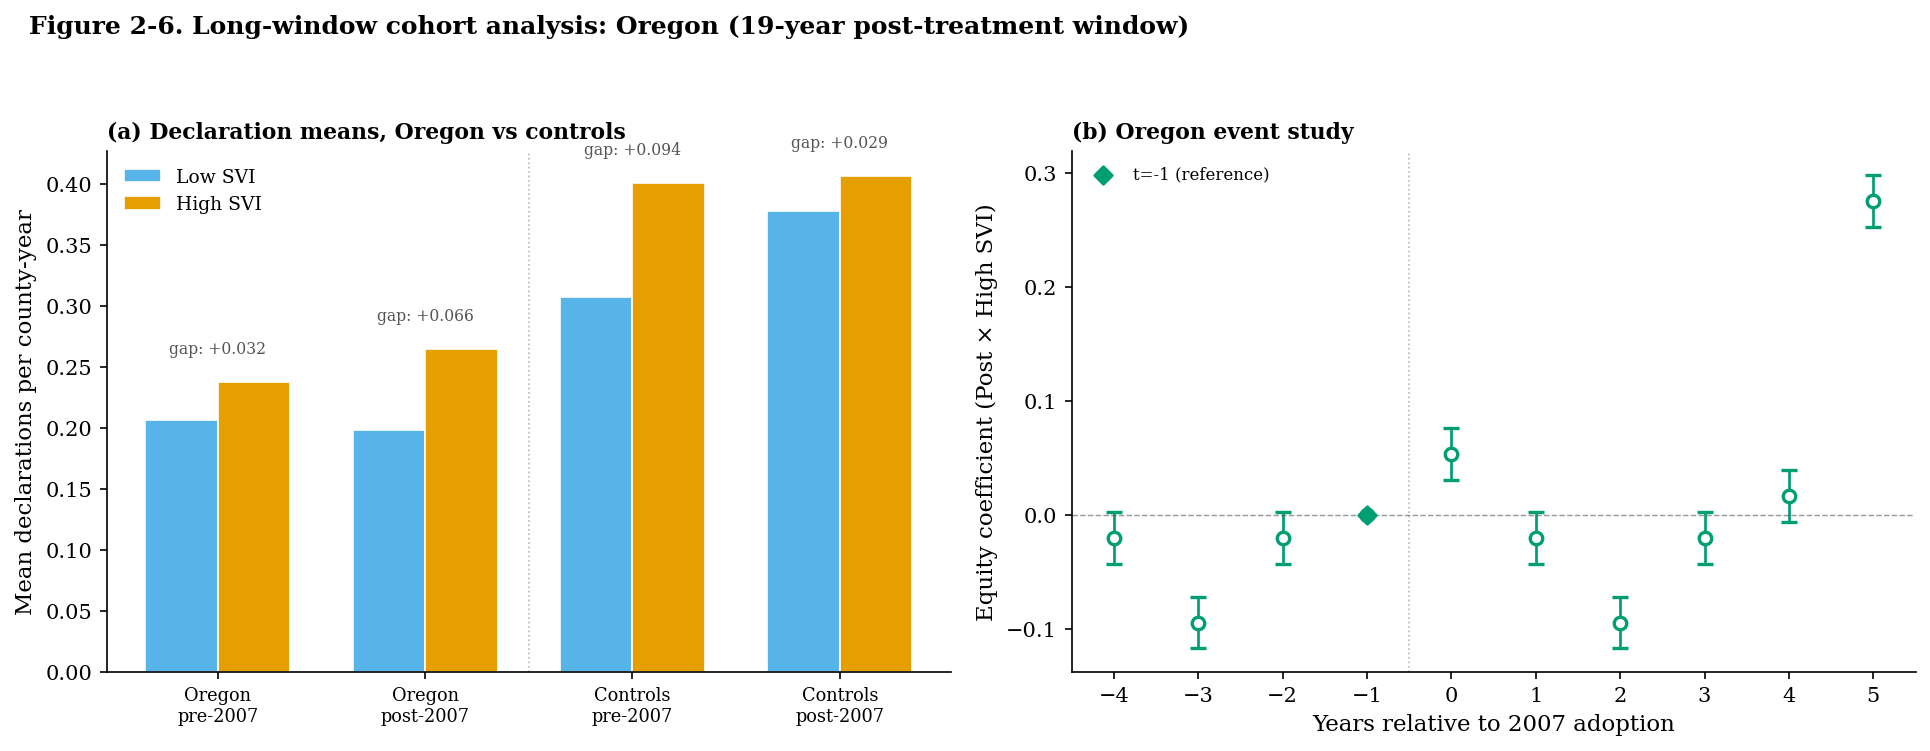

Saved fig6_longwindow.png and .pdf


In [43]:
# Figure 2-2: Oregon equity effect, pre- and post-2007 adoption

import matplotlib.pyplot as plt
import numpy as np

OR_FIPS = int(ej.loc[ej['State']=='Oregon','State_FIPS'].iloc[0])
OR_YEAR = int(ej.loc[ej['State']=='Oregon','Treatment_Year'].iloc[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

def _means(d, adopt_yr):
    pre, post = d[d['year']<adopt_yr], d[d['year']>=adopt_yr]
    return {
        'hi_pre':  pre[pre['hsvi']==1]['ndecl'].mean(),
        'lo_pre':  pre[pre['hsvi']==0]['ndecl'].mean(),
        'hi_post': post[post['hsvi']==1]['ndecl'].mean(),
        'lo_post': post[post['hsvi']==0]['ndecl'].mean(),
    }

# ─── Panel (a): pre/post bars ────────────────────────────────────────────
or_data = did[did['stfips']==OR_FIPS].copy()
nt_data = did[did['is_nt']==1].copy()

s_m, n_m = _means(or_data, OR_YEAR), _means(nt_data, OR_YEAR)

groups = [f'Oregon\npre-{OR_YEAR}', f'Oregon\npost-{OR_YEAR}',
          f'Controls\npre-{OR_YEAR}', f'Controls\npost-{OR_YEAR}']
lo_vals = [s_m['lo_pre'], s_m['lo_post'], n_m['lo_pre'], n_m['lo_post']]
hi_vals = [s_m['hi_pre'], s_m['hi_post'], n_m['hi_pre'], n_m['hi_post']]

x, w = np.arange(len(groups)), 0.35
ax1.bar(x - w/2, lo_vals, w, label='Low SVI', color=CB_SKYBLUE,
        edgecolor='white', linewidth=0.8)
ax1.bar(x + w/2, hi_vals, w, label='High SVI', color=CB_ORANGE,
        edgecolor='white', linewidth=0.8)

for i, (lo, hi) in enumerate(zip(lo_vals, hi_vals)):
    gap = hi - lo
    ax1.text(i, max(lo, hi) + 0.02, f'gap: {gap:+.3f}',
             ha='center', va='bottom', fontsize=7.5, color='#555555')

ax1.axvline(1.5, color='#888888', ls=':', lw=0.8, alpha=.6)
ax1.set_xticks(x); ax1.set_xticklabels(groups, fontsize=8.5)
ax1.set_ylabel('Mean declarations per county-year')
ax1.set_title('(a) Declaration means, Oregon vs controls',
              fontweight='bold', loc='left', fontsize=10.5)
ax1.legend(fontsize=9, framealpha=.85, edgecolor='none', loc='upper left')

# ─── Panel (b): event study ──────────────────────────────────────────────
es = did[(did['stfips']==OR_FIPS)|(did['is_nt']==1)].copy()
es['rel_t'] = np.where(es['stfips']==OR_FIPS, es['year']-OR_YEAR, np.nan)

def _bin(x):
    if pd.isna(x): return None
    xi = int(x)
    return xi if -4 <= xi <= 5 else None

es['evt'] = es['rel_t'].apply(_bin)
es = es[es['evt'].notna() | (es['stfips'] != OR_FIPS)].copy()

et = sorted(set(int(t) for t in es['evt'].dropna().unique() if int(t) != -1))
for t in et:
    es[f'e{t}']   = (es['evt'] == t).astype(int)
    es[f'e{t}_h'] = es[f'e{t}'] * es['hsvi']

esvars = [f'e{t}' for t in et] + ['hsvi'] + [f'e{t}_h' for t in et]
res = ols(es, 'ndecl', esvars, ctrls=None)

all_t = sorted(et + [-1])
bvals, sevals = [], []
for t in all_t:
    if t == -1:
        bvals.append(0); sevals.append(0)
    elif f'e{t}_h' in res:
        bvals.append(res[f'e{t}_h']['b']); sevals.append(res[f'e{t}_h']['se'])
    else:
        bvals.append(np.nan); sevals.append(np.nan)

ax2.errorbar(all_t, bvals, yerr=[1.96*s for s in sevals],
             fmt='o', color=CB_GREEN, capsize=4, ms=6, lw=0,
             elinewidth=1.3, capthick=1.3,
             markerfacecolor='white', markeredgewidth=1.6, markeredgecolor=CB_GREEN)
ax2.scatter([-1], [0], color=CB_GREEN, marker='D', s=35, zorder=5,
            edgecolor=CB_GREEN, linewidth=1.4, facecolor=CB_GREEN,
            label='t=-1 (reference)')
ax2.axhline(0, color='#555555', ls='--', lw=0.7, alpha=.6)
ax2.axvline(-0.5, color='#888888', ls=':', lw=0.8, alpha=.6)
ax2.set_xlabel(f'Years relative to {OR_YEAR} adoption')
ax2.set_ylabel('Equity coefficient (Post × High SVI)')
ax2.set_title('(b) Oregon event study',
              fontweight='bold', loc='left', fontsize=10.5)
ax2.set_xticks(range(-4, 6)); ax2.set_xlim(-4.5, 5.5)
ax2.legend(fontsize=8, loc='upper left', framealpha=.85, edgecolor='none')

fig.suptitle('Figure 2-6. Long-window cohort analysis: Oregon (19-year post-treatment window)',
             fontweight='bold', fontsize=12, ha='left', x=0.02, y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Figure_2-2_Oregon_Long_Window.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_2-2_Oregon_Long_Window.pdf', bbox_inches='tight')
plt.show()
print('Saved fig6_longwindow.png and .pdf')

In [44]:
# Verify CT spikes correspond to specific disaster years
ct_yearly = df[df['stfips']==9].groupby('year').agg(
    total_decl=('ndecl','sum'),
    cnty_with_decl=('anydecl','sum')
).reset_index()
print("CT declarations by year (year, total decl, counties with decl):")
print(ct_yearly[ct_yearly['year'].between(2003, 2013)].to_string(index=False))

CT declarations by year (year, total decl, counties with decl):
 year  total_decl  cnty_with_decl
 2003         0.0               0
 2004         0.0               0
 2005         5.0               5
 2006         0.0               0
 2007         7.0               7
 2008         0.0               0
 2009         0.0               0
 2010         5.0               5
 2011        21.0               8
 2012         7.0               7
 2013         8.0               8


In [45]:
# Wild cluster bootstrap (Cameron-Miller 2015, Rademacher, 999 reps)
# Small-cluster inference for preferred spec

import time
np.random.seed(42)
B = 999

need = ['ndecl'] + xm + CTR + ['stfips','year']
d_fit = did.dropna(subset=need).copy()
y = d_fit['ndecl'].values

chunks = [d_fit[xm].astype(float), d_fit[CTR].astype(float),
          pd.get_dummies(d_fit['stfips'], prefix='st', drop_first=True).astype(float),
          pd.get_dummies(d_fit['year'],   prefix='yr', drop_first=True).astype(float)]
X = sm.add_constant(pd.concat(chunks, axis=1))

mf = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': d_fit['stfips'].values})
b_main = mf.params['post_hsvi']
t_main = b_main / mf.bse['post_hsvi']
p_asy  = mf.pvalues['post_hsvi']

# Null-imposed residuals
nf = sm.OLS(y, X.drop(columns=['post_hsvi'])).fit()
yhat, resid = nf.fittedvalues, y - nf.fittedvalues

sts = d_fit['stfips'].unique()
tb  = np.zeros(B)

print(f"WCB (B={B}, {len(sts)} clusters)\n")
t0 = time.time()
for i in range(B):
    rw = np.random.choice([-1, 1], size=len(sts))
    w = d_fit['stfips'].map(dict(zip(sts, rw))).values
    yb = yhat + w * resid
    fb = sm.OLS(yb, X).fit(cov_type='cluster', cov_kwds={'groups': d_fit['stfips'].values})
    tb[i] = fb.params['post_hsvi'] / fb.bse['post_hsvi']
    if (i+1) % 200 == 0:
        print(f"  {i+1}/{B} ({time.time()-t0:.0f}s)")

p_wcb = (np.abs(tb) >= np.abs(t_main)).mean()
print(f"\n  β = {b_main:+.4f}  asymp p = {p_asy:.4f}  WCB p = {p_wcb:.4f}")
print(f"  N clusters: {len(sts)}, N obs: {len(d_fit):,}")
print(f"  Runtime: {time.time()-t0:.0f}s")

WCB (B=999, 47 clusters)

  200/999 (159s)
  400/999 (302s)
  600/999 (443s)
  800/999 (584s)

  β = -0.0341  asymp p = 0.0785  WCB p = 0.0781
  N clusters: 47, N obs: 78,520
  Runtime: 726s


In [46]:
# DIAGNOSTIC - identify the state(s) that drop out of the WCB sample.
# Chapter §2.7.2 says "the sample has 48 states" but Cell 39 reports
# 47 effective clusters. This cell finds which state(s) lose all rows
# under the dropna(subset=need) filter and which variable causes it.

need_diag = ['ndecl'] + xm + CTR + ['stfips','year']
before = did.copy()
after  = did.dropna(subset=need_diag)

states_before = set(before['stfips'].unique())
states_after  = set(after['stfips'].unique())
dropped_states = sorted(states_before - states_after)

print(f"States in DiD frame before dropna: {len(states_before)}")
print(f"States in DiD frame after  dropna: {len(states_after)}")
print(f"Dropped: {dropped_states}")

if dropped_states:
    for sf in dropped_states:
        sname = ej.loc[ej['State_FIPS']==sf, 'State'].iloc[0] if (ej['State_FIPS']==sf).any() else f'FIPS {sf}'
        sub = before[before['stfips']==sf]
        print(f"\n  {sname} (FIPS {sf}): {len(sub)} county-years before dropna")
        for v in need_diag:
            n_missing = sub[v].isna().sum()
            if n_missing > 0:
                pct = 100 * n_missing / len(sub)
                print(f"    {v}: {n_missing}/{len(sub)} missing ({pct:.0f}%)")
else:
    # Same state count but fewer effective clusters - a state may be present
    # in the data but absent from one of the FE absorption groups.
    print("\nNo states fully dropped. Effective cluster reduction may come from")
    print("singleton state-year combinations or perfect collinearity in covariates.")

# Per-variable summary of missingness in the full DiD frame
print("\nFull-frame missingness by variable:")
for v in need_diag:
    n_missing = before[v].isna().sum()
    if n_missing > 0:
        print(f"  {v}: {n_missing}/{len(before)} ({100*n_missing/len(before):.1f}%)")


States in DiD frame before dropna: 48
States in DiD frame after  dropna: 47
Dropped: [np.int64(9)]

  Connecticut (FIPS 9): 208 county-years before dropna
    rural: 208/208 missing (100%)

Full-frame missingness by variable:
  rural: 208/78728 (0.3%)


In [47]:
# WCB by tier (Tier 3 has only 6 clusters - asymptotic inference still weak)

def wcb(sub, B=999, seed=42):
    np.random.seed(seed)
    need = ['ndecl'] + xm + CTR + ['stfips','year']
    d = sub.dropna(subset=need).copy()
    y = d['ndecl'].values
    chunks = [d[xm].astype(float), d[CTR].astype(float),
              pd.get_dummies(d['stfips'], prefix='st', drop_first=True).astype(float),
              pd.get_dummies(d['year'],   prefix='yr', drop_first=True).astype(float)]
    X = sm.add_constant(pd.concat(chunks, axis=1))
    mf = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': d['stfips'].values})
    b = mf.params['post_hsvi']; t = b / mf.bse['post_hsvi']; pa = mf.pvalues['post_hsvi']
    nf = sm.OLS(y, X.drop(columns=['post_hsvi'])).fit()
    yh, rs = nf.fittedvalues, y - nf.fittedvalues
    sts = d['stfips'].unique(); tb = np.zeros(B)
    for i in range(B):
        rw = np.random.choice([-1,1], size=len(sts))
        w = d['stfips'].map(dict(zip(sts, rw))).values
        fb = sm.OLS(yh + w*rs, X).fit(cov_type='cluster', cov_kwds={'groups': d['stfips'].values})
        tb[i] = fb.params['post_hsvi'] / fb.bse['post_hsvi']
    return b, pa, (np.abs(tb) >= np.abs(t)).mean(), d['stfips'].nunique()

print(f"{'Tier':8s} {'β':>9s} {'n_clust':>8s} {'asy_p':>8s} {'wcb_p':>8s}")
tier_wcb_out = []
for tc, tl in [(1,'Tier 1'), (2,'Tier 2'), (3,'Tier 3')]:
    ss = did[(did[f't{tc}']==1)|(did['is_nt']==1)]
    b, pa, pw, nc = wcb(ss, B=999)
    print(f"{tl:8s} {b:>+9.4f} {nc:>8d} {pa:>8.4f} {pw:>8.4f}")
    tier_wcb_out.append({'Tier':tl,'beta':b,'clusters':nc,'p_asymp':pa,'p_wcb':pw})

Tier             β  n_clust    asy_p    wcb_p
Tier 1     -0.0345       33   0.2842   0.3263
Tier 2     -0.0275       36   0.2055   0.2643
Tier 3     -0.0890       34   0.0319   0.2042


In [48]:
# Tables 2-3, 2-4, 2-S10, 2-S11

# Validate dependencies
required = {'r2': r2, 'p_wcb': p_wcb if 'p_wcb' in dir() else None,
            'tier_wcb_out': tier_wcb_out if 'tier_wcb_out' in dir() else None,
            'tmods': tmods, 'dsh': dsh if 'dsh' in dir() else None}
missing = [k for k,v in required.items() if v is None]
if missing:
    raise RuntimeError(f"Missing dependencies: {missing}. Run earlier cells first.")

# Compute Oregon standalone if not cached from Cell 37
if 'r_oregon' not in dir():
    or_fips = int(ej.loc[ej['State']=='Oregon','State_FIPS'].iloc[0])
    nt_list = did.loc[did['is_nt']==1,'stfips'].unique().tolist()
    r_oregon = ols(did[did['stfips'].isin([or_fips]+nt_list)], 'ndecl', xm, ctrls=CTR)

# Per-event specs (Oregon plus tier-stratified)
if 'r_or_pe' not in dir():
    or_fips = int(ej.loc[ej['State']=='Oregon','State_FIPS'].iloc[0])
    or_sh = dsh[(dsh['stfips']==or_fips)|(dsh['is_nt']==1)].copy()
    r_or_pe = ols(or_sh, 'decl_per_evt', xm, ctrls=CTR)

# Per-event by tier
tier_pe = {}
for tc, tl in [(1,'Tier 1'),(2,'Tier 2'),(3,'Tier 3')]:
    ss = dsh[(dsh[f't{tc}']==1)|(dsh['is_nt']==1)]
    tier_pe[tl] = ols(ss, 'decl_per_evt', xm, ctrls=CTR)

# Oregon placebo (3-yr earlier fake adoption, pre-period only)
or_fips = int(ej.loc[ej['State']=='Oregon','State_FIPS'].iloc[0])
or_year = int(ej.loc[ej['State']=='Oregon','Treatment_Year'].iloc[0])
or_plac = did[did['stfips'].isin([or_fips] + did.loc[did['is_nt']==1,'stfips'].unique().tolist())].copy()
or_plac = or_plac[(or_plac['stfips']!=or_fips) | (or_plac['year'] < or_year)].copy()
or_plac['fakeyr'] = np.where(or_plac['stfips']==or_fips, or_year - 3, np.nan)
or_plac['pfake'] = np.where(or_plac['fakeyr'].notna() & (or_plac['year'] >= or_plac['fakeyr']), 1, 0)
or_plac['fakeh'] = or_plac['pfake'] * or_plac['hsvi']
r_or_plac = ols(or_plac, 'ndecl', ['pfake','hsvi','fakeh'], ctrls=CTR)

# Get switcher counts per tier (live, post-correction)
def _ne(tc):
    return ej.loc[(ej['Treatment_Code']==tc) & (~ej['State_FIPS'].isin(at_fips)), 'State'].nunique()
n_t1 = _ne(1); n_t2 = _ne(2); n_t3 = _ne(3); n_nt = (ej['Treatment_Code']==0).sum()
n_clust_main = len(d_fit['stfips'].unique()) if 'd_fit' in dir() else did['stfips'].nunique()

# ──────────────────────────────────────────────────────────────────────
print("TABLE 2-3 ADDITION (insert under Post × EJ × High SVI in column 2)")
print(f"""
  Post × EJ × High SVI    {r2['post_hsvi']['b']:+.3f}{r2['post_hsvi']['sig']}
                          ({r2['post_hsvi']['se']:.3f})
  Asymp p                 {r2['post_hsvi']['p']:.3f}
  WCB p (B=999)           {p_wcb:.3f}

  Cameron & Miller (2015), Rademacher, null imposed, state clusters
""")

# ──────────────────────────────────────────────────────────────────────
print("TABLE 2-4 PANEL B REPLACEMENT (separate regressions, OLS)")

def _tline(tier_label, tier_count):
    m = tmods[tier_label.replace(' ','')]['post_hsvi']
    w = next(t for t in tier_wcb_out if t['Tier']==tier_label)
    return (f"{tier_label} ({tier_count} EJ vs {n_nt} ctrl)  "
            f"{m['b']:+.3f}  {m['se']:.3f}    {m['p']:.3f}     "
            f"{w['p_wcb']:.3f}     [{m['lo']:+.3f}, {m['hi']:+.3f}]")

print(f"""
                              β        SE       Asymp p   WCB p     95% CI
{_tline('Tier 1', n_t1)}
{_tline('Tier 2', n_t2)}
{_tline('Tier 3', n_t3)}

  Note: Asymp p reports asymptotic cluster-robust p-value; WCB p reports
  wild cluster bootstrap p-value (B=999). Cluster counts: Tier 1 = {n_t1}
  treated; Tier 2 = {n_t2} treated; Tier 3 = {n_t3} treated, all against
  {n_nt} never-treated states.
""")

# ──────────────────────────────────────────────────────────────────────
print("TABLE 2-4 PANEL D NEW (per-event specification, SHELDUS window 2000-{})".format(SH_END if SH_END else 'N/A'))

def _peline(tier_label):
    m = tier_pe[tier_label]['post_hsvi']
    return f"{tier_label} per-event          {m['b']:+.3f}   {m['se']:.3f}    {m['p']:.3f}     [{m['lo']:+.3f}, {m['hi']:+.3f}]"

print(f"""
                          β        SE       p         95% CI
{_peline('Tier 1')}
{_peline('Tier 2')}
{_peline('Tier 3')}

  Note: Per-event specification uses declarations / SHELDUS-recorded
  hazard events as the dependent variable. Conditioning on hazard
  occurrence isolates the administrative response from hazard exposure.
""")

# ──────────────────────────────────────────────────────────────────────
print("TABLE 2-S10 NEW (Long-window cohort: Oregon)")

ro = r_oregon['post_hsvi']
rop = r_or_pe['post_hsvi']
rop_plac = r_or_plac['fakeh']

print(f"""
                              β        SE       p         95% CI
Oregon count (vs never)       {ro['b']:+.4f}   {ro['se']:.4f}   {ro['p']:.3f}     [{ro['lo']:+.4f}, {ro['hi']:+.4f}]
Oregon per-event              {rop['b']:+.4f}   {rop['se']:.4f}   {rop['p']:.3f}     [{rop['lo']:+.4f}, {rop['hi']:+.4f}]
Oregon placebo (3-yr earlier) {rop_plac['b']:+.4f}   {rop_plac['se']:.4f}   {rop_plac['p']:.3f}     [{rop_plac['lo']:+.4f}, {rop_plac['hi']:+.4f}]

  Note: Oregon adopted EJ framework in 2007 (19-yr post-treatment window) and
  is the only long-window cohort that produces stable inference. Connecticut
  adopted in 2008 (18-yr post-treatment window) but cannot be reported as a
  standalone long-window cohort because the regression matrix is singular
  with a single treated cluster, an outcome confirmed independently by the
  pyfixest validation in §2.7.6 (the manual OLS routine returns zeros via
  pseudo-inverse where pyfixest correctly returns NaN). Connecticut counties
  retain historical FIPS codes (8 counties); CDC SVI 2022 Planning Region
  values do not merge with FEMA county data.
""")

# ──────────────────────────────────────────────────────────────────────
print("TABLE 2-S11 NEW (Per-event by tier with WCB inference)")

def _s11line(tier_label, tier_count):
    m = tmods[tier_label.replace(' ','')]['post_hsvi']
    pe = tier_pe[tier_label]['post_hsvi']
    w = next(t for t in tier_wcb_out if t['Tier']==tier_label)
    return (f"{tier_label} (n={tier_count})    "
            f"{m['b']:+.3f}  {m['p']:.3f}     "
            f"{pe['b']:+.3f}  {pe['p']:.3f}       "
            f"{w['p_wcb']:.3f}")

print(f"""
                  Count               Per-event           WCB
Tier              β       Asymp p     β       p           p (count)
{_s11line('Tier 1', n_t1)}
{_s11line('Tier 2', n_t2)}
{_s11line('Tier 3', n_t3)}

  Note: Two independent robustness procedures examine the count
  significance at every tier. WCB corrects for small-cluster inference;
  per-event specification corrects for differential hazard exposure.
""")

TABLE 2-3 ADDITION (insert under Post × EJ × High SVI in column 2)

  Post × EJ × High SVI    -0.034*
                          (0.019)
  Asymp p                 0.078
  WCB p (B=999)           0.078

  Cameron & Miller (2015), Rademacher, null imposed, state clusters

TABLE 2-4 PANEL B REPLACEMENT (separate regressions, OLS)

                              β        SE       Asymp p   WCB p     95% CI
Tier 1 (6 EJ vs 28 ctrl)  -0.034  0.032    0.284     0.326     [-0.098, +0.029]
Tier 2 (8 EJ vs 28 ctrl)  -0.027  0.022    0.205     0.264     [-0.070, +0.015]
Tier 3 (6 EJ vs 28 ctrl)  -0.089  0.041    0.032     0.204     [-0.170, -0.008]

  Note: Asymp p reports asymptotic cluster-robust p-value; WCB p reports
  wild cluster bootstrap p-value (B=999). Cluster counts: Tier 1 = 6
  treated; Tier 2 = 8 treated; Tier 3 = 6 treated, all against
  28 never-treated states.

TABLE 2-4 PANEL D NEW (per-event specification, SHELDUS window 2000-2024)

                          β        SE       p  

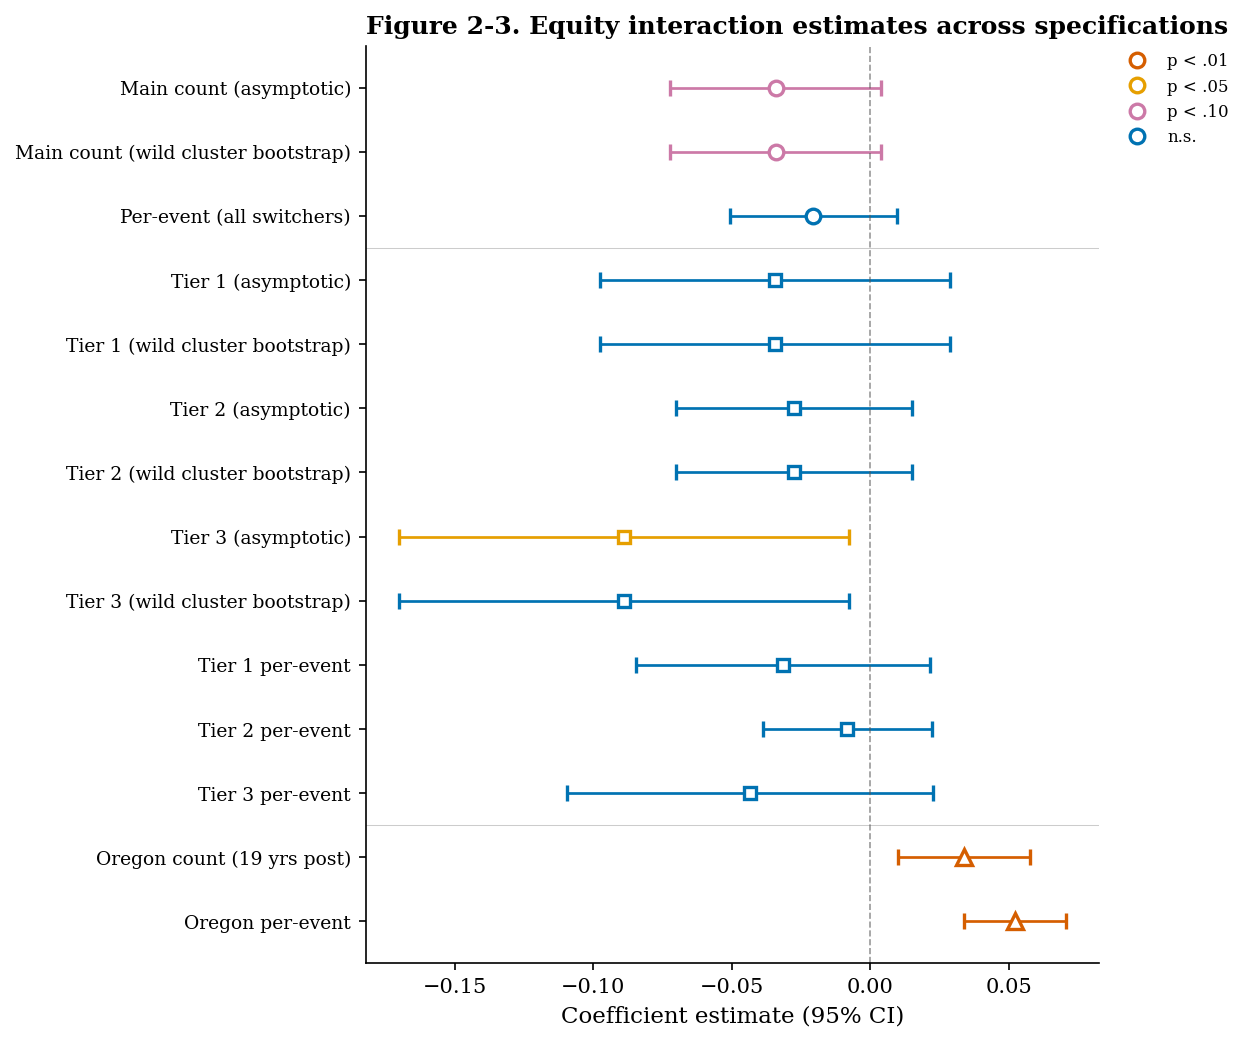

In [49]:
# Figure 2-3

if 'p_wcb' not in dir():
    raise RuntimeError("Run Cell 39 (main WCB) before this cell")
if 'tier_wcb_out' not in dir():
    raise RuntimeError("Run Cell 40 (WCB by tier) before this cell")

# Long-window cohort regression (Oregon only)
or_fips = int(ej.loc[ej['State']=='Oregon','State_FIPS'].iloc[0])
nt_list = did.loc[did['is_nt']==1,'stfips'].unique().tolist()

or_sample = did[did['stfips'].isin([or_fips]+nt_list)].copy()
r_oregon  = ols(or_sample, 'ndecl', xm, ctrls=CTR)

# Per-event (SHELDUS window)
dsh = did[did['year']<=SH_END].copy()
dsh['decl_per_evt'] = dsh['ndecl']/(dsh['sh_nevents']+1)

r_main_pe = ols(dsh, 'decl_per_evt', xm, ctrls=CTR)

or_sh = dsh[(dsh['stfips']==or_fips)|(dsh['is_nt']==1)].copy()
r_or_pe = ols(or_sh, 'decl_per_evt', xm, ctrls=CTR)

# Build rows
rows = []
m = r2['post_hsvi']
rows.append(('Main count (asymptotic)',              m['b'], m['lo'], m['hi'], m['p'], 'Main'))
rows.append(('Main count (wild cluster bootstrap)',  m['b'], m['lo'], m['hi'], p_wcb,  'Main'))
rpe = r_main_pe['post_hsvi']
rows.append(('Per-event (all switchers)',            rpe['b'], rpe['lo'], rpe['hi'], rpe['p'], 'Main'))

# Tier asymptotic and WCB rows from Cell 40 output
for tr in tier_wcb_out:
    tc = {'Tier 1':1,'Tier 2':2,'Tier 3':3}[tr['Tier']]
    ss = did[(did[f't{tc}']==1)|(did['is_nt']==1)]
    rt = ols(ss,'ndecl',xm,ctrls=CTR)['post_hsvi']
    rows.append((f"{tr['Tier']} (asymptotic)",            rt['b'], rt['lo'], rt['hi'], tr['p_asymp'], 'Tier'))
    rows.append((f"{tr['Tier']} (wild cluster bootstrap)", rt['b'], rt['lo'], rt['hi'], tr['p_wcb'],   'Tier'))

# Tier per-event rows (recomputed live)
for tier_label in ['Tier 1','Tier 2','Tier 3']:
    tc = {'Tier 1':1,'Tier 2':2,'Tier 3':3}[tier_label]
    ss = dsh[(dsh[f't{tc}']==1)|(dsh['is_nt']==1)]
    rtpe = ols(ss,'decl_per_evt',xm,ctrls=CTR)['post_hsvi']
    rows.append((f"{tier_label} per-event", rtpe['b'], rtpe['lo'], rtpe['hi'], rtpe['p'], 'Tier'))

# Long-window cohort: Oregon
ro = r_oregon['post_hsvi']
rows.append(('Oregon count (19 yrs post)', ro['b'],  ro['lo'],  ro['hi'],  ro['p'],  'LongWindow'))
rop = r_or_pe['post_hsvi']
rows.append(('Oregon per-event',           rop['b'], rop['lo'], rop['hi'], rop['p'], 'LongWindow'))

# Plot
n = len(rows)
fig, ax = plt.subplots(figsize=(8.5, n*0.42 + 1.2))

for i, (label, b, lo, hi, p, grp) in enumerate(rows):
    yi = n - 1 - i
    c = CB_RED if p<.01 else CB_ORANGE if p<.05 else CB_PURPLE if p<.1 else CB_BLUE
    marker = '^' if grp=='LongWindow' else 's' if grp=='Tier' else 'o'
    ms = 8 if grp=='LongWindow' else 6 if grp=='Tier' else 7
    ax.errorbar(b, yi, xerr=[[b-lo],[hi-b]], fmt=marker, color=c,
                capsize=4, ms=ms, lw=1.3,
                markerfacecolor='white', markeredgewidth=1.6, markeredgecolor=c)

grps = [r[5] for r in rows]
for i in range(1, n):
    if grps[i] != grps[i-1]:
        ax.axhline(n-1-i+0.5, color='#cccccc', lw=0.5)

ax.axvline(0, color='#555555', ls='--', lw=0.8, alpha=.6)
ax.set_yticks(range(n))
ax.set_yticklabels([r[0] for r in rows[::-1]], fontsize=9)
ax.set_xlabel('Coefficient estimate (95% CI)')
ax.set_title('Figure 2-3. Equity interaction estimates across specifications',
             fontweight='bold', loc='left')

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
              markeredgecolor=c, markeredgewidth=1.6, label=lb, ms=7)
       for c, lb in [(CB_RED,'p < .01'),(CB_ORANGE,'p < .05'),
                     (CB_PURPLE,'p < .10'),(CB_BLUE,'n.s.')]]
ax.legend(handles=leg, loc='upper left', bbox_to_anchor=(1.02, 1),
          fontsize=8, framealpha=.85, edgecolor='none', borderaxespad=0)

plt.tight_layout()
plt.savefig('Figure_2-3_Equity_Interaction_Estimates.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure_2-3_Equity_Interaction_Estimates.pdf', bbox_inches='tight')
plt.show()

In [50]:
ct_check = df[df['stfips']==9].drop_duplicates('FIPS')[['FIPS','svi22','hsvi']]
print(ct_check)
print(f"CT counties with hsvi==1: {ct_check['hsvi'].sum()}/8")

      FIPS   svi22  hsvi
8034  9001  0.6184     1
8060  9003  0.5955     1
8086  9005  0.1512     0
8112  9007  0.1843     0
8138  9009  0.6512     1
8164  9011  0.3959     0
8190  9013  0.1073     0
8216  9015  0.4799     0
CT counties with hsvi==1: 3/8


In [51]:
# CI vs Tier diagnostic
ci_states = ej[ej['Cumulative_Impacts']==1].sort_values('Treatment_Year')
tier_label = {1:'Tier 1', 2:'Tier 2', 3:'Tier 3', 0:'No EJ'}

print(f"States with Cumulative Impact provision: {len(ci_states)}")
print(f"{'State':<20} {'Year':<6} {'Tier':<8}")
for _, r in ci_states.iterrows():
    yr = int(r['Treatment_Year']) if pd.notna(r['Treatment_Year']) else '-'
    print(f"{r['State']:<20} {yr!s:<6} {tier_label.get(r['Treatment_Code'],'?'):<8}")

# Split by tier
print("\nBy tier:")
for code, label in [(1,'Tier 1'),(2,'Tier 2'),(3,'Tier 3'),(0,'No EJ')]:
    sub = ci_states[ci_states['Treatment_Code']==code]['State'].tolist()
    print(f"  {label}: {len(sub)} - {', '.join(sub) if sub else '(none)'}")

# CI states actually in the DiD analysis (excluding always-treated CA, MT)
at_states = ej.loc[ej['Treatment_Year'] < YR0, 'State'].tolist()
ci_in_did = ci_states[~ci_states['State'].isin(at_states)]
print(f"\nCI states in DiD analysis ({len(ci_in_did)} after excluding always-treated):")
print(f"  {', '.join(ci_in_did['State'].tolist())}")

States with Cumulative Impact provision: 9
State                Year   Tier    
California           1999   Tier 1  
Connecticut          2008   Tier 1  
New York             2019   Tier 1  
New Jersey           2020   Tier 1  
Maryland             2021   Tier 2  
Colorado             2021   Tier 1  
Massachusetts        2021   Tier 2  
Vermont              2022   Tier 2  
Minnesota            2023   Tier 1  

By tier:
  Tier 1: 6 - California, Connecticut, New York, New Jersey, Colorado, Minnesota
  Tier 2: 3 - Maryland, Massachusetts, Vermont
  Tier 3: 0 - (none)
  No EJ: 0 - (none)

CI states in DiD analysis (8 after excluding always-treated):
  Connecticut, New York, New Jersey, Maryland, Colorado, Massachusetts, Vermont, Minnesota


In [52]:
# --- Framework Focus subset regressions (final) ---
ej_fresh = pd.read_excel(data_dir / 'Article_2_-_State_EJ_Framework_Inventory_v4.xlsx',
                          sheet_name='State_EJ_Framework_Inventory')
ej_fresh['State_FIPS'] = ej_fresh['State_FIPS'].astype(int)

base = (ej_fresh['Treatment_Year'].notna()) & (~ej_fresh['State_FIPS'].isin(at_fips))

# ── accounting check ───────────────────────────────────────────────────────
print("INVENTORY ACCOUNTING")
print(f"Always-treated excluded (CA, MT): "
      f"{ej_fresh.loc[ej_fresh['State_FIPS'].isin(at_fips), 'State'].tolist()}")
print(f"Tier 3 NaN excluded (no Framework_Focus): "
      f"{ej_fresh.loc[base & ej_fresh['Framework_Focus'].isna(), 'State'].tolist()}")
print(f"\nFramework_Focus in DiD sample (base filter applied):")
print(ej_fresh.loc[base & ej_fresh['Framework_Focus'].notna()]
      .groupby('Framework_Focus')['State'].apply(list).to_string())

# ── helper ─────────────────────────────────────────────────────────────────
def _run_subset(label, fips_list):
    states = ej_fresh.loc[ej_fresh['State_FIPS'].isin(fips_list), 'State'].tolist()
    print(f"\n{'─'*60}")
    print(f"{label}")
    print(f"  States (n={len(fips_list)}): {states}")
    if len(fips_list) == 0:
        print("  Skipped — no states in DiD sample")
        return None
    sub = did[(did['stfips'].isin(fips_list)) | (did['is_nt'] == 1)].copy()
    r = ols(sub, 'ndecl', xm, ctrls=CTR)
    m = r['post_hsvi']
    print(f"  Count:     β={m['b']:+.4f}  SE={m['se']:.4f}  "
          f"p={m['p']:.3f}  95%CI=[{m['lo']:+.4f}, {m['hi']:+.4f}]")
    if has_sheldus:
        dsh_sub = sub[sub['year'] <= SH_END].copy()
        dsh_sub['decl_per_evt'] = dsh_sub['ndecl'] / (dsh_sub['sh_nevents'] + 1)
        rpe = ols(dsh_sub, 'decl_per_evt', xm, ctrls=CTR)
        mpe = rpe['post_hsvi']
        print(f"  Per-event: β={mpe['b']:+.4f}  SE={mpe['se']:.4f}  p={mpe['p']:.3f}")
    return r

# ── subset definitions ─────────────────────────────────────────────────────

# Subset 1: Climate-relevant — climate_disaster + both
# DiD n=5 (NY + IL + MA + VT + WA); CA is 6th both-state, excluded as always-treated
clim_fips = ej_fresh.loc[
    base & (ej_fresh['Framework_Focus'].isin(['climate_disaster', 'both'])),
    'State_FIPS'
].tolist()

# Subset 2: Both domains only — climate/disaster AND air/water/Superfund
# DiD n=4 (IL + MA + VT + WA); CA excluded as always-treated
both_fips = ej_fresh.loc[
    base & (ej_fresh['Framework_Focus'] == 'both'),
    'State_FIPS'
].tolist()

# Subset 3: Air/water/Superfund only — traditional EJ focus, no climate provisions
# DiD n=9; full inventory n=16 (6 Tier3 NaN + CA always-treated account for difference)
aws_fips = ej_fresh.loc[
    base & (ej_fresh['Framework_Focus'] == 'air_water_superfund'),
    'State_FIPS'
].tolist()

# Note: climate_disaster alone = NY only (n=1 in DiD), not estimable separately
print(f"\nclimate_disaster only (n=1, not estimated separately): "
      f"{ej_fresh.loc[base & (ej_fresh['Framework_Focus']=='climate_disaster'), 'State'].tolist()}")

# ── run regressions ────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FRAMEWORK FOCUS SUBSET REGRESSIONS")

r_clim = _run_subset(
    "Subset 1: Climate-relevant (climate_disaster + both) — n=5 in DiD, n=6 total",
    clim_fips)

r_both = _run_subset(
    "Subset 2: Both domains (climate/disaster + air/water/Superfund) — n=4 in DiD, n=5 total",
    both_fips)

r_aws = _run_subset(
    "Subset 3: Air/water/Superfund only — n=9 in DiD, n=16 total",
    aws_fips)

# ── final accounting ───────────────────────────────────────────────────────
t3_nan_n = ej_fresh.loc[base & ej_fresh['Framework_Focus'].isna()].shape[0]
print(f"\n{'='*60}")
print(f"ACCOUNTING CHECK")
print(f"  Climate-relevant (DiD):      {len(clim_fips)}")
print(f"  Air/water/Superfund (DiD):   {len(aws_fips)}")
print(f"  Tier 3 NaN (excluded):       {t3_nan_n}")
print(f"  Always-treated (CA + MT):    {len(at_fips)}")
print(f"  Total:                       "
      f"{len(clim_fips) + len(aws_fips) + t3_nan_n + len(at_fips)} (should = 22)")

INVENTORY ACCOUNTING
Always-treated excluded (CA, MT): ['California', 'Montana']
Tier 3 NaN excluded (no Framework_Focus): ['Delaware', 'Hawaii', 'Michigan', 'North Carolina', 'Pennsylvania', 'Rhode Island']

Framework_Focus in DiD sample (base filter applied):
Framework_Focus
air_water_superfund    [Colorado, Connecticut, Maine, Maryland, Minne...
both                      [Illinois, Massachusetts, Vermont, Washington]
climate_disaster                                              [New York]

climate_disaster only (n=1, not estimated separately): ['New York']

FRAMEWORK FOCUS SUBSET REGRESSIONS

────────────────────────────────────────────────────────────
Subset 1: Climate-relevant (climate_disaster + both) — n=5 in DiD, n=6 total
  States (n=5): ['Illinois', 'Massachusetts', 'New York', 'Vermont', 'Washington']
  Count:     β=-0.0331  SE=0.0257  p=0.199  95%CI=[-0.0834, +0.0173]
  Per-event: β=-0.0063  SE=0.0158  p=0.693

────────────────────────────────────────────────────────────
Su

In [53]:
# --- COVID channel tests ---

# Channel 1: Declaration surge — does 2020 inflate ndecl differentially by EJ status?
ej_state_fips = set(ej.loc[ej['Treatment_Code'] > 0, 'State_FIPS'].tolist())
cov_yr = df[df['year'] == 2020].copy()
cov_yr['ej_state'] = cov_yr['stfips'].isin(ej_state_fips).astype(int)
cov_means = cov_yr.groupby('ej_state')['ndecl'].mean()
print("Channel 1 — mean ndecl in 2020:")
print(f"  Non-EJ states: {cov_means.get(0, float('nan')):.4f}")
print(f"  EJ states:     {cov_means.get(1, float('nan')):.4f}")

# Channel 2: Late adopters (2019–2021) — post-period dominated by COVID
late_sw = ej.loc[
    (ej['Treatment_Year'].between(2019, 2021)) &
    (~ej['State_FIPS'].isin(at_fips)),
    ['State', 'Treatment_Year', 'Treatment_Code']
].copy()
late_sw['post_yrs_total']  = YR1 - late_sw['Treatment_Year'] + 1
late_sw['post_yrs_covid']  = late_sw['Treatment_Year'].apply(
    lambda y: max(0, min(2022, YR1) - max(y, 2020) + 1))
late_sw['pct_covid'] = late_sw['post_yrs_covid'] / late_sw['post_yrs_total']
print(f"\nChannel 2 — Late adopters, share of post-treatment in COVID window (2020–2022):")
print(late_sw[['State','Treatment_Year','post_yrs_total','pct_covid']].to_string(index=False))

# Channel 3: Pre-COVID panel only (≤2019) vs full panel
pre_covid_did = did[did['year'] <= 2019].copy()
r_pc  = ols(pre_covid_did, 'ndecl', xm, ctrls=CTR)
m_pc  = r_pc['post_hsvi']
m_full = r2['post_hsvi']
print(f"\nChannel 3 — Effect estimate comparison:")
print(f"  Full panel (2000–{YR1}):  β={m_full['b']:+.4f}  p={m_full['p']:.3f}")
print(f"  Pre-COVID  (2000–2019): β={m_pc['b']:+.4f}  p={m_pc['p']:.3f}")

# Channel 4: Tier 3 post-treatment window lengths (nearly all post-COVID adoptions)
t3_rows = ej.loc[
    (ej['Treatment_Code'] == 3) & (~ej['State_FIPS'].isin(at_fips)),
    ['State', 'Treatment_Year']
].copy()
t3_rows['post_yrs'] = YR1 - t3_rows['Treatment_Year'] + 1
print(f"\nChannel 4 — Tier 3 post-treatment windows:")
print(t3_rows.to_string(index=False))

Channel 1 — mean ndecl in 2020:
  Non-EJ states: 1.2396
  EJ states:     1.1350

Channel 2 — Late adopters, share of post-treatment in COVID window (2020–2022):
        State  Treatment_Year  post_yrs_total  pct_covid
     Colorado          2021.0             5.0   0.400000
        Maine          2021.0             5.0   0.400000
     Maryland          2021.0             5.0   0.400000
Massachusetts          2021.0             5.0   0.400000
   New Jersey          2020.0             6.0   0.500000
   New Mexico          2021.0             5.0   0.400000
     New York          2019.0             7.0   0.428571
     Virginia          2020.0             6.0   0.500000
   Washington          2019.0             7.0   0.428571

Channel 3 — Effect estimate comparison:
  Full panel (2000–2025):  β=-0.0341  p=0.078
  Pre-COVID  (2000–2019): β=-0.0406  p=0.018

Channel 4 — Tier 3 post-treatment windows:
         State  Treatment_Year  post_yrs
      Delaware          2022.0       4.0
        Haw

In [54]:
# relative-time decomposition: early vs late post-treatment

sw_did = did[did['is_sw'] == 1].copy()

bins = [(-np.inf, 0), (1, 3), (4, 7), (8, np.inf)]
labels = ['pre', 'post_1_3', 'post_4_7', 'post_8plus']
sw_did['rel_bin'] = pd.cut(sw_did['rel_t'], bins=[b[0] for b in bins] + [np.inf],
                            labels=labels, right=True)

# Mean post_hsvi-weighted ndecl by bin for switchers only
sym_tab = (
    sw_did.groupby('rel_bin', observed=True)
    .apply(lambda x: pd.Series({
        'n_obs':       len(x),
        'mean_ndecl':  x['ndecl'].mean(),
        'mean_hsvi_w': x.loc[x['hsvi']==1,'ndecl'].mean() - x.loc[x['hsvi']==0,'ndecl'].mean()
    }))
    .reset_index()
)
print("Symbolic vs substantive — mean declaration gap (high-SVI minus low-SVI) by years-post:")
print(sym_tab.to_string(index=False))

# Event-study binned OLS (relative time dummies × hsvi)
sw_did['rt_1_3']   = ((sw_did['rel_t'] >= 1) & (sw_did['rel_t'] <= 3)).astype(int)
sw_did['rt_4_7']   = ((sw_did['rel_t'] >= 4) & (sw_did['rel_t'] <= 7)).astype(int)
sw_did['rt_8plus'] = (sw_did['rel_t'] >= 8).astype(int)

for col in ['rt_1_3','rt_4_7','rt_8plus']:
    sw_did[f'{col}_hsvi'] = sw_did[col] * sw_did['hsvi']

xm_sym = [c for c in xm if c != 'post_hsvi'] + ['rt_1_3','rt_4_7','rt_8plus',
                                                   'rt_1_3_hsvi','rt_4_7_hsvi','rt_8plus_hsvi']
r_sym = ols(sw_did, 'ndecl', xm_sym, ctrls=CTR)

print(f"\nBinned interaction estimates (equity gap × time-since-adoption):")
for k in ['rt_1_3_hsvi','rt_4_7_hsvi','rt_8plus_hsvi']:
    if k in r_sym:
        m = r_sym[k]
        print(f"  {k:20s}  β={m['b']:+.4f}  p={m['p']:.3f}")

Symbolic vs substantive — mean declaration gap (high-SVI minus low-SVI) by years-post:
   rel_bin   n_obs  mean_ndecl  mean_hsvi_w
       pre 19873.0    0.274241    -0.016735
  post_1_3  1959.0    0.187851    -0.046179
  post_4_7   940.0    0.140426     0.032982
post_8plus  1044.0    0.266284     0.078244

Binned interaction estimates (equity gap × time-since-adoption):
  rt_1_3_hsvi           β=-0.0561  p=0.167
  rt_4_7_hsvi           β=+0.0171  p=0.271
  rt_8plus_hsvi         β=+0.0635  p=0.020


In [55]:
# --- Longest-window cohort analysis ---
# Excludes always-treated (CA=1999, MT=1972). CT included in panel but
# excluded from standalone cohort (singular matrix — see dissertation text).

lw_fips = ej.loc[
    (ej['Treatment_Year'].notna()) &
    (~ej['State_FIPS'].isin(at_fips)),
    ['State', 'State_FIPS', 'Treatment_Year', 'Treatment_Code']
].copy()
lw_fips['post_yrs'] = YR1 - lw_fips['Treatment_Year'] + 1
lw_fips = lw_fips.sort_values('post_yrs', ascending=False).head(4)
print("Four longest-window switchers:")
print(lw_fips[['State','Treatment_Year','post_yrs','Treatment_Code']].to_string(index=False))

lw_state_fips = lw_fips['State_FIPS'].tolist()
did_lw = did[(did['stfips'].isin(lw_state_fips)) | (did['is_nt'] == 1)].copy()
r_lw   = ols(did_lw, 'ndecl', xm, ctrls=CTR)
m_lw   = r_lw['post_hsvi']

print(f"\nLongest-window cohort — count spec:")
print(f"  β={m_lw['b']:+.4f}  SE={m_lw['se']:.4f}  p={m_lw['p']:.3f}  "
      f"95%CI=[{m_lw['lo']:+.4f}, {m_lw['hi']:+.4f}]")

if has_sheldus:
    dsh_lw = did_lw[did_lw['year'] <= SH_END].copy()
    dsh_lw['decl_per_evt'] = dsh_lw['ndecl'] / (dsh_lw['sh_nevents'] + 1)
    r_lw_pe = ols(dsh_lw, 'decl_per_evt', xm, ctrls=CTR)
    m_lw_pe = r_lw_pe['post_hsvi']
    print(f"Longest-window cohort — per-event spec:")
    print(f"  β={m_lw_pe['b']:+.4f}  SE={m_lw_pe['se']:.4f}  p={m_lw_pe['p']:.3f}")

# State-by-state breakdown within the long-window group
print(f"\nState-level breakdown (each vs never-treated):")
for fp in lw_state_fips:
    sname = ej.loc[ej['State_FIPS']==fp,'State'].iloc[0]
    did_s = did[(did['stfips']==fp)|(did['is_nt']==1)].copy()
    try:
        r_s = ols(did_s, 'ndecl', xm, ctrls=CTR)
        m_s = r_s['post_hsvi']
        print(f"  {sname:15s}  β={m_s['b']:+.4f}  p={m_s['p']:.3f}  "
              f"(n_clust={did_s['stfips'].nunique()})")
    except Exception as e:
        print(f"  {sname:15s}  FAILED: {e}")

Four longest-window switchers:
      State  Treatment_Year  post_yrs  Treatment_Code
     Oregon          2007.0      19.0               2
Connecticut          2008.0      18.0               1
   Illinois          2011.0      15.0               2
   New York          2019.0       7.0               1

Longest-window cohort — count spec:
  β=-0.0204  SE=0.0221  p=0.355  95%CI=[-0.0638, +0.0229]
Longest-window cohort — per-event spec:
  β=-0.0002  SE=0.0153  p=0.990

State-level breakdown (each vs never-treated):
  Oregon           β=+0.0338  p=0.006  (n_clust=29)
  Connecticut      β=-0.0000  p=0.000  (n_clust=29)
  Illinois         β=-0.0230  p=0.029  (n_clust=29)
  New York         β=-0.0273  p=0.071  (n_clust=29)


In [56]:
from datetime import datetime
print("Finished:", datetime.now())

Finished: 2026-06-02 18:59:07.727706
